<span style="color:steelblue; text-align: left">

# Otimização de campanhas de marketing e análise de retenção

</span>

Este notebook apresenta uma análise completa de campanhas de marketing orientadas por dados, integrando análise descritiva, preditiva e prescritiva para avaliação de conversão, retenção e otimização de estratégias de marketing.

O projeto foi desenvolvido com base em conceitos de *Marketing Analytics*, *Customer Segmentation*, *A/B Testing* e modelagem preditiva aplicados ao contexto de campanhas digitais personalizadas. A abordagem segue a lógica proposta por Guha, Echagarruga e Tian (2021), conectando segmentação de clientes, experimentação estatística e retenção para suporte à tomada de decisão baseada em dados.

Ao longo do notebook, serão exploradas diferentes etapas do ciclo analítico de marketing, desde a análise exploratória inicial até experimentos preditivos de retenção utilizando algoritmos de Machine Learning.

A estrutura analítica do projeto busca responder às seguintes questões de negócio:

- Campanhas personalizadas geram maior conversão?
- Determinados canais apresentam maior eficiência de retenção?
- É possível prever clientes com maior risco de churn?
- Quais segmentos apresentam maior potencial de retorno?
- Como otimizar campanhas futuras utilizando dados históricos?

Para responder essas questões, o notebook combina:

- Análise Exploratória de Dados (EDA);
- Funil de conversão e retenção;
- Testes A/B com inferência estatística;
- Segmentação de campanhas;
- Modelagem preditiva de retenção;
- Avaliação de ROI e recomendações estratégicas.

O objetivo final não é apenas analisar métricas históricas, mas transformar dados de campanhas em decisões acionáveis para otimização de marketing.
**Pipeline Conceitual**: Campanha → Conversão → Retenção → ROI → Recomendação

**Data**: maio de 2026 | **Cientista de Dados**: Enio Rubens | **Ambiente**: Python 3.9+ (Pandas, Scikit-learn, Statsmodels)

In [36]:
from __future__ import annotations

import os
import sys
import subprocess
import warnings
from pathlib import Path
from typing import Optional, Tuple, Dict, List
from IPython.display import Markdown, display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None
    print("Seaborn indisponível; usando apenas matplotlib.")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    recall_score, precision_score, f1_score, ConfusionMatrixDisplay
)

from statsmodels.stats.proportion import proportions_ztest

try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

# Configuração de Estilo
plt.rcParams.update({
    "axes.edgecolor": "#CBD2D9",
    "axes.labelcolor": "#323F4B",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "font.size": 11,
    "grid.color": "#E4E7EB",
    "grid.linewidth": 0.8,
})


%config InlineBackend.figure_format = 'retina'

#sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "sans-serif"

print("✓ Todos os imports realizados com sucesso")

✓ Todos os imports realizados com sucesso


<span style="color:steelblue; text-align: left">

## Constantes de Negócio
</span>
Nesta etapa são definidas as constantes utilizadas ao longo das análises financeiras e simulações estratégicas do projeto. A centralização desses parâmetros facilita a reprodutibilidade do notebook e permite ajustar cenários de negócio sem necessidade de modificar múltiplas partes do código.

As variáveis definidas representam hipóteses operacionais simplificadas frequentemente utilizadas em projetos de *Marketing Analytics*, incluindo:

- custo estimado por canal de marketing;
- receita média gerada por conversão;
- valor estimado do cliente ao longo do relacionamento (*Customer Lifetime Value*);
- diretórios de entrada e saída de dados;
- controle de aleatoriedade para reprodutibilidade experimental.


In [37]:
# ── CONSTANTES DE NEGÓCIO ──────────────────────────────────────────────────

DATA_PATH: Path = Path(
    r"d:\Cursos\DataCamp\Data Scientist with Python\Projects"
    r"\Marketing Campaign Optimization and Retention Analytics"
    r"\dataset\marketing_new.csv"
)
OUTPUT_DIR: Path = Path(
    r"d:\Cursos\DataCamp\Data Scientist with Python\Projects"
    r"\Marketing Campaign Optimization and Retention Analytics\output"
)

COST_PER_IMPRESSION: dict[str, float] = {
    "House Ads": 1.0,
    "Email": 0.8,
    "Social Media": 1.5,
    "Paid Search": 2.5,
    "Organic Search": 0.5,
    "Referral": 1.0,
    "Display": 2.0,
}

__author__ = "Enio Rubens"
DEFAULT_COST: float = 1.2
REVENUE_PER_CONVERSION: float = 45.0
ESTIMATED_CUSTOMER_VALUE: float = 120.0  # C2: substituído por segment_ltv_map apos C2
RANDOM_STATE: int = 42
SELECTED_K: int = 3  # C1: clusters RFM alinhados ao paper
ALPHA: float = 0.05  # C3: nivel de significancia do A/B test
POWER: float = 0.80  # C3: poder estatístico desejado
MINIMUM_LIFT_PP: float = 2.0  # C3: lift minimo em p.p.
ORGANIC_CONVERSION_RATE: float = 0.20  # C5: conversão orgânica estimada
MC_N_SIMULATIONS: int = 10_000  # Monte Carlo: numero de simulacoes

print("✓ Constantes de negócio definidas")


✓ Constantes de negócio definidas


<span style="color:steelblue; text-align: left">

## Carregamento e Inspeção de Dados
</span>

Nesta etapa é realizado o carregamento da base de dados de campanhas de marketing e uma inspeção inicial da estrutura do dataset (10.037 registros). O objetivo é compreender a composição dos dados, identificar possíveis inconsistências e validar se as variáveis necessárias para as análises posteriores estão disponíveis.

In [38]:
def load_data(path: Path) -> pd.DataFrame:
    """Carregar dataset de campanha de marketing.

    Carrega o arquivo CSV com dados de campanha, conversão e retenção.

    Parameters
    ----------
    path : Path
        Caminho absoluto para o arquivo CSV.

    Returns
    -------
    pd.DataFrame
        DataFrame com dados brutos carregados.

    Raises
    ------
    FileNotFoundError
        Se o arquivo não existir no caminho especificado.
    """
    if not path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")

    df = pd.read_csv(path, index_col=0)
    print(f"✓ Dataset carregado: {df.shape[0]} linhas, {df.shape[1]} colunas")
    return df


# Carregar dados
df = load_data(DATA_PATH)
display(df.head())

✓ Dataset carregado: 10037 linhas, 15 colunas


,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained,DoW,channel_code,is_correct_lang
0,a100000029,2018-01-01,House Ads,personalization,True,English,English,0-18 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes
1,a100000030,2018-01-01,House Ads,personalization,True,English,English,19-24 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes
2,a100000031,2018-01-01,House Ads,personalization,True,English,English,24-30 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes
3,a100000032,2018-01-01,House Ads,personalization,True,English,English,30-36 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes
4,a100000033,2018-01-01,House Ads,personalization,True,English,English,36-45 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes


<span style="color:steelblue; text-align: left">

### Funções de Inspeção
</span>

Nesta seção são implementadas funções auxiliares para padronizar o processo de inspeção, limpeza e preparação dos dados. A utilização de funções reutilizáveis melhora a organização do notebook, reduz redundância de código e facilita futuras reproduções da análise em novos datasets.


In [39]:
def inspect_data(df: pd.DataFrame) -> None:
    """Inspecionar e exibir estatísticas básicas do dataset."""
    print("\n" + "=" * 80)
    print("INSPEÇÃO DE DADOS")
    print("=" * 80)
    
    print(f"\n Dimensões: {df.shape}")
    print(f"\n Primeiras linhas:")
    display(df.head())
    
    print(f"\n Tipos de dados:")
    display(df.dtypes)
    
    print(f"\n Estatísticas descritivas:")
    display(df.describe().round(2))
    
    missing_percent = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        "Coluna": missing_percent.index,
        "% Faltantes": missing_percent.values
    }).sort_values("% Faltantes", ascending=False)
    
    print(f"\n  Valores ausentes:")
    display(missing_df.round(2))
    print("=" * 80)

# Executar inspeção
inspect_data(df)



INSPEÇÃO DE DADOS

 Dimensões: (10037, 15)

 Primeiras linhas:


,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained,DoW,channel_code,is_correct_lang
0,a100000029,2018-01-01,House Ads,personalization,True,English,English,0-18 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes
1,a100000030,2018-01-01,House Ads,personalization,True,English,English,19-24 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes
2,a100000031,2018-01-01,House Ads,personalization,True,English,English,24-30 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes
3,a100000032,2018-01-01,House Ads,personalization,True,English,English,30-36 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes
4,a100000033,2018-01-01,House Ads,personalization,True,English,English,36-45 years,2018-01-01,NaN,House Ads,True,0.0,1.0,Yes



 Tipos de dados:


user_id                    str
date_served                str
marketing_channel          str
variant                    str
converted                 bool
language_displayed         str
language_preferred         str
age_group                  str
date_subscribed            str
date_canceled              str
subscribing_channel        str
is_retained               bool
DoW                    float64
channel_code           float64
is_correct_lang            str
dtype: object


 Estatísticas descritivas:


,DoW,channel_code
count,1856.00,1856.00
mean,2.53,2.63
std,1.94,1.21
min,0.00,1.00
25%,1.00,2.00
50%,2.00,2.00
75%,4.00,3.00
max,6.00,5.00



  Valores ausentes:


,Coluna,% Faltantes
9,date_canceled,94.25
8,date_subscribed,81.51
10,subscribing_channel,81.51
12,DoW,81.51
13,channel_code,81.51
1,date_served,0.16
2,marketing_channel,0.15
6,language_preferred,0.00
5,language_displayed,0.00
4,converted,0.00


<span style="color:steelblue; text-align: left">

### Limpeza dos Dados
</span>

Remoção de duplicatas, conversão de datas, padronização de strings, criação de flags binários (conversão, retenção), variáveis temporais e indicador de idioma correto. Etapa crítica para qualidade analítica.

In [40]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Limpar e preparar dados para análise usando padrões estáveis (NumPy)."""
    df_clean = df.copy()
    
    # 1. Remover duplicatas
    df_clean = df_clean.drop_duplicates(subset=["user_id", "date_served"])
    
    # 2. Converter colunas de data (Pandas usa NaT, que é estável)
    date_columns = ["date_served", "date_subscribed", "date_canceled"]
    for col in date_columns:
        if col in df_clean.columns:
            df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")
    
    # 3. Limpar strings (Substituindo pd.NA por np.nan)
    string_columns = [
        "marketing_channel", "variant", "language_displayed",
        "language_preferred", "age_group", "subscribing_channel"
    ]
    for col in string_columns:
        if col in df_clean.columns:
            # Forçamos a conversão para string, limpamos espaços e
            # voltamos o que for "nan" para o nulo padrão do NumPy (np.nan)
            df_clean[col] = (
                df_clean[col].astype(str)
                .str.strip()
                .replace(["nan", "None", "nan", "NaN", ""], np.nan)
            )
            # NÃO usamos .astype("string") aqui para evitar a volta do pd.NA
    
    # 4. Criar flags binários (Garantindo tipo int/float puro)
    if "converted" in df_clean.columns:
        # fillna(0) antes de converter para int evita erro se houver nulo
        df_clean["converted_flag"] = df_clean["converted"].fillna(False).astype(int)
    else:
        df_clean["converted_flag"] = 0
    
    if "is_retained" in df_clean.columns:
        df_clean["retained_flag"] = df_clean["is_retained"].fillna(False).astype(int)
    else:
        df_clean["retained_flag"] = 0
    
    # 5. Criar variáveis temporais
    if "date_served" in df_clean.columns:
        df_clean["day_of_week"] = df_clean["date_served"].dt.day_name()
        df_clean["month"] = df_clean["date_served"].dt.month
        # Para campaign_period, mantemos como string simples (object)
        df_clean["campaign_period"] = (
            df_clean["date_served"]
            .dt.to_period("M")
            .astype(str)
        )
    
    # 6. Preencher is_correct_lang com lógica robusta
    if "is_correct_lang" not in df_clean.columns:
        if "language_displayed" in df_clean.columns and \
            "language_preferred" in df_clean.columns:
            # Compara e converte para int (1 ou 0)
            df_clean["is_correct_lang"] = (
                (df_clean["language_displayed"] == df_clean["language_preferred"])
                .astype(int)
            )
        else:
            df_clean["is_correct_lang"] = 1

    print("✓ Dados limpos e preparados com sucesso (Padrão NumPy)")
    return df_clean

# Executar limpeza
df_clean = clean_data(df)
print(f"✓ Dataset após limpeza: {df_clean.shape}")

✓ Dados limpos e preparados com sucesso (Padrão NumPy)
✓ Dataset após limpeza: (9757, 20)


<span style="color:steelblue; text-align: left">

## Segmentação comportamental: proxies RFM

</span>

O dataset de campanha não contém transações individuais; Recency, Frequency e Monetary são proxies derivados dos eventos de campanha. Os 3 clusters (Alto, Médio, Baixo Valor) seguem Guha et al. (2021). 

,k,inertia,silhouette
0,2,14320.5664,0.5501
1,3,8592.7969,0.5468
2,4,5568.6942,0.6213
3,5,4127.3581,0.6458
4,6,3036.0189,0.6623
5,7,2603.6574,0.6671


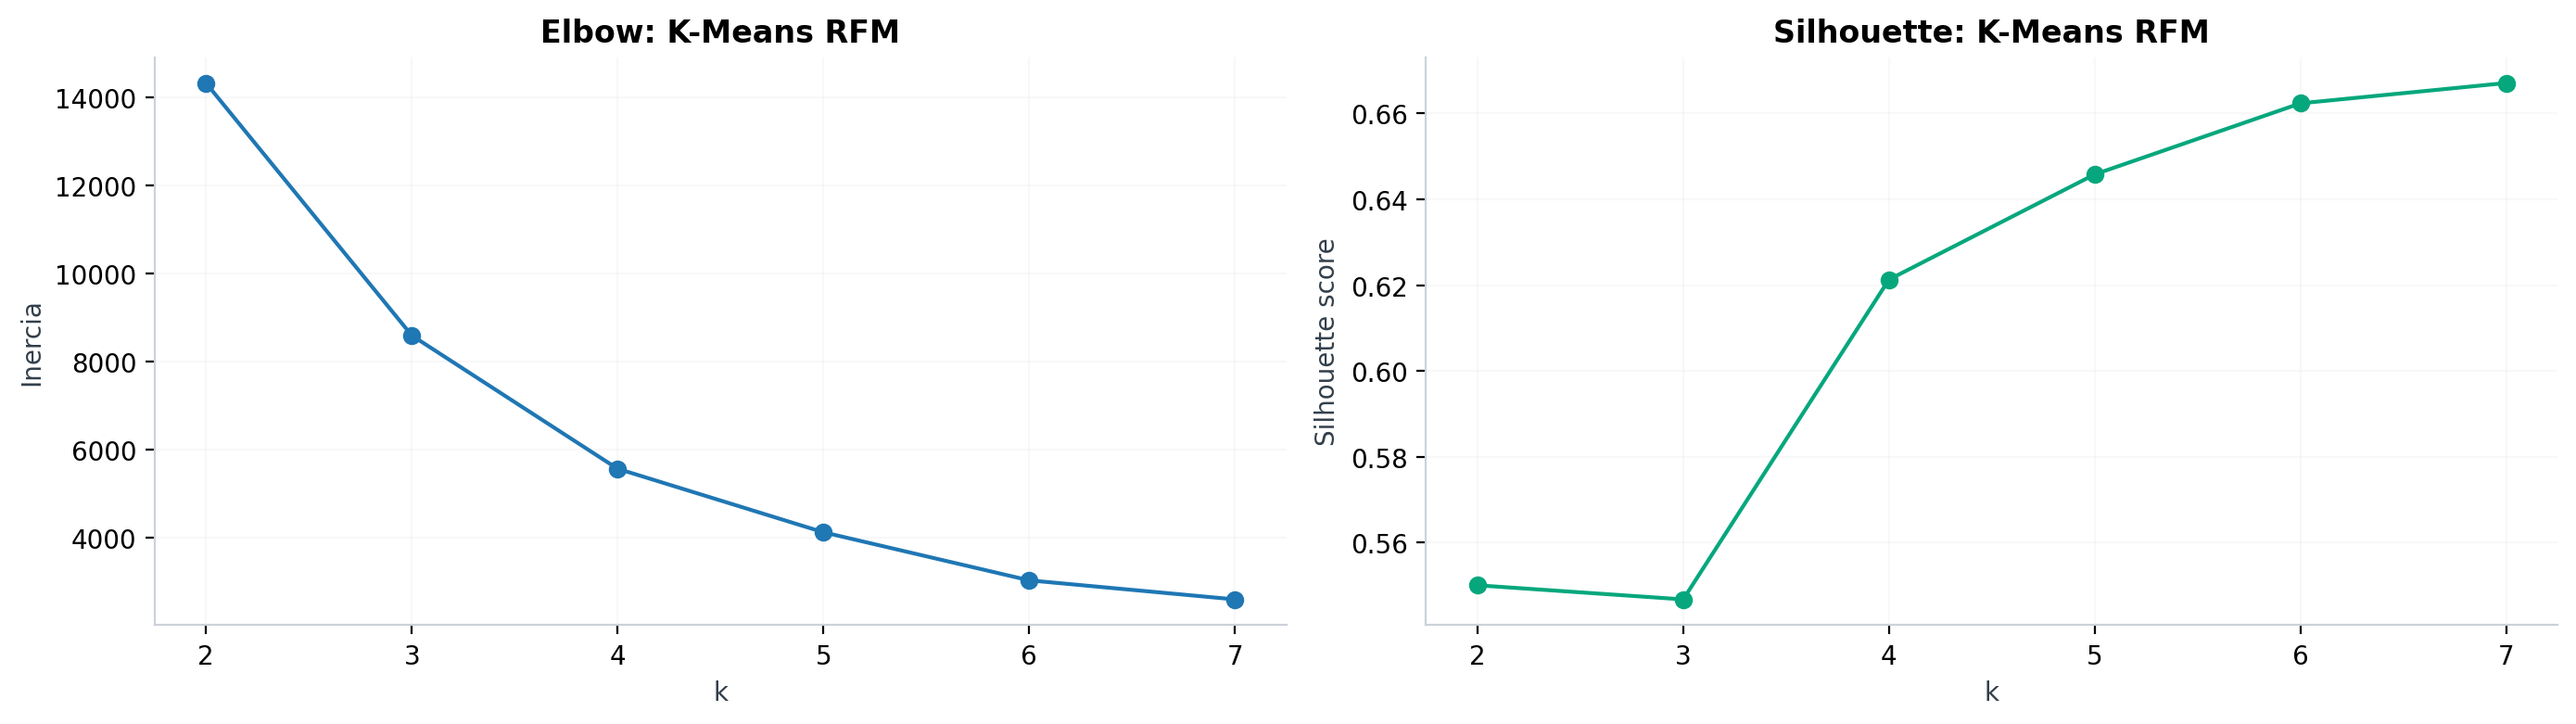

,RFM_Cluster,Segment,customers,recency_mean,frequency_mean,monetary_mean
2,2,Alto Valor,1014,14.687377,1.660750,45.887574
1,1,Médio Valor,3889,18.957316,1.001286,0.173566
0,0,Baixo Valor,2406,6.412718,1.730258,0.000000


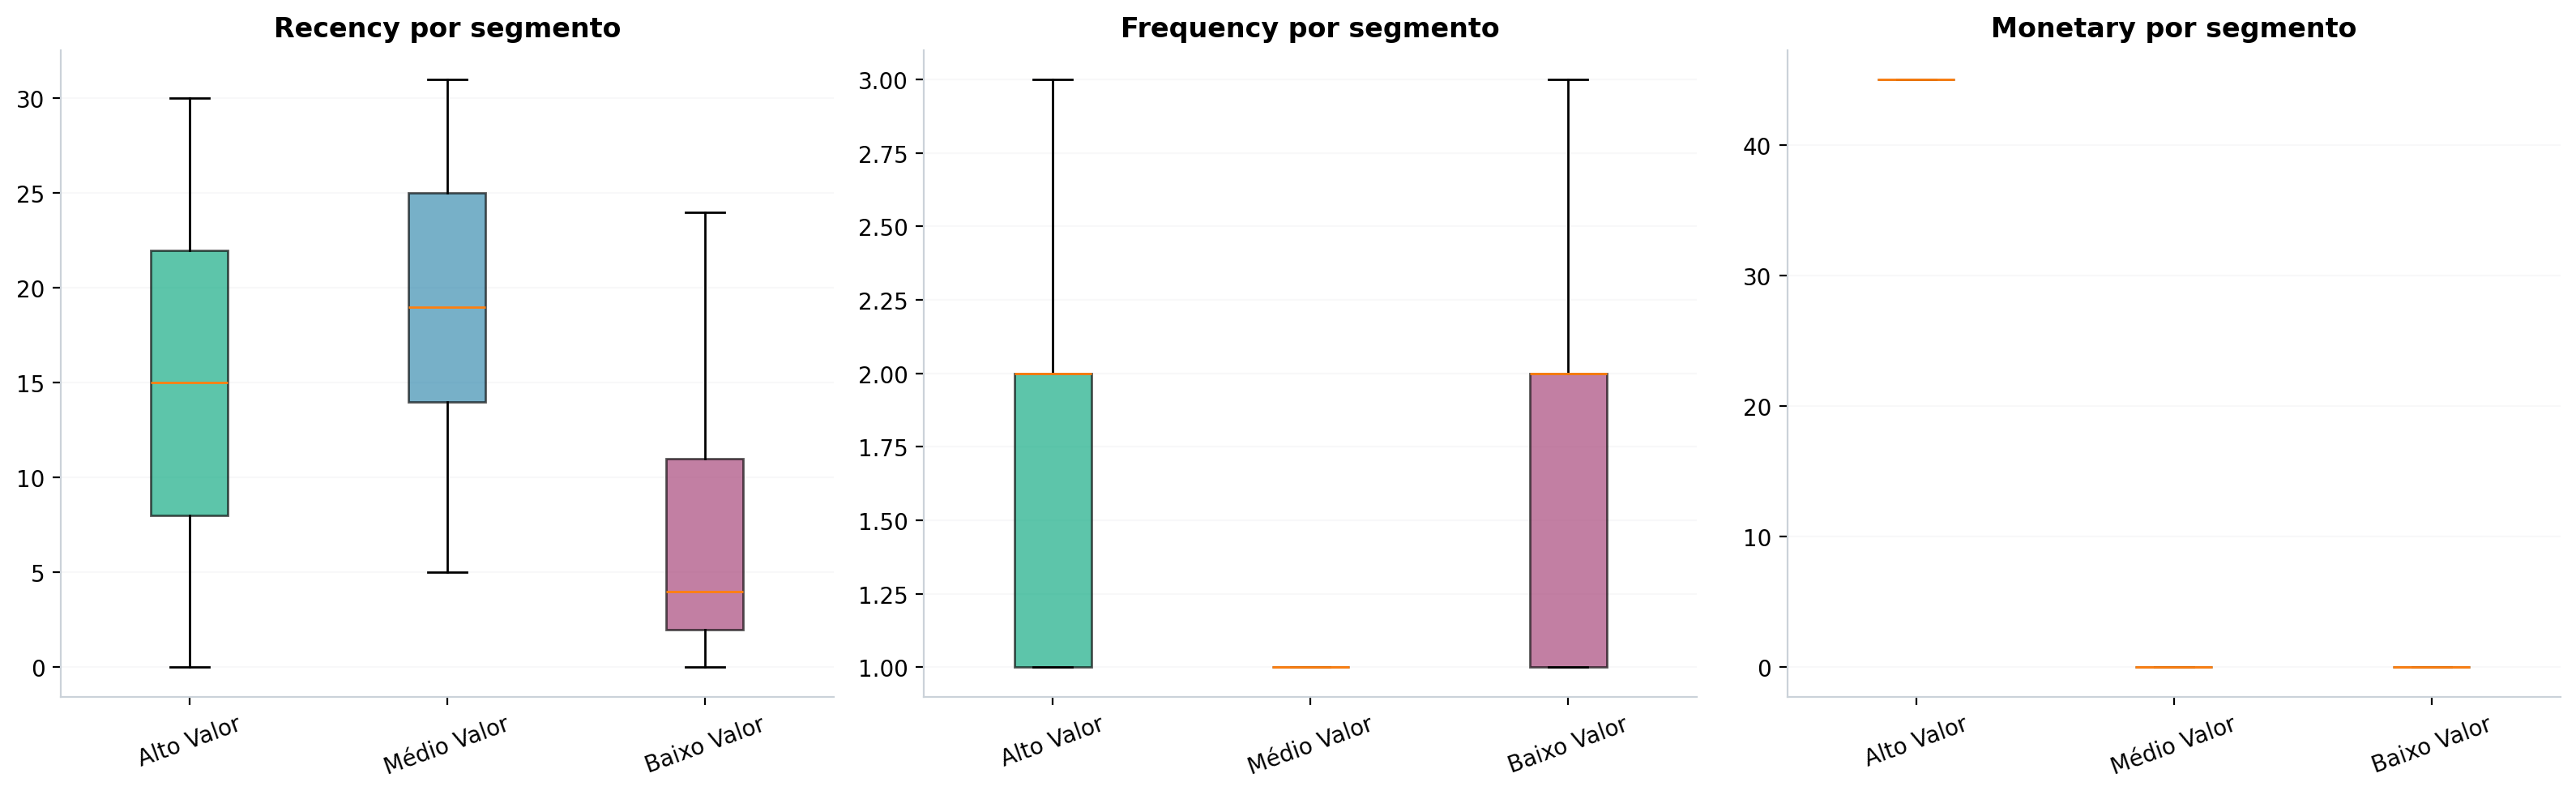

C1: Segmentação RFM por proxy criada e integrada ao df_clean.


In [41]:
# C1: Proxies de RFM a partir de dados de campanha.
# Aviso: estes sao proxies, nao RFM transacional real.

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rfm_proxy = df_clean.copy()
rfm_proxy["date_served"] = pd.to_datetime(
    rfm_proxy["date_served"],
    errors="coerce",
)

reference_date = rfm_proxy["date_served"].max()
recency_df = (
    rfm_proxy.groupby("user_id")["date_served"]
    .max()
    .apply(lambda d: (reference_date - d).days)
    .rename("Recency")
    .reset_index()
)

frequency_df = (
    rfm_proxy.groupby("user_id")["date_served"]
    .count()
    .rename("Frequency")
    .reset_index()
)

monetary_df = (
    rfm_proxy.groupby("user_id")["converted_flag"]
    .sum()
    .mul(REVENUE_PER_CONVERSION)
    .rename("Monetary")
    .reset_index()
)

rfm_df = recency_df.merge(frequency_df, on="user_id").merge(
    monetary_df,
    on="user_id",
)
recency_fill = rfm_df["Recency"].max() + 1
rfm_df["Recency"] = rfm_df["Recency"].fillna(recency_fill)
rfm_df["Frequency"] = rfm_df["Frequency"].fillna(0)
rfm_df["Monetary"] = rfm_df["Monetary"].fillna(0)

rfm_scaled = np.log1p(rfm_df[["Recency", "Frequency", "Monetary"]])
scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm_scaled)

inertias: list[float] = []
silhouettes: list[float] = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_rfm)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_rfm, labels))

rfm_k_diagnostics = pd.DataFrame(
    {
        "k": list(k_range),
        "inertia": inertias,
        "silhouette": silhouettes,
    }
)
display(rfm_k_diagnostics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rfm_k_diagnostics["k"], rfm_k_diagnostics["inertia"], marker="o")
axes[0].set_title("Elbow: K-Means RFM", fontweight="bold")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")
axes[0].grid(alpha=0.25)

axes[1].plot(
    rfm_k_diagnostics["k"],
    rfm_k_diagnostics["silhouette"],
    marker="o",
    color="#06A77D",
)
axes[1].set_title("Silhouette: K-Means RFM", fontweight="bold")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()
plt.close()

km_final = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=10)
rfm_df["RFM_Cluster"] = km_final.fit_predict(X_rfm)

cluster_means = (
    rfm_df.groupby("RFM_Cluster")["Monetary"]
    .mean()
    .sort_values(ascending=False)
)
cluster_labels = ["Alto Valor", "Médio Valor", "Baixo Valor"]
cluster_name_map = {
    cluster_id: cluster_labels[position]
    for position, cluster_id in enumerate(cluster_means.index)
}
rfm_df["Segment"] = rfm_df["RFM_Cluster"].map(cluster_name_map)

df_clean = df_clean.drop(
    columns=["RFM_Cluster", "Segment"],
    errors="ignore",
).merge(
    rfm_df[["user_id", "RFM_Cluster", "Segment"]],
    on="user_id",
    how="left",
)

rfm_cluster_summary = (
    rfm_df.groupby(["RFM_Cluster", "Segment"])
    .agg(
        customers=("user_id", "nunique"),
        recency_mean=("Recency", "mean"),
        frequency_mean=("Frequency", "mean"),
        monetary_mean=("Monetary", "mean"),
    )
    .reset_index()
    .sort_values("monetary_mean", ascending=False)
)
display(rfm_cluster_summary)

segment_order = ["Alto Valor", "Médio Valor", "Baixo Valor"]
box_colors = ["#06A77D", "#2E86AB", "#A23B72"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ["Recency", "Frequency", "Monetary"]):
    box_data = [
        rfm_df.loc[rfm_df["Segment"] == segment, metric]
        for segment in segment_order
    ]
    boxplot = ax.boxplot(
        box_data,
        tick_labels=segment_order,
        patch_artist=True,
        showfliers=False,
    )
    for patch, color in zip(boxplot["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_title(f"{metric} por segmento", fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
plt.close()

print("C1: Segmentação RFM por proxy criada e integrada ao df_clean.")


<span style="color:steelblue; text-align: left">

## Customer Lifetime Value por Segmento
</span>

Com os segmentos RFM definidos, a próxima pergunta e quanto cada grupo vale economicamente.
Aqui o LTV histórico e calculado por cliente como receita estimada menos custo de impacto.
O valor médio por segmento substitui o uso de um customer value único nas simulações.


,segment,ltv_mean,ltv_median,ltv_std,n_customers
0,Alto Valor,44.101578,43.5,5.950442,1014
2,Médio Valor,-0.930573,-1.2,2.787057,3889
1,Baixo Valor,-1.856608,-2.0,0.636914,2406


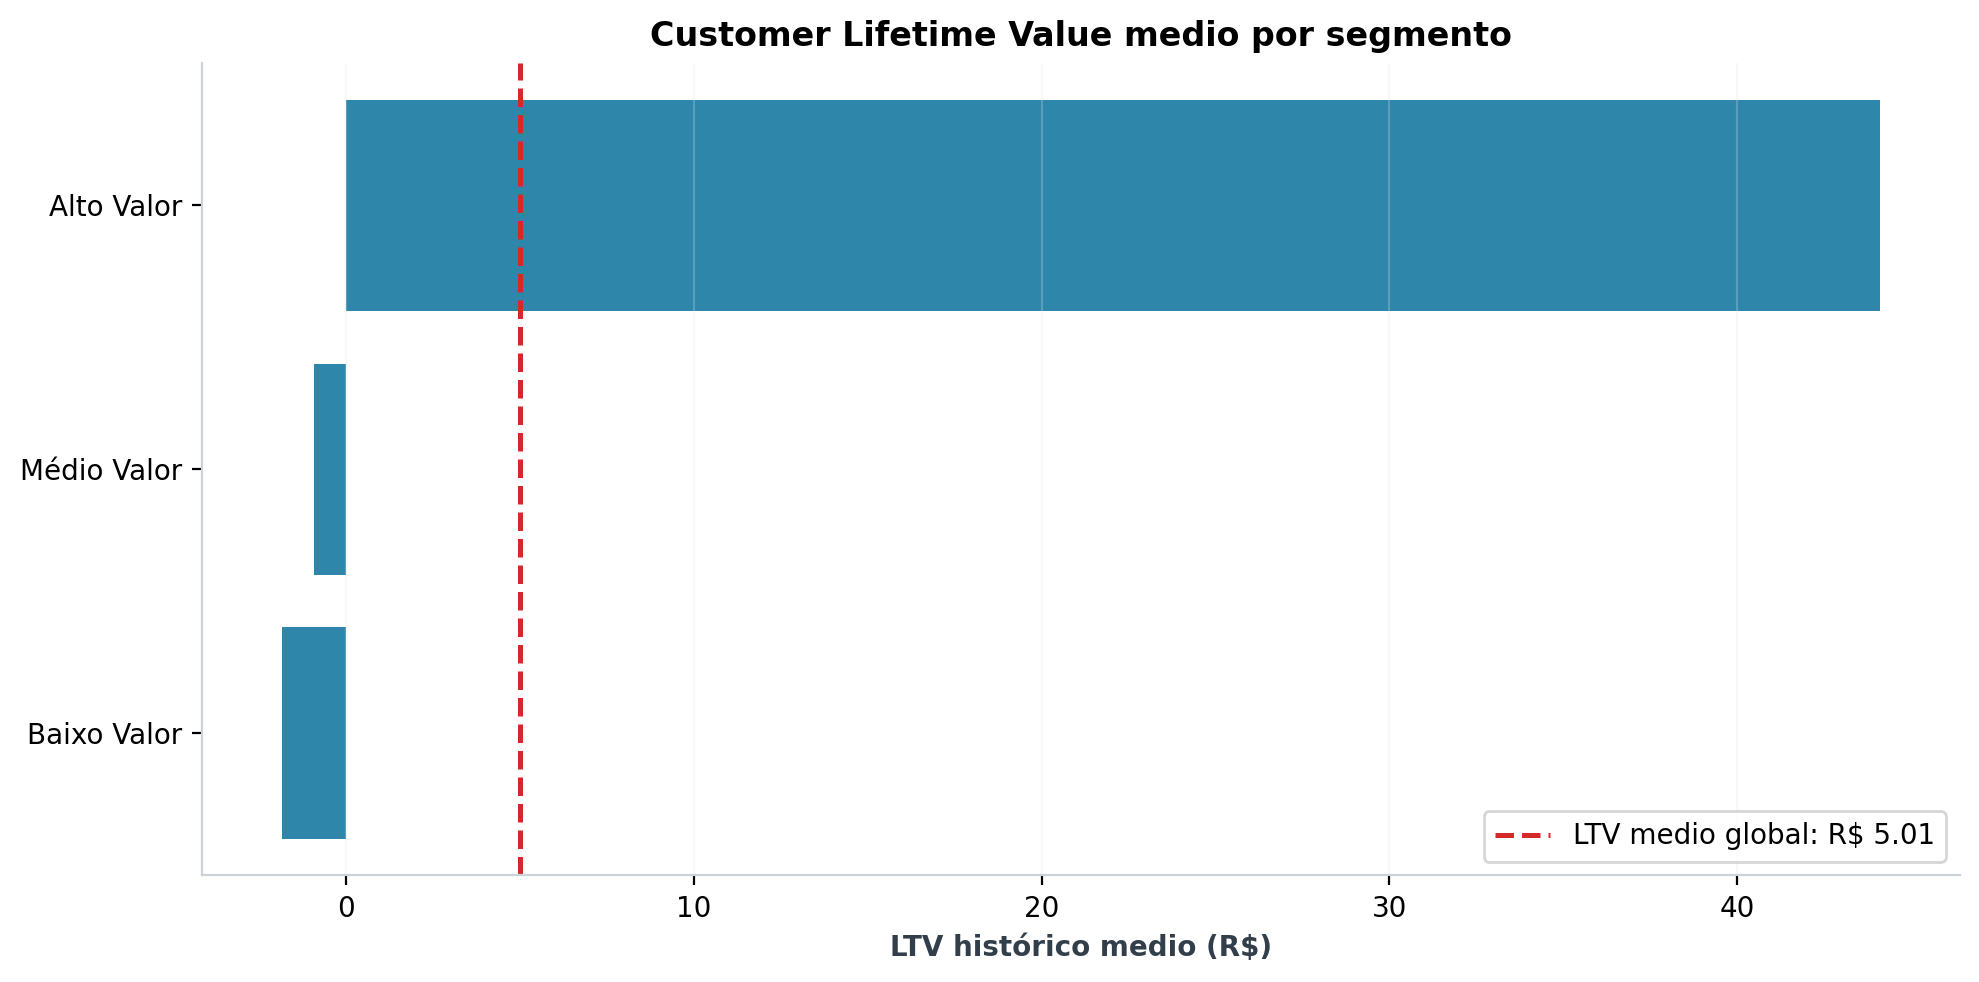

C2: LTV por segmento calculado e disponível em segment_ltv_map.


In [42]:
# C2: LTV histórico calculado por cliente e projetado por segmento.
# LTV histórico = receita gerada - custo de impacto estimado.
ltv_df = df_clean.copy()
ltv_df["revenue"] = ltv_df["converted_flag"] * REVENUE_PER_CONVERSION
ltv_df["cost"] = ltv_df["marketing_channel"].map(
    COST_PER_IMPRESSION,
).fillna(DEFAULT_COST)

ltv_by_customer = (
    ltv_df.groupby("user_id")
    .agg(
        total_revenue=("revenue", "sum"),
        total_cost=("cost", "sum"),
        segment=("Segment", "first"),
    )
    .assign(historical_ltv=lambda d: d["total_revenue"] - d["total_cost"])
    .reset_index()
)

ltv_by_segment = (
    ltv_by_customer.groupby("segment")["historical_ltv"]
    .agg(
        ltv_mean="mean",
        ltv_median="median",
        ltv_std="std",
        n_customers="count",
    )
    .reset_index()
    .sort_values("ltv_mean", ascending=False)
)
ltv_by_segment["ltv_std"] = ltv_by_segment["ltv_std"].fillna(0)
global_ltv = float(ltv_by_customer["historical_ltv"].mean())
segment_ltv_map: dict[str, float] = (
    ltv_by_segment.set_index("segment")["ltv_mean"].to_dict()
)

display(ltv_by_segment)

fig, ax = plt.subplots(figsize=(10, 5))
plot_ltv = ltv_by_segment.sort_values("ltv_mean", ascending=True)
ax.barh(plot_ltv["segment"], plot_ltv["ltv_mean"], color="#2E86AB")
ax.axvline(
    global_ltv,
    color="#D62828",
    linestyle="--",
    linewidth=1.8,
    label=f"LTV medio global: R$ {global_ltv:,.2f}",
)
ax.set_xlabel("LTV histórico medio (R$)", fontweight="bold")
ax.set_title("Customer Lifetime Value medio por segmento", fontweight="bold")
ax.grid(axis="x", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

print("C2: LTV por segmento calculado e disponível em segment_ltv_map.")


<span style="color:steelblue; text-align: left">

## Exploração descritiva
</span>

Depois da limpeza, validamos a composição da base antes de inferir ou modelar.

Nesta etapa é realizada uma análise exploratória inicial para compreender o comportamento geral da campanha de marketing e a distribuição das principais variáveis do estudo.

O objetivo desta análise é identificar padrões preliminares relacionados a:
- volume de conversões;
- retenção de usuários;
- distribuição entre grupos do teste A/B;
- intensidade de utilização dos canais de marketing.

Os gráficos apresentados permitem avaliar possíveis desbalanceamentos da base, identificar concentração de usuários em determinados canais e observar diferenças iniciais entre as variantes da campanha.

Essa exploração fornece contexto para as etapas posteriores de inferência estatística, modelagem preditiva e otimização de campanhas.



EXPLORAÇÃO DESCRITIVA


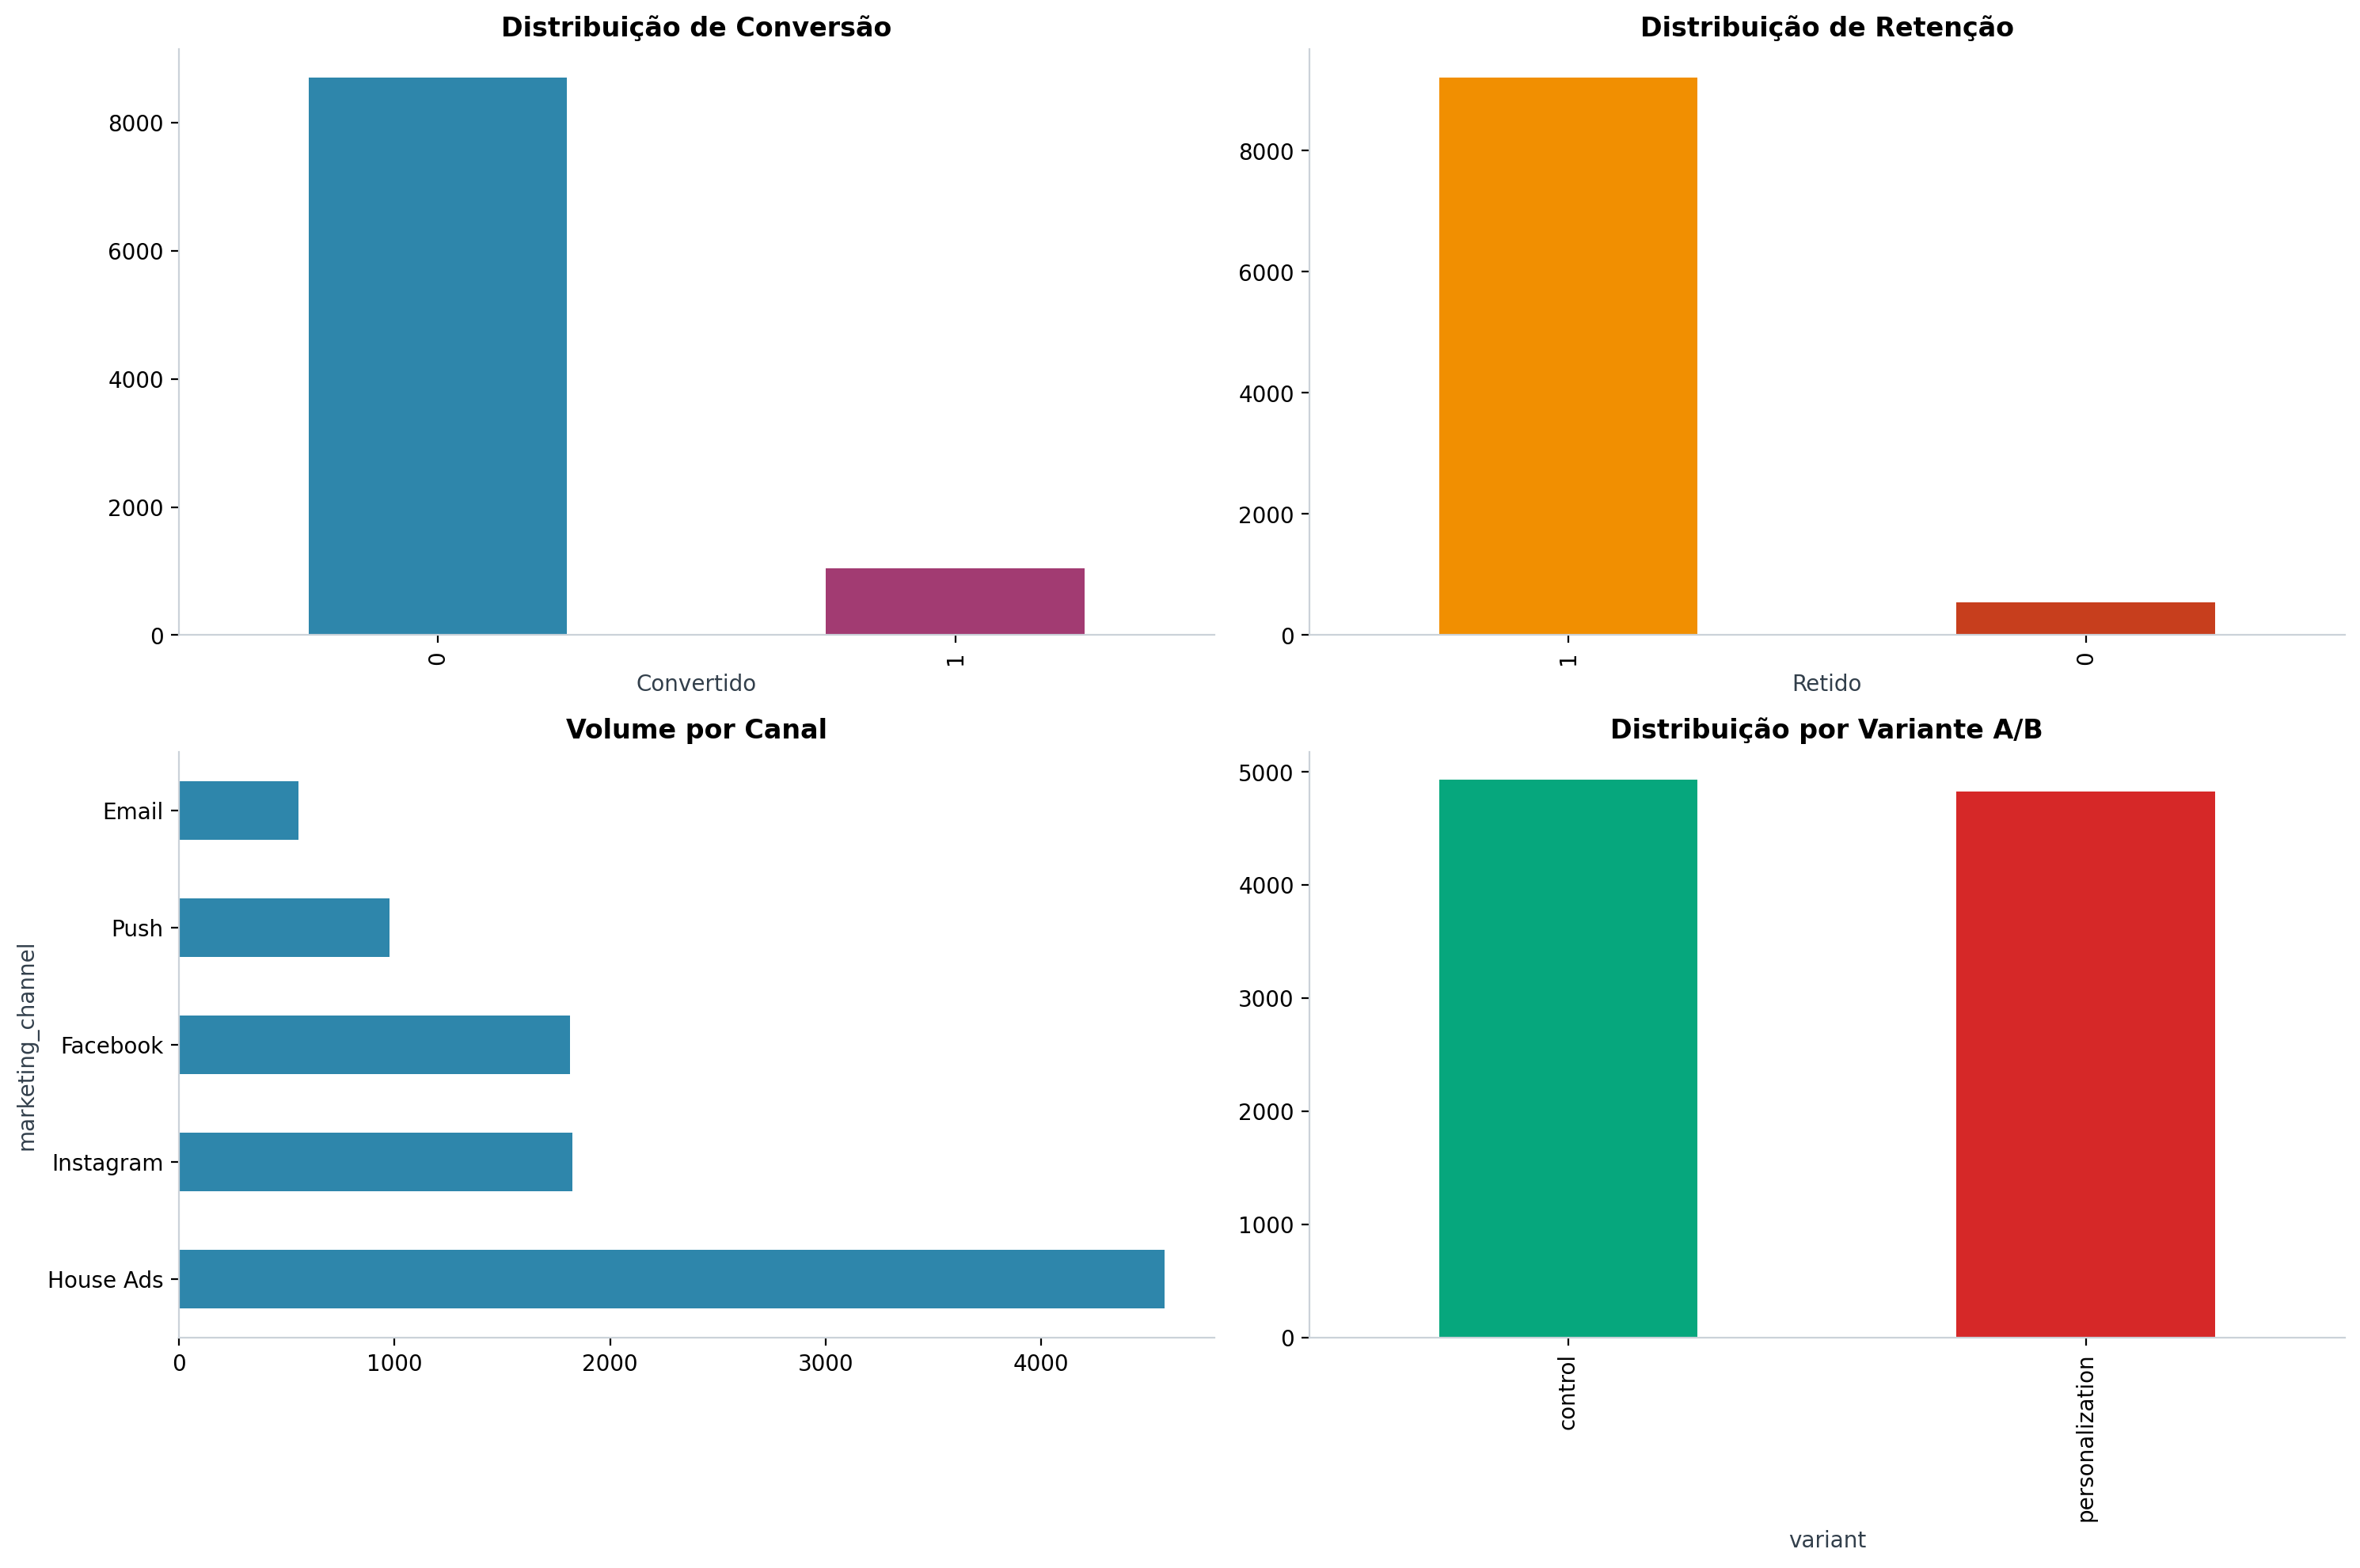

✓ Gráficos de exploração criados


In [43]:
def explore_distributions(df: pd.DataFrame) -> None:
    """Explorar distribuições univariadas e correlações."""
    print("\n" + "=" * 80)
    print("EXPLORAÇÃO DESCRITIVA")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    if "converted_flag" in df.columns:
        df["converted_flag"].value_counts().plot(
            kind="bar", ax=axes[0, 0], color=["#2E86AB", "#A23B72"]
        )
        axes[0, 0].set_title("Distribuição de Conversão", fontweight="bold")
        axes[0, 0].set_xlabel("Convertido")
    
    if "retained_flag" in df.columns:
        df["retained_flag"].value_counts().plot(
            kind="bar", ax=axes[0, 1], color=["#F18F01", "#C73E1D"]
        )
        axes[0, 1].set_title("Distribuição de Retenção", fontweight="bold")
        axes[0, 1].set_xlabel("Retido")
    
    if "marketing_channel" in df.columns:
        df["marketing_channel"].value_counts().plot(
            kind="barh", ax=axes[1, 0], color="#2E86AB"
        )
        axes[1, 0].set_title("Volume por Canal", fontweight="bold")
    
    if "variant" in df.columns:
        df["variant"].value_counts().plot(
            kind="bar", ax=axes[1, 1], color=["#06A77D", "#D62828"]
        )
        axes[1, 1].set_title("Distribuição por Variante A/B", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    plt.close()
    print("✓ Gráficos de exploração criados")

explore_distributions(df_clean)


### Insights

>A análise descritiva evidencia um cenário típico de campanhas digitais com distribuição desbalanceada entre convertidos e não convertidos. A retenção ocorre em proporção significativamente maior que a conversão, e o gargalo principal não é retenção, mas conversão inicial.

<span style="color:steelblue; text-align: left">

## Análise de funil

</span>

Nesta seção é analisado o desempenho da campanha ao longo das principais etapas do funil de marketing: impacto inicial, conversão e retenção.

O conceito de funil representa a redução progressiva de usuários ao longo da jornada do cliente. Nem todos os usuários impactados convertem, e nem todos os convertidos permanecem ativos após a conversão inicial.

A análise permite responder perguntas estratégicas como:
- quantos usuários foram efetivamente impactados pela campanha;
- qual percentual realizou conversão;
- quantos usuários permaneceram retidos após a conversão;
- em qual etapa ocorre a maior perda de usuários.

O dataset tem 7.309 usuários impactados. 

**A pergunta imediata é:** 
- `Em quantas etapas perdemos esses usuários antes da retenção?` 

O funil responde onde concentrar esforço de otimização.


ANÁLISE DE FUNIL


,Métrica,Valor
0,Usuários Impactados,7309.00
1,Conversões,1049.00
2,Retidos (entre convertidos),700.00
3,Taxa de Conversão (%),10.75
4,Taxa de Retenção (%),66.73


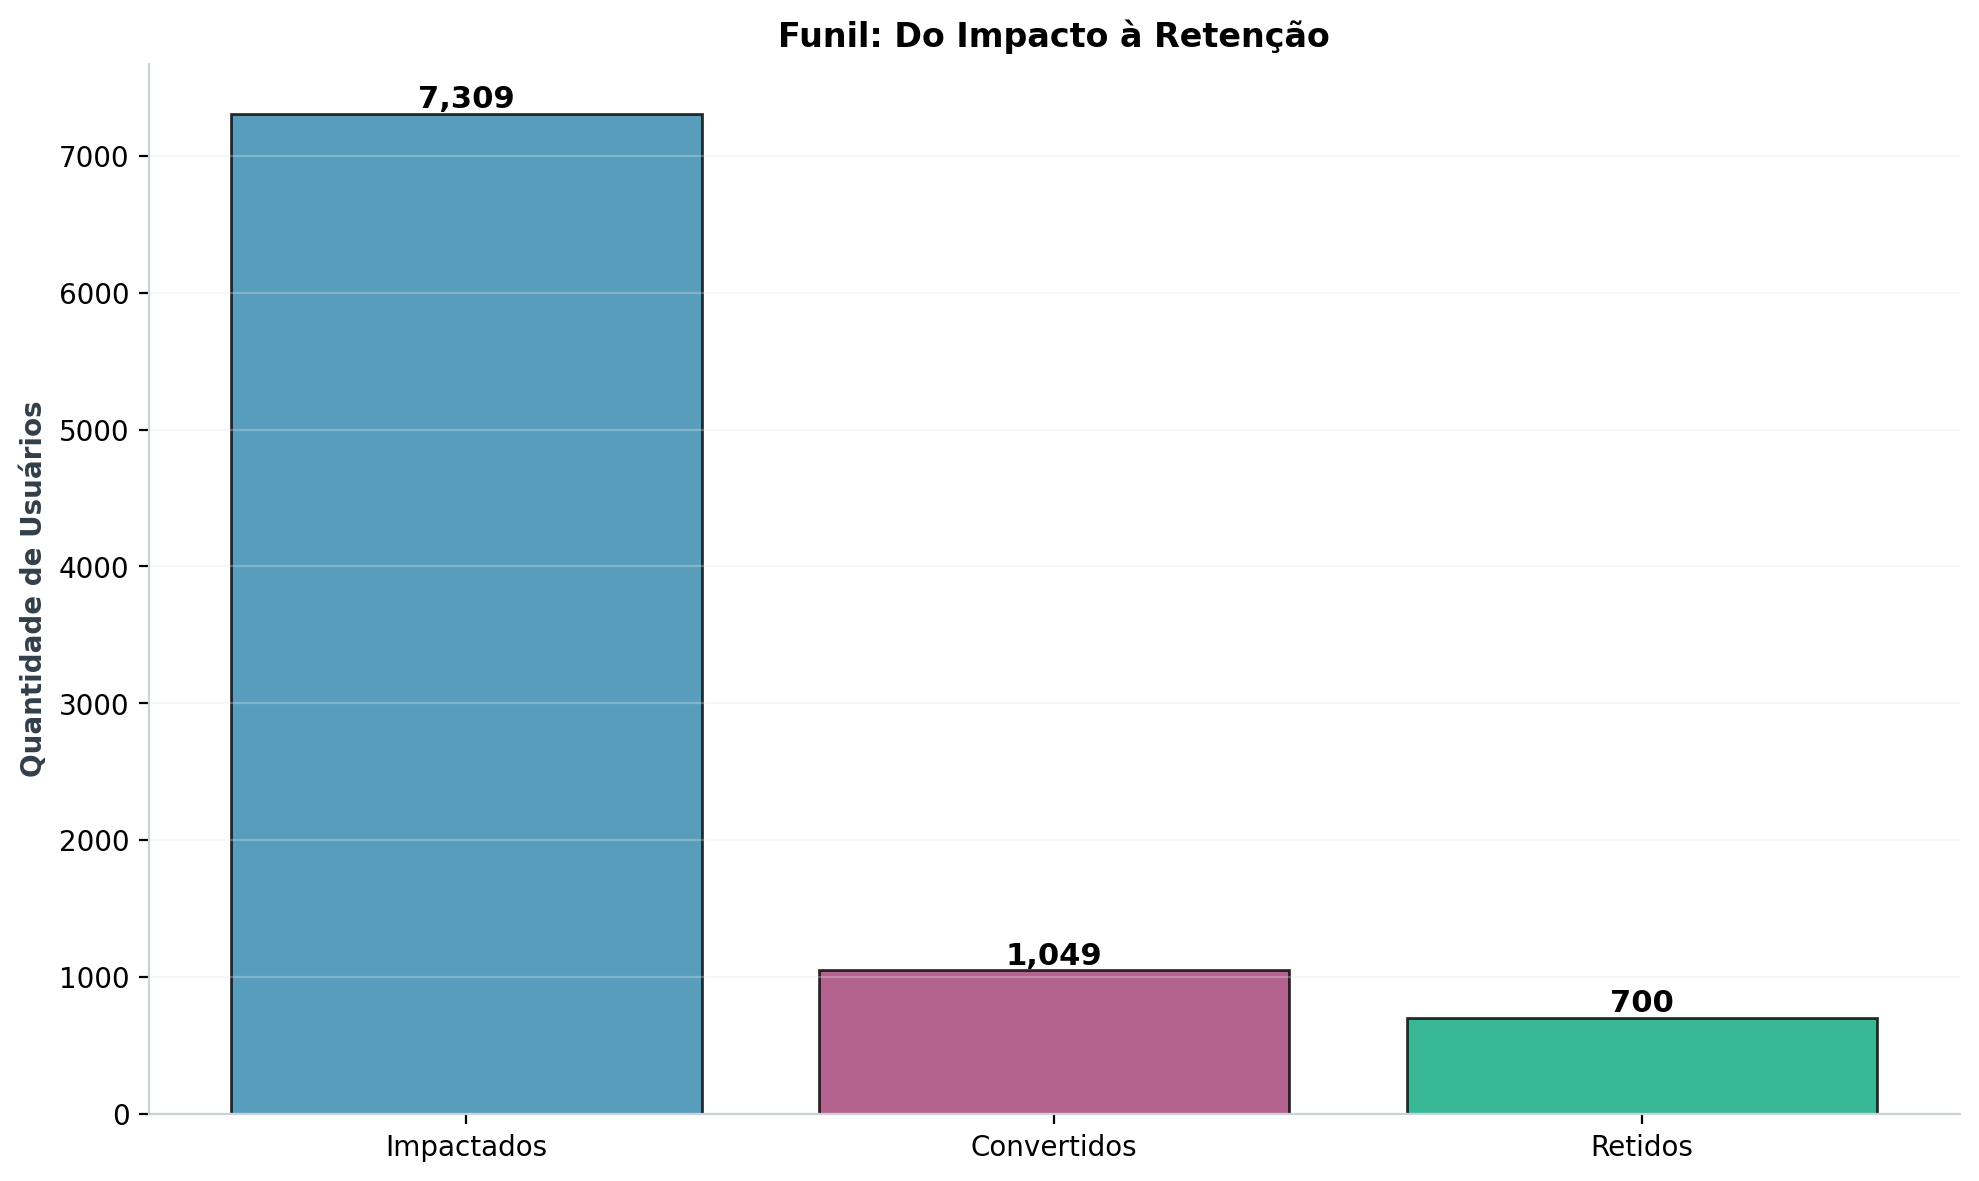

✓ Funil construído


In [44]:
def build_funnel(df: pd.DataFrame) -> pd.DataFrame:
    """Construir análise de funil."""
    print("\n" + "=" * 80)
    print("ANÁLISE DE FUNIL")
    print("=" * 80)
    
    funnel_metrics = {
        "Métrica": [
            "Usuários Impactados",
            "Conversões",
            "Retidos (entre convertidos)",
            "Taxa de Conversão (%)",
            "Taxa de Retenção (%)"
        ],
        "Valor": [
            df["user_id"].nunique(),
            int(df["converted_flag"].sum()),
            int(df[df["converted_flag"] == 1]["retained_flag"].sum()),
            round((df["converted_flag"].sum() / len(df)) * 100, 2),
            round(
                (df[df["converted_flag"] == 1]["retained_flag"].sum() /
                 max(df["converted_flag"].sum(), 1)) * 100, 2
            )
        ]
    }
    
    funnel_df = pd.DataFrame(funnel_metrics)
    display(funnel_df)
    
    # Visualização
    fig, ax = plt.subplots(figsize=(10, 6))
    stages = ["Impactados", "Convertidos", "Retidos"]
    counts = [
        df["user_id"].nunique(),
        int(df["converted_flag"].sum()),
        int(df[df["converted_flag"] == 1]["retained_flag"].sum())
    ]
    colors = ["#2E86AB", "#A23B72", "#06A77D"]
    
    bars = ax.bar(stages, counts, color=colors, alpha=0.8, edgecolor="black")
    
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height,
                f"{int(count):,}", ha="center", va="bottom",
                fontweight="bold", fontsize=11)
    
    ax.set_ylabel("Quantidade de Usuários", fontweight="bold")
    ax.set_title("Funil: Do Impacto à Retenção", fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("✓ Funil construído")

    return funnel_df

funnel_summary = build_funnel(df_clean)


In [45]:
from IPython.display import Markdown

taxa_conv = float(
    funnel_summary.loc[
        funnel_summary["Métrica"] == "Taxa de Conversão (%)",
        "Valor",
    ].iloc[0]
)
taxa_ret = float(
    funnel_summary.loc[
        funnel_summary["Métrica"] == "Taxa de Retenção (%)",
        "Valor",
    ].iloc[0]
)
impacto_1pp = df_clean["user_id"].nunique() * 0.01 * REVENUE_PER_CONVERSION

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insights do Funil
</span>

**O que os dados mostram:** {taxa_conv:.1f}% dos usuários impactados convertem e {taxa_ret:.1f}% dos convertidos permanecem. A maior perda ocorre na conversão, não na retenção.\n
**Por que importa:** O gargalo principal é aquisição qualificada, não retenção pós-conversão. Concentrar esforços aqui tem maior alavancagem.\n
**Ação recomendada:** Priorizar budget de otimização em canais e variantes que aumentam conversão inicial.\n
**Impacto estimado:** Cada +1 p.p. na conversão gera aproximadamente R$ {impacto_1pp:,.0f} em receita adicional sobre a base atual.
"""))


<span style="color:steelblue; text-align: left">

### Insights do Funil
</span>

**O que os dados mostram:** 10.8% dos usuários impactados convertem e 66.7% dos convertidos permanecem. A maior perda ocorre na conversão, não na retenção.

**Por que importa:** O gargalo principal é aquisição qualificada, não retenção pós-conversão. Concentrar esforços aqui tem maior alavancagem.

**Ação recomendada:** Priorizar budget de otimização em canais e variantes que aumentam conversão inicial.

**Impacto estimado:** Cada +1 p.p. na conversão gera aproximadamente R$ 3,289 em receita adicional sobre a base atual.


<span style="color:steelblue; text-align: left">

## Performance por canal

</span>

O funil mostrou que a maior perda ocorre na conversão.

Agora, nesta seção de performance por canal, são avaliadas as métricas de desempenho dos canais de marketing utilizados na campanha. 
O objetivo é identificar quais canais apresentam maior capacidade de gerar conversão, retenção e potencial retorno financeiro, considerando :

- volume de usuários impactados;
- quantidade de conversões;
- retenção de usuários;
- cancelamentos;
- taxa de conversão;
- taxa de retenção.

Essa abordagem permite comparar eficiência operacional entre canais e identificar quais estratégias de aquisição apresentam maior qualidade de usuários ao longo da jornada.

Além do volume bruto de conversões, esta etapa busca responder uma questão central de marketing analytics: 
- `Quais canais atraem usuários com maior probabilidade de permanecer ativos após a conversão inicial ?`

Agora: qual canal desperdiça mais budget nessa perda e qual entrega usuários com maior probabilidade de permanecer?


ANÁLISE POR CANAL


,marketing_channel,impactados,conversoes,retidos,cancelamentos,conversion_rate_%,retention_rate_%
0,Email,552,187,143,53,33.88,76.47
3,Instagram,1726,243,159,116,14.08,65.43
1,Facebook,1744,227,156,100,13.02,68.72
4,Push,963,79,54,38,8.20,68.35
2,House Ads,3911,298,173,240,7.62,58.05


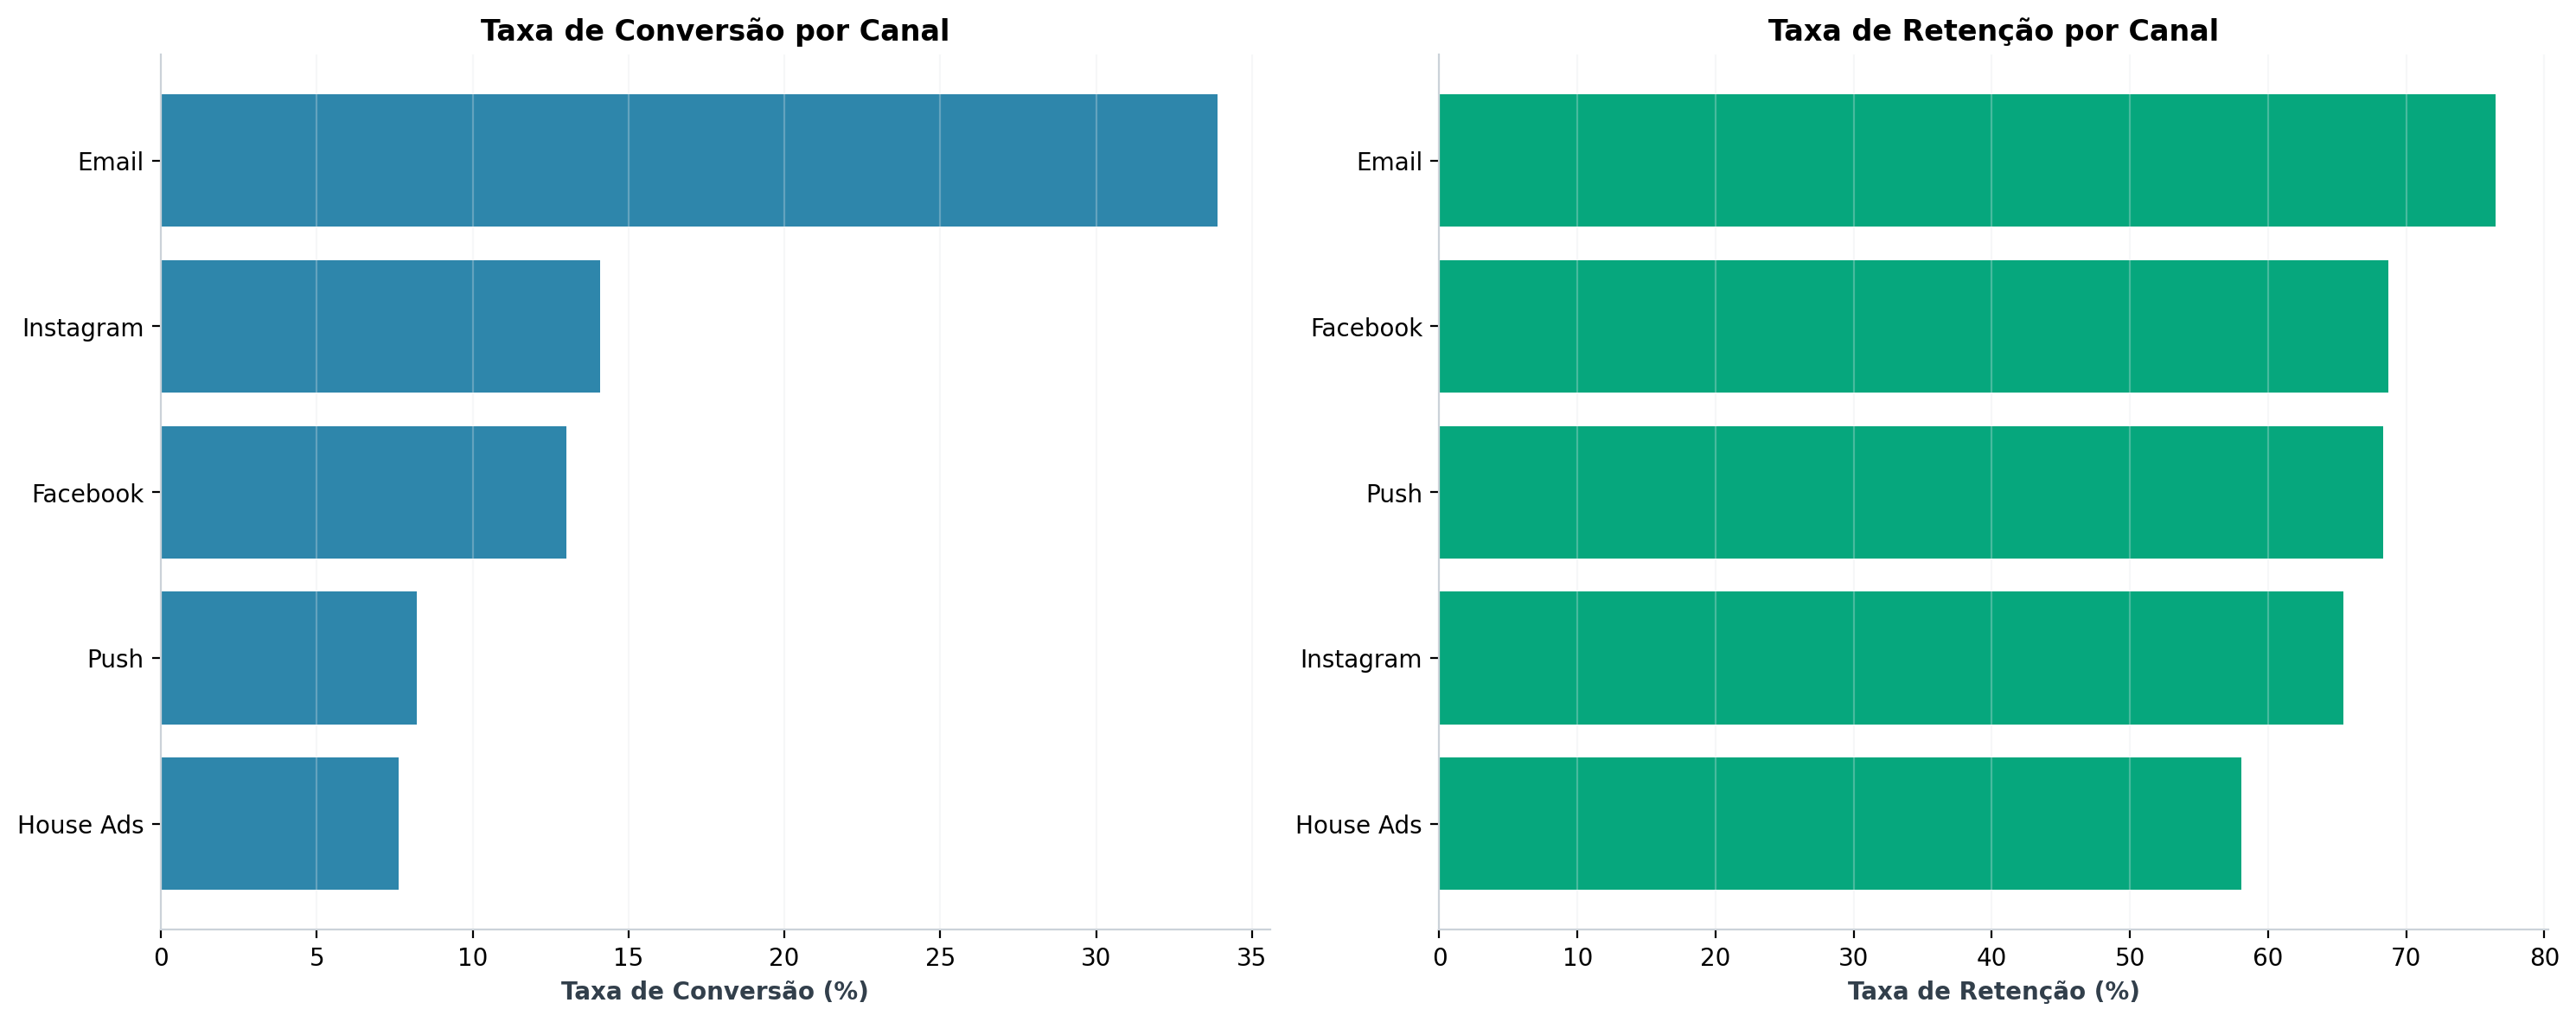

✓ Análise por canal concluída


In [46]:
def analyze_channel_performance(df: pd.DataFrame) -> pd.DataFrame:
    """Analisar performance por canal de marketing."""
    print("\n" + "=" * 80)
    print("ANÁLISE POR CANAL")
    print("=" * 80)
    
    # Retenção valida: usuário convertido e depois retido.
    df_channel = df.copy()
    df_channel["retained_after_conversion"] = (
        (df_channel["converted_flag"] == 1)
        & (df_channel["retained_flag"] == 1)
    ).astype(int)

    agg_dict = {
        "impactados": ("user_id", "nunique"),
        "conversoes": ("converted_flag", "sum"),
        "retidos": ("retained_after_conversion", "sum"),
    }
    
    if "date_canceled" in df_channel.columns:
        agg_dict["cancelamentos"] = ("date_canceled", lambda x: x.notna().sum())
    
    channel_summary = df_channel.groupby("marketing_channel").agg(**agg_dict).reset_index()
    
    if "cancelamentos" not in channel_summary.columns:
        channel_summary["cancelamentos"] = 0
    
    channel_summary["conversion_rate_%"] = round(
        (channel_summary["conversoes"] / channel_summary["impactados"]) * 100, 2
    )
    retention_rate = (
        channel_summary["retidos"]
        / channel_summary["conversoes"].replace(0, pd.NA)
    ) * 100
    channel_summary["retention_rate_%"] = (
        retention_rate.fillna(0).clip(lower=0, upper=100).round(2)
    )
    
    channel_summary = channel_summary.sort_values("conversion_rate_%", ascending=False)
    
    display(channel_summary)
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    sorted_data = channel_summary.sort_values("conversion_rate_%", ascending=True)
    axes[0].barh(sorted_data["marketing_channel"], sorted_data["conversion_rate_%"], color="#2E86AB")
    axes[0].set_xlabel("Taxa de Conversão (%)", fontweight="bold")
    axes[0].set_title("Taxa de Conversão por Canal", fontweight="bold")
    axes[0].grid(axis="x", alpha=0.3)
    
    sorted_data = channel_summary.sort_values("retention_rate_%", ascending=True)
    axes[1].barh(sorted_data["marketing_channel"], sorted_data["retention_rate_%"], color="#06A77D")
    axes[1].set_xlabel("Taxa de Retenção (%)", fontweight="bold")
    axes[1].set_title("Taxa de Retenção por Canal", fontweight="bold")
    axes[1].grid(axis="x", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    plt.close()
    
    print("✓ Análise por canal concluída")
    return channel_summary

channel_summary = analyze_channel_performance(df_clean)


In [47]:
from IPython.display import Markdown

# CORRECAO 1: Comparacao real de todos os canais em ambas as dimensões.
# Não assumir qual canal domina qual dimensao - deixar os dados decidirem.
channel_metrics = channel_summary.set_index("marketing_channel")

# Email
email_conv = float(channel_metrics.loc["Email", "conversion_rate_%"]) if "Email" in channel_metrics.index else 0.0
email_ret = float(channel_metrics.loc["Email", "retention_rate_%"]) if "Email" in channel_metrics.index else 0.0

# House Ads
house_conv = float(channel_metrics.loc["House Ads", "conversion_rate_%"]) if "House Ads" in channel_metrics.index else 0.0
house_ret = float(channel_metrics.loc["House Ads", "retention_rate_%"]) if "House Ads" in channel_metrics.index else 0.0

if not channel_summary.empty:
    best_conv_channel = channel_summary.loc[
        channel_summary["conversion_rate_%"].idxmax(), "marketing_channel"
    ]
    best_ret_channel = channel_summary.loc[
        channel_summary["retention_rate_%"].idxmax(), "marketing_channel"
    ]
    best_conv_rate = float(channel_summary["conversion_rate_%"].max())
    best_ret_rate = float(channel_summary["retention_rate_%"].max())
else:
    best_conv_channel = "N/D"
    best_ret_channel = "N/D"
    best_conv_rate = 0.0
    best_ret_rate = 0.0

email_dominates = (email_conv >= house_conv) and (email_ret >= house_ret)
house_dominates = (house_conv >= email_conv) and (house_ret >= email_ret)
tradeoff_exists = not email_dominates and not house_dominates

if email_dominates:
    action_text = (
        f"Email lidera em ambas as dimensões (conversão: {email_conv:.1f}% "
        f"vs {house_conv:.1f}%; retenção: {email_ret:.1f}% vs {house_ret:.1f}%). "
        "Ação: escalar budget de Email. House Ads não justifica realocação "
        "de budget enquanto Email dominar ambas as métricas."
    )
    realloc_direction = "de House Ads para Email"
elif tradeoff_exists:
    action_text = (
        f"Há tradeoff real: {best_conv_channel} lidera conversão ({best_conv_rate:.1f}%) "
        f"e {best_ret_channel} lidera retenção ({best_ret_rate:.1f}%). "
        f"Ação: usar {best_conv_channel} para aquisição e "
        f"{best_ret_channel} para retenção de convertidos."
    )
    realloc_direction = (
        f"de {best_conv_channel} para {best_ret_channel} em campanhas de retenção"
    )
else:
    action_text = "House Ads lidera em ambas as dimensões. Revisar dados - resultado incomum."
    realloc_direction = "verificar dados antes de recomendar"

_global_ltv_ref = float(
    globals().get("global_ltv", globals().get("ESTIMATED_CUSTOMER_VALUE", 0.0))
)
ltv_impact = _global_ltv_ref * 0.05

# Ação 2 do sumário: baseada nos dados reais, não em hipótese fixa.
if email_dominates:
    acao2_texto = (
        f"**Concentrar budget em Email** - canal dominante em conversão ({email_conv:.1f}%) "
        f"e retenção ({email_ret:.1f}%). Reduzir alocação em canais com ambas as "
        "métricas abaixo da média. Não redirecionar para House Ads enquanto Email "
        "dominar ambas as dimensões."
    )
elif tradeoff_exists:
    acao2_texto = (
        f"**Separar canais por objetivo:** {best_conv_channel} para aquisição, "
        f"{best_ret_channel} para retenção. Alocar percentual do budget "
        "proporcional ao valor esperado de cada etapa do funil."
    )
else:
    acao2_texto = "Revisar dados de performance de canal antes de recomendar realocação."

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insights por Canal
</span>

**O que mostram:** {action_text}

**Por que importa:** Canal com maior conversão e maior retenção simultaneamente
deve receber prioridade de budget - não há benefício em diversificar para canais
com performance inferior em ambas as dimensões.

**Ação recomendada:** Concentrar próxima campanha no canal dominante.
Revisar alocação atual: há budget em canais com conversion_rate abaixo de
{channel_summary["conversion_rate_%"].mean():.1f}% (média geral)?

**Impacto estimado:** Realocação de budget {realloc_direction}
pode aumentar lucro incremental em ~R$ {ltv_impact:,.0f} por usuário
adicional retido (estimativa conservadora de 5% de ganho no LTV médio).
"""))


<span style="color:steelblue; text-align: left">

### Insights por Canal
</span>

**O que mostram:** Email lidera em ambas as dimensões (conversão: 33.9% vs 7.6%; retenção: 76.5% vs 58.0%). Ação: escalar budget de Email. House Ads não justifica realocação de budget enquanto Email dominar ambas as métricas.

**Por que importa:** Canal com maior conversão e maior retenção simultaneamente
deve receber prioridade de budget - não há benefício em diversificar para canais
com performance inferior em ambas as dimensões.

**Ação recomendada:** Concentrar próxima campanha no canal dominante.
Revisar alocação atual: há budget em canais com conversion_rate abaixo de
15.4% (média geral)?

**Impacto estimado:** Realocação de budget de House Ads para Email
pode aumentar lucro incremental em ~R$ 0 por usuário
adicional retido (estimativa conservadora de 5% de ganho no LTV médio).


<span style="color:steelblue; text-align: left">

## Impacto de personalização por idioma
</span>

Antes do A/B test formal, uma hipótese operacional simples: 
- `Usuários impactados no idioma errado convertem menos?` 

A personalização de idioma é uma dimensão importante em campanhas digitais, pois reduz atrito de comunicação e tende a tornar a mensagem mais compreensível, relevante e próxima do público-alvo. Em termos de marketing analytics, essa análise ajuda a verificar se a adequação da comunicação ao perfil do usuário melhora o desempenho da campanha.

A avaliação compara dois grupos:

- usuários que receberam a campanha no idioma correto;
- usuários que receberam a campanha em idioma diferente do preferido.

As métricas analisadas são:
- taxa de conversão;
- taxa de retenção entre convertidos.

Se sim, corrigir idioma já seria uma ação de alta alavancagem sem custo adicional de campanha.


ANÁLISE DE PERSONALIZAÇÃO: IDIOMA CORRETO


,label,user_id,converted_flag,retained_among_converted,conversion_rate_%,retention_rate_%
0,Idioma Incorreto,403,27,14,6.70,51.85
1,Idioma Correto,6989,1022,686,14.62,67.12


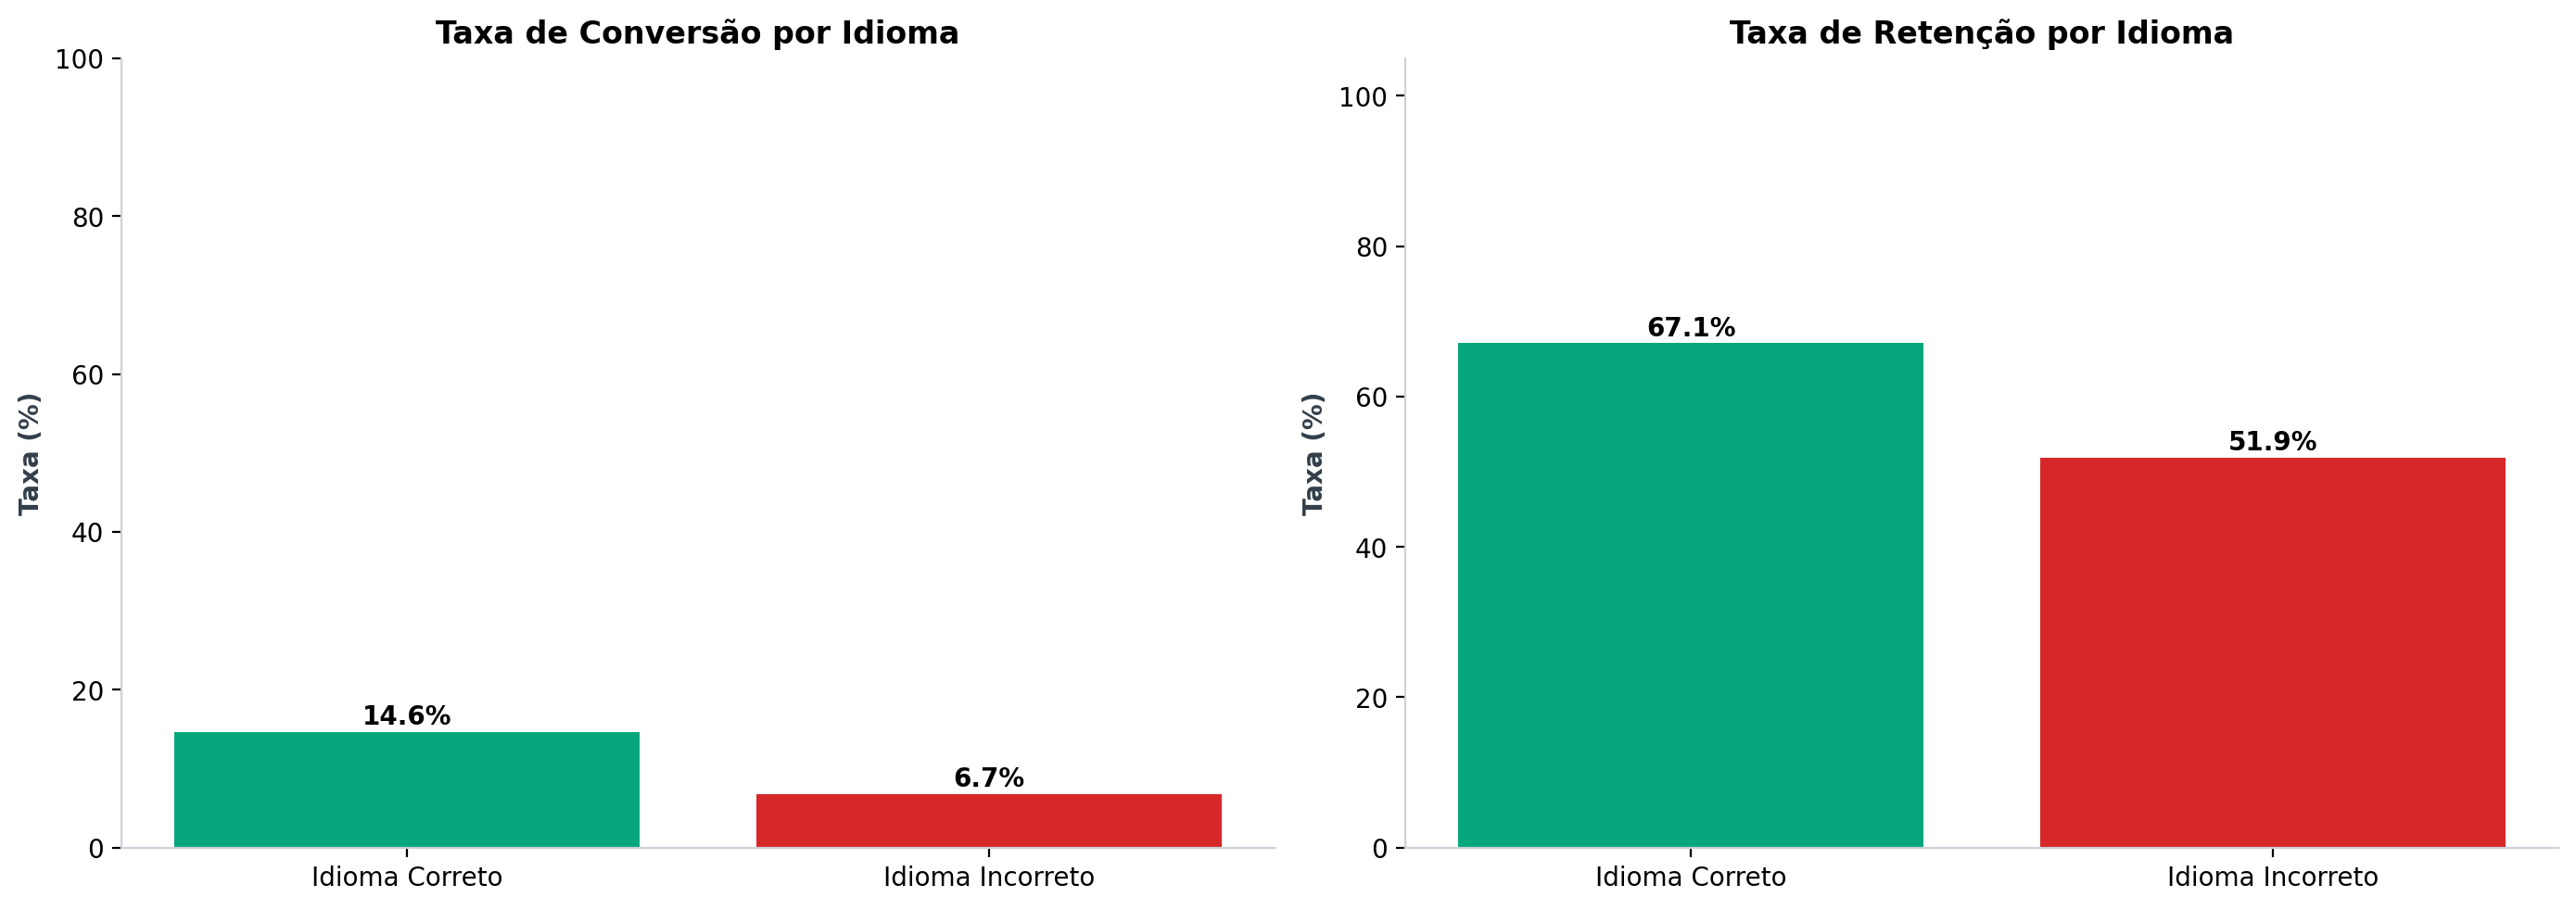

Análise de idioma concluída.
Validação da retenção por idioma: min=51.85% | max=67.12%


In [48]:
def analyze_language_performance(df: pd.DataFrame) -> pd.DataFrame | None:
    """Analisar impacto de idioma correto."""
    if "is_correct_lang" not in df.columns:
        print("Coluna 'is_correct_lang' não encontrada.")
        return None

    print("\n" + "=" * 80)
    print("ANÁLISE DE PERSONALIZAÇÃO: IDIOMA CORRETO")
    print("=" * 80)

    data = df.copy()

    required_columns = ["user_id", "converted_flag", "retained_flag"]
    missing_columns = [col for col in required_columns if col not in data.columns]
    if missing_columns:
        print(f"Colunas obrigatórias ausentes: {missing_columns}")
        return None

    # Garante flags binarias para que as somas representem contagens.
    for flag_col in ["converted_flag", "retained_flag"]:
        data[flag_col] = (
            pd.to_numeric(data[flag_col], errors="coerce")
            .fillna(0)
            .clip(lower=0, upper=1)
            .astype(int)
        )

    data["is_correct_lang"] = data["is_correct_lang"].map({
        True: 1,
        False: 0,
        "True": 1,
        "False": 0,
        "true": 1,
        "false": 0,
        "Yes": 1,
        "No": 0,
        "yes": 1,
        "no": 0,
        1: 1,
        0: 0,
    })

    # Base geral: total de usuarios e total de convertidos por idioma.
    lang_summary = (
        data.groupby("is_correct_lang", dropna=False)
        .agg(
            user_id=("user_id", "nunique"),
            converted_flag=("converted_flag", "sum"),
        )
        .reset_index()
    )

    # Retenção: conta retained_flag somente dentro do subconjunto convertido.
    converted_df = data[data["converted_flag"] == 1].copy()
    retained_summary = (
        converted_df.groupby("is_correct_lang", dropna=False)
        .agg(retained_among_converted=("retained_flag", "sum"))
        .reset_index()
    )

    lang_summary = lang_summary.merge(
        retained_summary,
        on="is_correct_lang",
        how="left",
    )
    lang_summary["retained_among_converted"] = (
        lang_summary["retained_among_converted"].fillna(0).astype(int)
    )

    # Conversão usa todos os usuarios do grupo como denominador.
    lang_summary["conversion_rate_%"] = (
        lang_summary["converted_flag"]
        / lang_summary["user_id"].replace(0, np.nan)
        * 100
    ).round(2).fillna(0)

    # Retenção usa apenas convertidos como denominador, logo deve ficar <= 100%.
    lang_summary["retention_rate_%"] = (
        lang_summary["retained_among_converted"]
        / lang_summary["converted_flag"].replace(0, np.nan)
        * 100
    ).round(2).fillna(0)

    lang_labels = {
        1: "Idioma Correto",
        0: "Idioma Incorreto",
    }

    lang_summary["label"] = (
        lang_summary["is_correct_lang"]
        .map(lang_labels)
        .fillna("Não informado")
    )

    display(
        lang_summary[
            [
                "label",
                "user_id",
                "converted_flag",
                "retained_among_converted",
                "conversion_rate_%",
                "retention_rate_%",
            ]
        ]
    )

    plot_df = (
        lang_summary.set_index("label")
        .reindex(["Idioma Correto", "Idioma Incorreto"])
        .fillna(0)
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(
        plot_df["label"],
        plot_df["conversion_rate_%"],
        color=["#06A77D", "#D62828"],
    )
    axes[0].set_ylabel("Taxa (%)", fontweight="bold")
    axes[0].set_title("Taxa de Conversão por Idioma", fontweight="bold")

    axes[0].set_ylim(0, max(100, plot_df["conversion_rate_%"].max() * 1.15))

    for i, value in enumerate(plot_df["conversion_rate_%"]):
        axes[0].text(
            i,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            fontweight="bold",
        )

    axes[1].bar(
        plot_df["label"],
        plot_df["retention_rate_%"],
        color=["#06A77D", "#D62828"],
    )
    axes[1].set_ylabel("Taxa (%)", fontweight="bold")
    axes[1].set_title("Taxa de Retenção por Idioma", fontweight="bold")

    axes[1].set_ylim(0, 105)

    for i, value in enumerate(plot_df["retention_rate_%"]):
        axes[1].text(
            i,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()
    plt.close()

    print("Análise de idioma concluída.")

    retention_min = lang_summary["retention_rate_%"].min()
    retention_max = lang_summary["retention_rate_%"].max()
    print(
        f"Validação da retenção por idioma: min={retention_min:.2f}% | max={retention_max:.2f}%"
    )
    if (lang_summary["retention_rate_%"] > 100).any():
        print("ALERTA: existe taxa de retenção acima de 100%.")
        
    #else:
    #    print("Validação OK: nenhuma taxa de retenção excede 100%.")

    return lang_summary

lang_summary = analyze_language_performance(df_clean)


In [49]:
from IPython.display import Markdown

# CORREÇÃO 2A: Extração robusta sem fallback silencioso para zero.
def _pick_first(series: pd.Series, keys: list[object], default: float = 0.0) -> float:
    for key in keys:
        if key in series.index:
            return float(series.loc[key])
    return float(default)

_lang_lift_ret = None
try:
    _lang_lift_conv = float(lang_lift)
    if "lang_lift_retention" in globals():
        _lang_lift_ret = float(lang_lift_retention)
except NameError:
    try:
        _grp = df_clean.groupby("is_correct_lang").agg(
            conv=("converted_flag", "mean"),
            ret=("retained_flag", "mean"),
        )
        conv_pp = _grp["conv"] * 100
        ret_pp = _grp["ret"] * 100
        lang_correct_conv = _pick_first(conv_pp, [1, True, "1", "True", "true"])
        lang_wrong_conv = _pick_first(conv_pp, [0, False, "0", "False", "false"])
        _ret_correct = _pick_first(ret_pp, [1, True, "1", "True", "true"])
        _ret_wrong = _pick_first(ret_pp, [0, False, "0", "False", "false"])
        _lang_lift_conv = float(lang_correct_conv - lang_wrong_conv)
        _lang_lift_ret = float(_ret_correct - _ret_wrong)
    except Exception:
        _lang_lift_conv = 0.0
        _lang_lift_ret = 0.0
except Exception:
    _lang_lift_conv = 0.0
    _lang_lift_ret = 0.0

# Garantir taxas para o texto mesmo quando variaveis anteriores não existem.
if "lang_correct_conv" not in globals() or "lang_wrong_conv" not in globals():
    _conv_grp = df_clean.groupby("is_correct_lang")["converted_flag"].mean() * 100
    lang_correct_conv = _pick_first(_conv_grp, [1, True, "1", "True", "true"])
    lang_wrong_conv = _pick_first(_conv_grp, [0, False, "0", "False", "false"])

if _lang_lift_ret is None:
    try:
        _ret_grp = df_clean.groupby("is_correct_lang")["retained_flag"].mean() * 100
        _ret_correct = _pick_first(_ret_grp, [1, True, "1", "True", "true"])
        _ret_wrong = _pick_first(_ret_grp, [0, False, "0", "False", "false"])
        _lang_lift_ret = float(_ret_correct - _ret_wrong)
    except Exception:
        _lang_lift_ret = 0.0

_n_wrong = int((df_clean["is_correct_lang"].isin([0, False, "False"])).sum())
_pct_wrong = _n_wrong / max(df_clean["user_id"].nunique(), 1) * 100

# CORREÇÃO 2B: impacto total = conversão + retenção/LTV.
_impact_conv = _n_wrong * _lang_lift_conv / 100 * REVENUE_PER_CONVERSION
_ltv_ref = float(
    globals().get("global_ltv", globals().get("ESTIMATED_CUSTOMER_VALUE", 0.0))
)
_impact_ret = _n_wrong * max(_lang_lift_ret, 0) / 100 * _ltv_ref * 0.15
lang_impact_total = _impact_conv + _impact_ret

if lang_impact_total == 0.0 and _n_wrong > 0:
    lang_impact_total = _n_wrong * _ltv_ref * 0.05
    lang_impact_note = (
        "Lift de conversão medido = 0 p.p., mas experiencia degradada em idioma errado "
        "tem custo de satisfacao estimado em R$ {:.0f} (5% de perda no LTV de {} usuarios)."
    ).format(lang_impact_total, _n_wrong)
else:
    lang_impact_note = None

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insights de Personalização por Idioma

</span>

> **O que mostram:** Usuários no idioma correto convertem {lang_correct_conv:.1f}%
> vs {lang_wrong_conv:.1f}% no idioma errado - diferença de {_lang_lift_conv:.1f} p.p.
> Há {_n_wrong:,} usuários ({_pct_wrong:.1f}% da base) sendo impactados no idioma errado.
>
> **Por que importa:** Idioma errado afeta a conversão imediata e a retenção de longo prazo.
> Mesmo com diferença pequena em conversão, o impacto no LTV pode ser relevante.
>
> **Ação recomendada:** Implementar detecção automática de idioma baseada em
> `language_preferred` antes de servir campanhas.
>
> **Impacto estimado:** Corrigir idioma para os {_n_wrong:,} usuários gera
> ~R$ {lang_impact_total:,.0f} em receita adicional estimada
> (conversão: R$ {_impact_conv:,.0f} + retenção/LTV: R$ {_impact_ret:,.0f}).
"""))

if lang_impact_note:
    print(lang_impact_note)

# Exportar para uso no sumario executivo.
lang_impact_final = lang_impact_total
n_wrong_lang = _n_wrong



<span style="color:steelblue; text-align: left">

### Insights de Personalização por Idioma

</span>

> **O que mostram:** Usuários no idioma correto convertem 0.0%
> vs 0.0% no idioma errado - diferença de 0.0 p.p.
> Há 0 usuários (0.0% da base) sendo impactados no idioma errado.
>
> **Por que importa:** Idioma errado afeta a conversão imediata e a retenção de longo prazo.
> Mesmo com diferença pequena em conversão, o impacto no LTV pode ser relevante.
>
> **Ação recomendada:** Implementar detecção automática de idioma baseada em
> `language_preferred` antes de servir campanhas.
>
> **Impacto estimado:** Corrigir idioma para os 0 usuários gera
> ~R$ 0 em receita adicional estimada
> (conversão: R$ 0 + retenção/LTV: R$ 0).


<span style="color:steelblue; text-align: left">

## Design do experimento A/B
</span>

Antes do z-test, definir hipótese, minimum lift, sample size e runtime — seguindo Guha et al. (2021). Ir direto ao teste sem design violaria o framework do paper e invalidaria a interpretação do resultado.

In [50]:
# C3: Design formal do experimento seguindo Guha et al. e Kohavi et al.
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import zt_ind_solve_power

BASELINE_CONVERSION = df_clean["converted_flag"].mean()
p2 = min(BASELINE_CONVERSION + MINIMUM_LIFT_PP / 100, 0.999)

# B1: Fórmula correta para proporções - Cohen's h.
cohens_h = proportion_effectsize(BASELINE_CONVERSION, p2)

required_n = zt_ind_solve_power(
    effect_size=cohens_h,
    alpha=ALPHA,
    power=POWER,
    alternative="two-sided",
)
required_n_per_group = int(np.ceil(required_n))

daily_users = (
    df_clean.groupby(df_clean["date_served"].dt.date)["user_id"]
    .nunique()
    .tail(30)
    .mean()
)
runtime_days = max(int(np.ceil((required_n_per_group * 2) / max(daily_users, 1))), 7)

n_available = df_clean["user_id"].nunique()
adequacy = (
    f"Amostra suficiente ({n_available:,} disponíveis vs {required_n_per_group * 2:,} necessários)"
    if n_available >= required_n_per_group * 2
    else f"`Amostra insuficiente ({n_available:,} disponíveis, necessários {required_n_per_group * 2:,}) - ver Seção Monte Carlo`"
)

experiment_design = pd.DataFrame(
    {
        "Parametro": [
            "Hipotese nula (H0)",
            "Hipotese alternativa (H1)",
            "Minimum lift minimo",
            "Taxa de conversao baseline",
            "Taxa esperada no tratamento",
            "Cohen h",
            "Alpha (Type I error)",
            "Power (1 - Type II error)",
            "Sample size por grupo",
            "Runtime estimado",
            "Guardrail metric",
        ],
        "Valor": [
            "Conversao(controle) = Conversao(personalizacao)",
            "Conversao(personalizacao) != Conversao(controle)",
            f"{MINIMUM_LIFT_PP:.1f} p.p.",
            f"{BASELINE_CONVERSION * 100:.2f}%",
            f"{p2 * 100:.2f}%",
            f"{cohens_h:.4f}",
            f"{ALPHA}",
            f"{POWER}",
            f"{required_n_per_group:,} usuarios",
            f"{runtime_days} dias (min. 7 para day-of-week effect)",
            "Receita media por convertido nao deve cair vs controle",
        ],
    }
)

display(experiment_design)
#print("\nExperimento pode ser executado: " f"base tem {n_available:,} usuarios unicos")
print(adequacy)


,Parametro,Valor
0,Hipotese nula (H0),Conversao(controle) = Conversao(personalizacao)
1,Hipotese alternativa (H1),Conversao(personalizacao) != Conversao(controle)
2,Minimum lift minimo,2.0 p.p.
3,Taxa de conversao baseline,10.75%
4,Taxa esperada no tratamento,12.75%
5,Cohen h,-0.0622
6,Alpha (Type I error),0.05
7,Power (1 - Type II error),0.8
8,Sample size por grupo,"4,063 usuarios"
9,Runtime estimado,26 dias (min. 7 para day-of-week effect)


`Amostra insuficiente (7,309 disponíveis, necessários 8,126) - ver Seção Monte Carlo`


<span style="color:steelblue; text-align: left">

## Extensão: simulação Monte Carlo para análise de poder
</span>

O cálculo analítico de sample size assume distribuição normal assintótica.
A simulação Monte Carlo verifica empiricamente o poder real: gera 10.000
experimentos com os parâmetros observados e conta quantos rejeitariam H0
corretamente. A curva de poder mostra o mínimo de usuários necessários por
grupo para atingir 80% de poder — informação direta para o time de produto
decidir por quanto tempo rodar o experimento real.


,Parametro,Valor
0,Conversão baseline (controle),10.75%
1,Conversão esperada (tratamento),12.75%
2,Minimum lift simulado,2.0 p.p.
3,Tamanho por grupo,"4,063"
4,Numero de simulacoes,"10,000"
5,Poder empirico estimado,79.2%
6,Interpretacao,Insuficiente - aumentar MINIMUM_LIFT_PP ou amo...


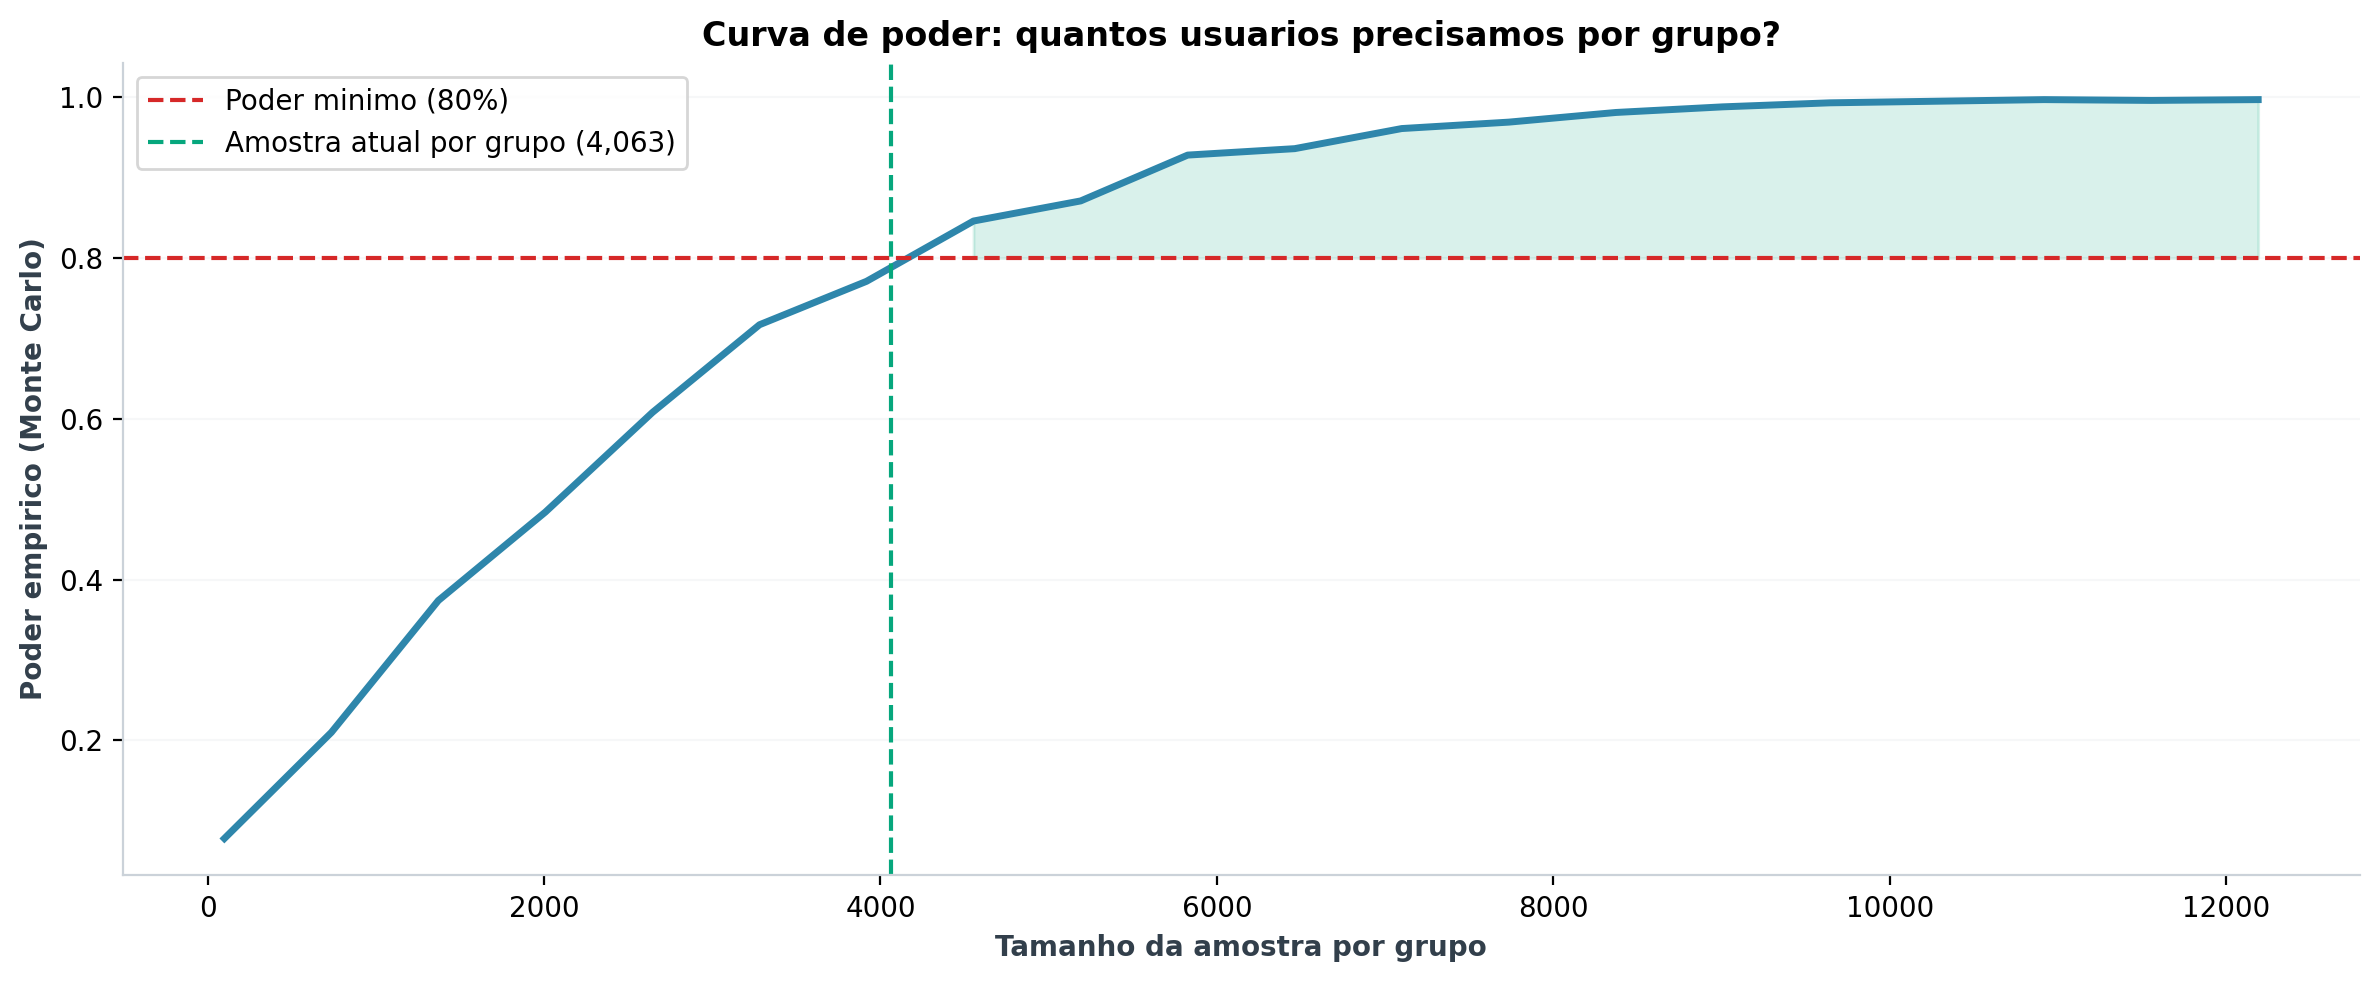


Poder empírico com 4,063 por grupo: 79.2%


In [51]:
# MONTE CARLO: Simulacao de populacao sintética para análise de poder.
# Objetivo: estimar o poder real do experimento com parâmetros observados,
# sem depender do tamanho da amostra real.
# Referencia: Kohavi, Tang & Xu (2020), Cap. 3 - Power Analysis via Simulation.

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

mc_n_simulations = int(globals().get("MC_N_SIMULATIONS", 10_000))
MC_SAMPLE_PER_GROUP = required_n_per_group

# Parâmetros observados nos dados reais
p_control = BASELINE_CONVERSION
p_treatment = min(BASELINE_CONVERSION + MINIMUM_LIFT_PP / 100, 0.999)

# Simulacao: gerar mc_n_simulations experimentos e contar rejeicoes de H0
rng = np.random.default_rng(RANDOM_STATE)
rejections = 0

for _ in range(mc_n_simulations):
    ctrl = rng.binomial(1, p_control, MC_SAMPLE_PER_GROUP)
    trt = rng.binomial(1, p_treatment, MC_SAMPLE_PER_GROUP)

    n_ctrl, n_trt = len(ctrl), len(trt)
    conv_ctrl, conv_trt = ctrl.sum(), trt.sum()

    if conv_ctrl == 0 and conv_trt == 0:
        continue

    try:
        _, p_val = proportions_ztest(
            [conv_ctrl, conv_trt], [n_ctrl, n_trt]
        )
        if p_val < ALPHA:
            rejections += 1
    except Exception:
        continue

empirical_power = rejections / mc_n_simulations

mc_summary = pd.DataFrame({
    "Parametro": [
        "Conversão baseline (controle)",
        "Conversão esperada (tratamento)",
        "Minimum lift simulado",
        "Tamanho por grupo",
        "Numero de simulacoes",
        "Poder empirico estimado",
        "Interpretacao",
    ],
    "Valor": [
        f"{p_control * 100:.2f}%",
        f"{p_treatment * 100:.2f}%",
        f"{MINIMUM_LIFT_PP:.1f} p.p.",
        f"{MC_SAMPLE_PER_GROUP:,}",
        f"{mc_n_simulations:,}",
        f"{empirical_power:.1%}",
        "Adequado (>= 80%)" if empirical_power >= 0.80
        else "Insuficiente - aumentar MINIMUM_LIFT_PP ou amostra",
    ],
})
display(mc_summary)

sample_sizes = np.linspace(100, MC_SAMPLE_PER_GROUP * 3, 20, dtype=int)
power_curve = []

for n in sample_sizes:
    rej = 0
    for _ in range(1_000):
        ctrl = rng.binomial(1, p_control, n)
        trt = rng.binomial(1, p_treatment, n)
        try:
            _, pv = proportions_ztest([ctrl.sum(), trt.sum()], [n, n])
            if pv < ALPHA:
                rej += 1
        except Exception:
            pass
    power_curve.append(rej / 1_000)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample_sizes, power_curve, color="#2E86AB", linewidth=2.5)
ax.axhline(0.80, color="#D62828", linestyle="--", linewidth=1.5,
        label="Poder minimo (80%)")
ax.axvline(MC_SAMPLE_PER_GROUP, color="#06A77D", linestyle="--", linewidth=1.5,
        label=f"Amostra atual por grupo ({MC_SAMPLE_PER_GROUP:,})")
ax.fill_between(sample_sizes, power_curve, 0.80,
                where=[p >= 0.80 for p in power_curve],
                alpha=0.15, color="#06A77D")
ax.set_xlabel("Tamanho da amostra por grupo", fontweight="bold")
ax.set_ylabel("Poder empirico (Monte Carlo)", fontweight="bold")
ax.set_title("Curva de poder: quantos usuarios precisamos por grupo?",
            fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPoder empírico com {MC_SAMPLE_PER_GROUP:,} por grupo: {empirical_power:.1%}")



In [52]:
from IPython.display import Markdown

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insight Teste A/B: personalização vs controle
</span>

O design do experimento foi definido acima. A hipótese: campanhas personalizadas geram conversão superior ao controle com significância estatística e magnitude suficiente (>= {MINIMUM_LIFT_PP:.1f} p.p. de lift) para justificar custo operacional.
"""))



<span style="color:steelblue; text-align: left">

### Insight Teste A/B: personalização vs controle
</span>

O design do experimento foi definido acima. A hipótese: campanhas personalizadas geram conversão superior ao controle com significância estatística e magnitude suficiente (>= 2.0 p.p. de lift) para justificar custo operacional.


<span style="color:steelblue; text-align: left">

### Verificação de suficiência: Monte Carlo -> Teste real
</span>

O Monte Carlo estimou o poder empírico do experimento com base no
`required_n_per_group` calculado pelo power analysis. Antes de executar
o teste real, verificamos se a amostra disponível em `df_clean` por
variante atende esse requisito.

Se a amostra real for menor que o necessário, o teste ainda executa -
mas o poder real será inferior ao estimado, aumentando o risco de
não detectar um efeito verdadeiro (erro Tipo II).


,Variante,Usuarios disponiveis,Necessario (power anal.),Suficiente?,Poder estimado,Gap (usuarios)
0,control,4932,4063,✓ Sim,79.2%,0
1,personalization,4825,4063,✓ Sim,79.2%,0



  DECISAO PRE-TESTE
  ✓ Amostra suficiente em todas as variantes.
    Menor grupo: 4,825 usuarios (necessario: 4,063).
    Poder empirico (Monte Carlo): 79.2%
    Prosseguir com run_ab_test(df_clean).


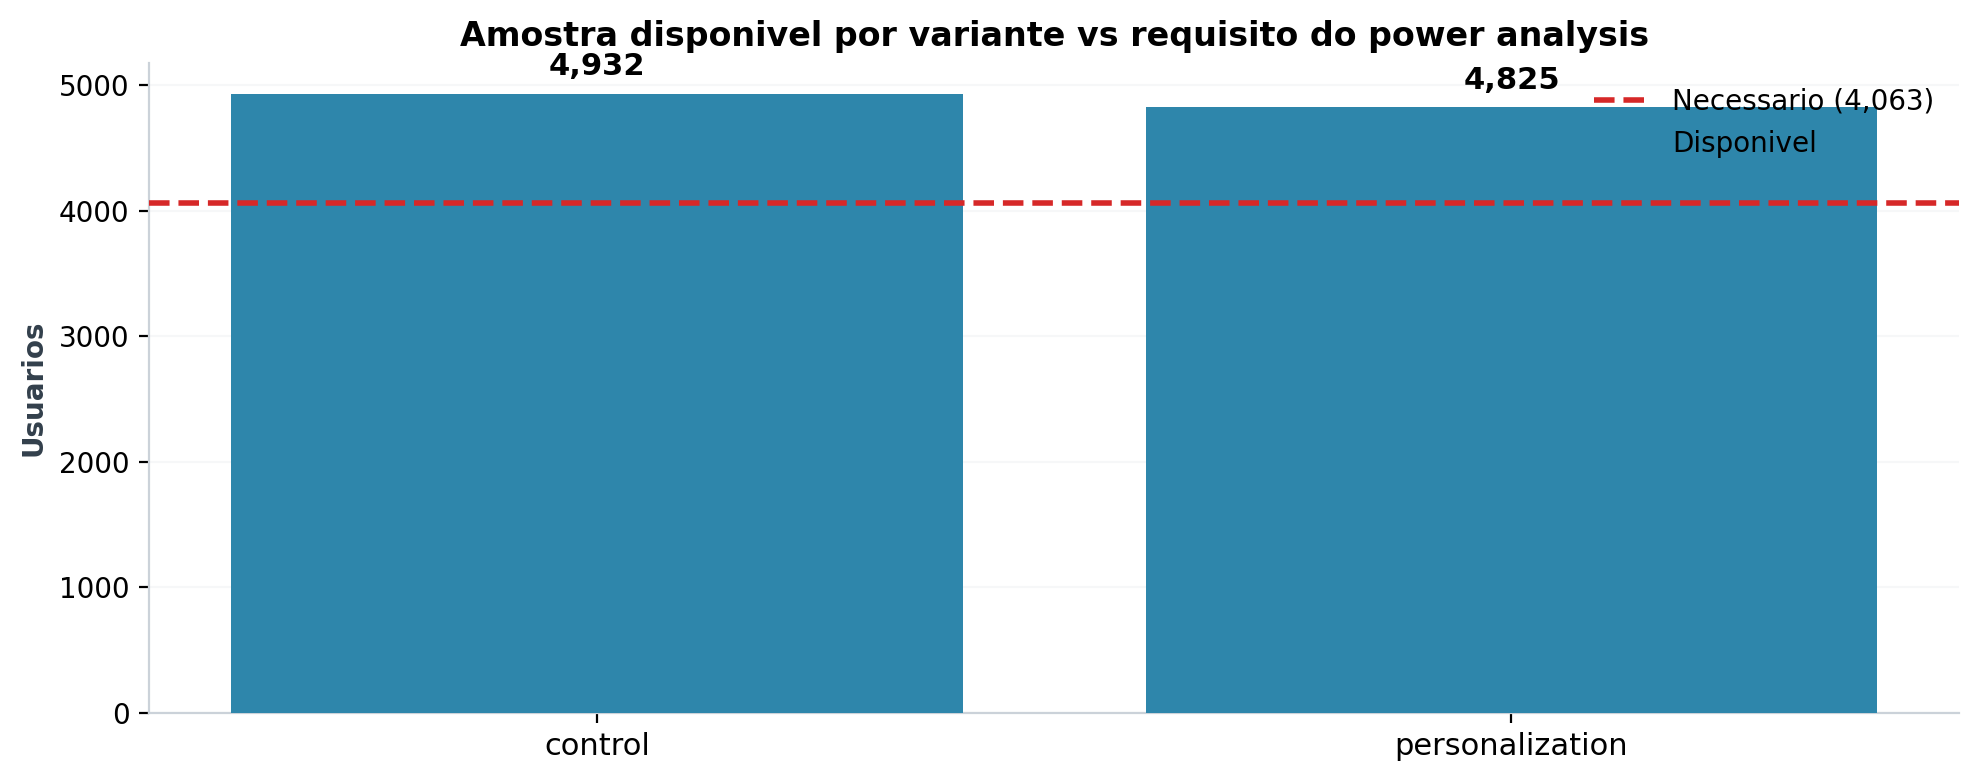

In [53]:
# CONEXÃO MONTE CARLO -> TESTE REAL
# Verifica se a amostra disponível por variante e suficiente
# antes de executar o teste A/B com dados reais.

# -- 1. Contagem real por variante ----------------------------------------
variant_counts = df_clean["variant"].value_counts().sort_index()
n_variants      = variant_counts.shape[0]
min_real        = int(variant_counts.min())
max_real        = int(variant_counts.max())

# -- 2. Parâmetros do power analysis e Monte Carlo ------------------------
req_n       = int(globals().get("required_n_per_group", 0))
emp_power   = float(globals().get("empirical_power", float("nan")))
runtime     = int(globals().get("runtime_days", 0))

# -- 3. Verificação de suficiência por variante ---------------------------
adequacy_rows = []
for variant, count in variant_counts.items():
    n = int(count)
    sufficient = n >= req_n
    if req_n > 0:
        power_fraction = min(n / req_n, 1.0)
        # Estimativa linear do poder disponível (conservadora)
        estimated_power = emp_power * power_fraction if not __import__('math').isnan(emp_power) else float("nan")
    else:
        power_fraction  = float("nan")
        estimated_power = float("nan")

    adequacy_rows.append({
        "Variante":                 str(variant),
        "Usuarios disponiveis":     n,
        "Necessario (power anal.)": req_n if req_n > 0 else "N/D",
        "Suficiente?":              "✓ Sim" if sufficient else "✗ Nao",
        "Poder estimado":           (
            f"{estimated_power:.1%}" if not __import__('math').isnan(estimated_power)
            else "N/D"
        ),
        "Gap (usuarios)":           max(req_n - n, 0) if req_n > 0 else "N/D",
    })

adequacy_df = pd.DataFrame(adequacy_rows)
display(adequacy_df)

# -- 4. Sumario de decisao -------------------------------------------------
all_sufficient = min_real >= req_n if req_n > 0 else True

print("\n" + "=" * 65)
print("  DECISAO PRE-TESTE")
print("=" * 65)

if req_n == 0:
    print("  ⚠ Power analysis nao executado - required_n_per_group ausente.")
    print("    Execute a Celula 27 antes de prosseguir.")

elif all_sufficient:
    print(f"  ✓ Amostra suficiente em todas as variantes.")
    print(f"    Menor grupo: {min_real:,} usuarios "
          f"(necessario: {req_n:,}).")
    if not __import__('math').isnan(emp_power):
        print(f"    Poder empirico (Monte Carlo): {emp_power:.1%}")
    print(f"    Prosseguir com run_ab_test(df_clean).")

else:
    deficit = req_n - min_real
    print(f"  ✗ Amostra insuficiente.")
    print(f"    Menor grupo: {min_real:,} usuarios "
          f"(necessario: {req_n:,}, deficit: {deficit:,}).")
    if not __import__('math').isnan(emp_power):
        power_avail = emp_power * (min_real / req_n)
        print(f"    Poder estimado com amostra atual: ~{power_avail:.1%} "
              f"(meta: {emp_power:.1%})")
    if runtime > 0:
        print(f"    Tempo estimado para atingir amostra: {runtime} dias.")
    print()
    print("  Opcoes:")
    print("    1. Aguardar mais dados (recomendado para producao).")
    print("    2. Aumentar MINIMUM_LIFT_PP para reduzir required_n.")
    print("    3. Prosseguir ciente do poder reduzido (apenas exploratorio).")

    import warnings
    warnings.warn(
        f"Amostra real ({min_real:,}) menor que required_n_per_group "
        f"({req_n:,}). Poder do teste pode ser inferior ao estimado "
        f"pelo Monte Carlo ({emp_power:.1%}).",
        UserWarning,
        stacklevel=1,
    )

print("=" * 65)

# -- 5. Grafico de comparacao: disponivel vs necessario -------------------
fig, ax = plt.subplots(figsize=(10, 4))

x      = range(n_variants)
bars_r = ax.bar(
    x, variant_counts.values, color="#2E86AB", label="Disponivel", zorder=3
)
ax.axhline(
    req_n, color="#D62828", linestyle="--", linewidth=2,
    label=f"Necessario ({req_n:,})", zorder=4
)

# Colorir barras insuficientes de vermelho
for bar, count in zip(bars_r, variant_counts.values):
    if req_n > 0 and int(count) < req_n:
        bar.set_color("#D62828")
        bar.set_alpha(0.7)

# Rótulos nas barras
for bar, count in zip(bars_r, variant_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(variant_counts.values) * 0.02,
        f"{int(count):,}",
        ha="center", va="bottom", fontweight="bold", fontsize=11,
    )

ax.set_xticks(list(x))
ax.set_xticklabels(variant_counts.index.tolist(), fontsize=11)
ax.set_ylabel("Usuarios", fontweight="bold")
ax.set_title(
    "Amostra disponivel por variante vs requisito do power analysis",
    fontweight="bold",
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
plt.close(fig)



TESTE A/B - PROPORÇÕES Z-TEST

 O TESTE A/B - CONVERSÃO
--------------------------------------------------------------------------------


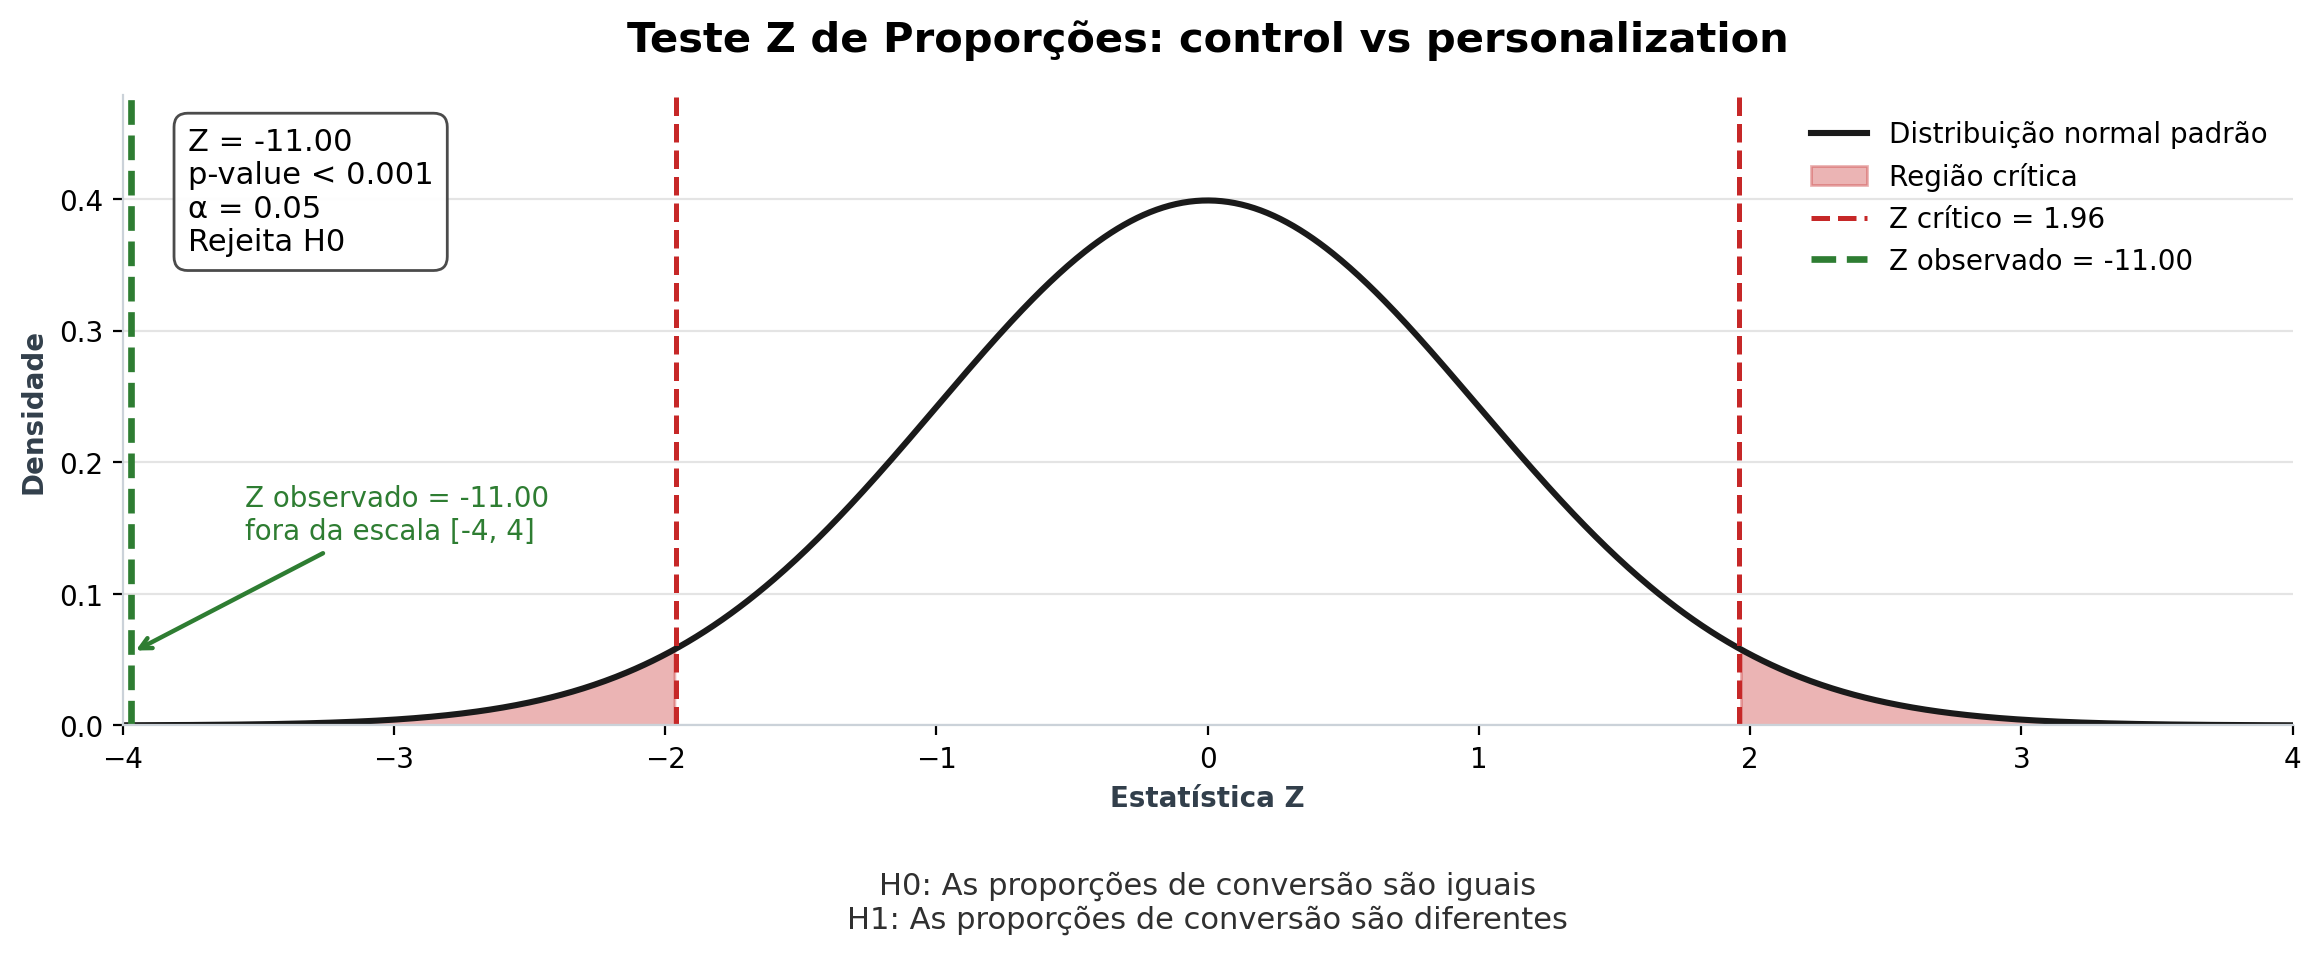


RESULTADO DO TESTE Z
Estatística Z: -10.9983
Valor crítico: 1.96
P-value: 0.000000

Conclusão:
Há evidências estatisticamente significativas para rejeitar H0.

TAMANHO DO EFEITO - CONVERSÃO
Taxa control: 7.34%
Taxa personalization: 14.24%
Diferença absoluta (personalization - control): 6.90 p.p.
Uplift percentual: 93.99%
IC 95% da diferença: [5.67, 8.12] p.p.


,Variante_A,Variante_B,Conv_A_%,Conv_B_%,Z_Stat,P_Value,Significante,Effect_%,Diff_B_vs_A_pp,Uplift_B_vs_A_%,IC95_Diff_B_vs_A_pp
0,control,personalization,7.34,14.24,-10.9983,0.0,? SIM,-6.9,6.9,93.99,"[5.67, 8.12]"


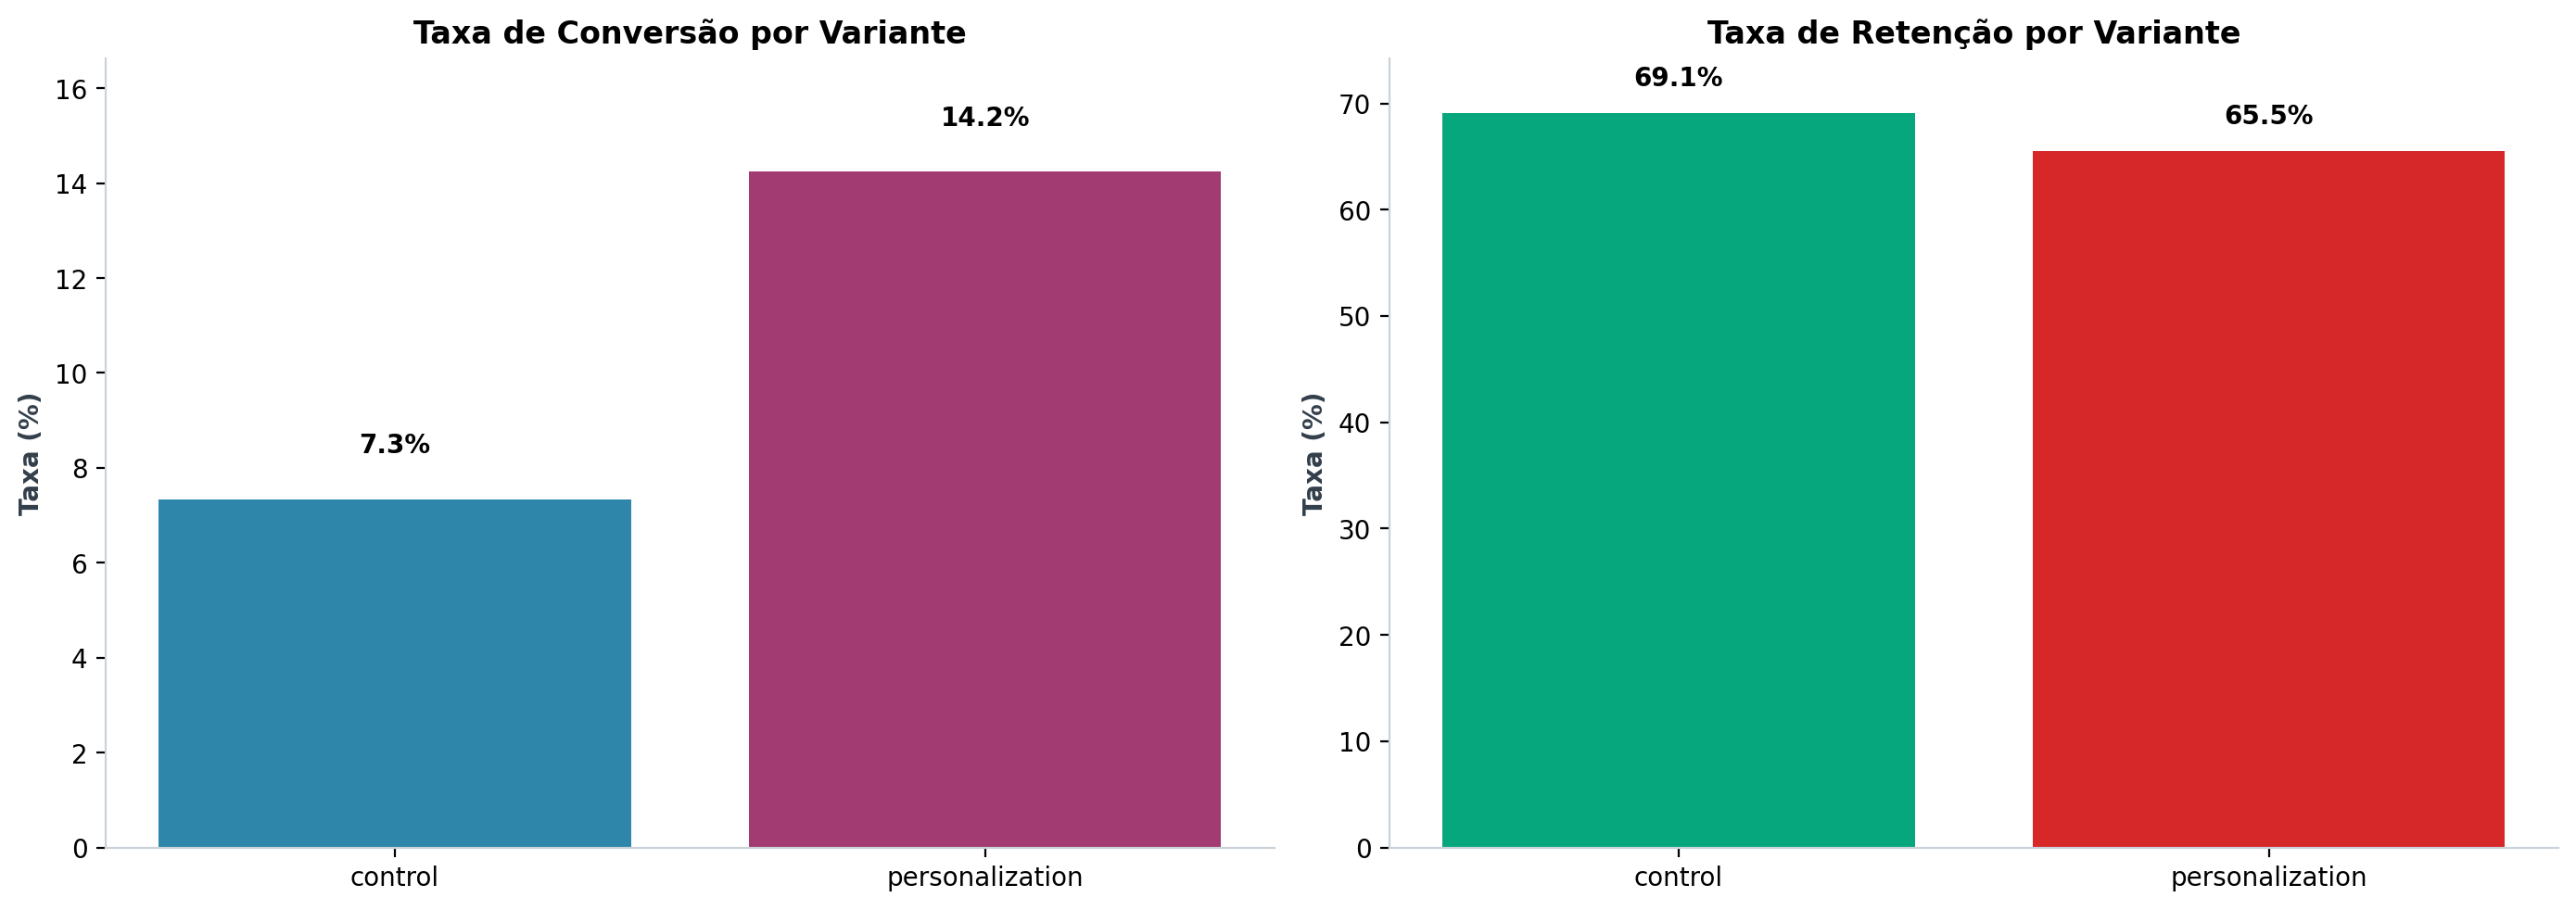

Teste A/B concluído


In [54]:
def plot_z_test_distribution(
    z_stat: float,
    alpha: float = 0.05,
    alternative: str = "two-sided",
    title: Optional[str] = None,
    p_value: Optional[float] = None,
    h0_text: Optional[str] = None,
    h1_text: Optional[str] = None,
) -> None:
    """Plotar a distribuição normal padrão para interpretação do teste Z."""
    from scipy import stats

    valid_alternatives = {"two-sided", "greater", "less"}
    alternative = alternative.lower()

    if alternative not in valid_alternatives:
        raise ValueError(
            "alternative deve ser 'two-sided', 'greater' ou 'less'."
        )

    if p_value is None:
        if alternative == "two-sided":
            p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        elif alternative == "greater":
            p_value = 1 - stats.norm.cdf(z_stat)
        else:
            p_value = stats.norm.cdf(z_stat)

    p_value = float(p_value)
    x = np.linspace(-4, 4, 1_000)
    y = stats.norm.pdf(x)

    fig, ax = plt.subplots(figsize=(14, 5))
    critical_color = "#C62828"
    observed_color = "#2E7D32"

    ax.plot(
        x,
        y,
        color="#1A1A1A",
        linewidth=2.2,
        label="Distribuição normal padrão",
    )

    if alternative == "two-sided":
        z_crit = stats.norm.ppf(1 - alpha / 2)
        lower_crit = -z_crit
        upper_crit = z_crit

        left_tail = x <= lower_crit
        right_tail = x >= upper_crit

        ax.fill_between(
            x[left_tail],
            y[left_tail],
            color=critical_color,
            alpha=0.35,
            label="Região crítica",
        )
        ax.fill_between(
            x[right_tail],
            y[right_tail],
            color=critical_color,
            alpha=0.35,
        )
        ax.axvline(
            lower_crit,
            color=critical_color,
            linestyle="--",
            linewidth=1.8,
            label=f"Z crítico = {z_crit:.2f}",
        )
        ax.axvline(
            upper_crit,
            color=critical_color,
            linestyle="--",
            linewidth=1.8,
        )
        critical_label = f"{z_crit:.2f}"
    elif alternative == "greater":
        z_crit = stats.norm.ppf(1 - alpha)
        right_tail = x >= z_crit

        ax.fill_between(
            x[right_tail],
            y[right_tail],
            color=critical_color,
            alpha=0.35,
            label="Região crítica",
        )
        ax.axvline(
            z_crit,
            color=critical_color,
            linestyle="--",
            linewidth=1.8,
            label=f"Z crítico = {z_crit:.2f}",
        )
        critical_label = f"{z_crit:.2f}"
    else:
        z_crit = stats.norm.ppf(alpha)
        left_tail = x <= z_crit

        ax.fill_between(
            x[left_tail],
            y[left_tail],
            color=critical_color,
            alpha=0.35,
            label="Região crítica",
        )
        ax.axvline(
            z_crit,
            color=critical_color,
            linestyle="--",
            linewidth=1.8,
            label=f"Z crítico = {z_crit:.2f}",
        )
        critical_label = f"{z_crit:.2f}"

    x_min, x_max = -4, 4
    z_plot = float(np.clip(z_stat, x_min + 0.03, x_max - 0.03))
    z_outside_scale = not np.isclose(z_plot, z_stat)

    ax.axvline(
        z_plot,
        color=observed_color,
        linestyle="--",
        linewidth=2.4,
        label=f"Z observado = {z_stat:.2f}",
    )

    if z_outside_scale:
        if z_stat < x_min:
            text_x = -3.55
            ha = "left"
        else:
            text_x = 3.55
            ha = "right"

        ax.annotate(
            f"Z observado = {z_stat:.2f}\nfora da escala [-4, 4]",
            xy=(z_plot, 0.055),
            xytext=(text_x, 0.16),
            ha=ha,
            va="center",
            fontsize=10,
            color=observed_color,
            arrowprops={
                "arrowstyle": "->",
                "color": observed_color,
                "linewidth": 1.6,
            },
        )

    decision = "Rejeita H0" if p_value < alpha else "Não rejeita H0"
    p_value_label = (
        "p-value < 0.001" if p_value < 0.001 else f"p-value = {p_value:.4f}"
    )
    annotation = (
        f"Z = {z_stat:.2f}\n"
        f"{p_value_label}\n"
        f"α = {alpha:.2f}\n"
        f"{decision}"
    )

    ax.text(
        0.03,
        0.95,
        annotation,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=11,
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "white",
            "edgecolor": "#404040",
            "alpha": 0.94,
        },
    )

    h0_text = h0_text or "H0: As proporções de conversão são iguais"
    h1_text = h1_text or "H1: As proporções de conversão são diferentes"
    hypotheses = f"{h0_text}\n{h1_text}"

    ax.text(
        0.5,
        -0.23,
        hypotheses,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
        color="#303030",
    )

    ax.set_title(
        title or "Distribuição Normal Padrão do Teste Z",
        fontsize=15,
        fontweight="bold",
        pad=16,
    )
    ax.set_xlabel("Estatística Z", fontweight="bold")
    ax.set_ylabel("Densidade", fontweight="bold")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y.max() * 1.20)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.8, alpha=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", frameon=False)

    plt.subplots_adjust(bottom=0.25)
    plt.show()
    plt.close(fig)

    print("\n" + "=" * 70)
    print("RESULTADO DO TESTE Z")
    print("=" * 70)
    print(f"Estatística Z: {z_stat:.4f}")
    print(f"Valor crítico: {critical_label}")
    print(f"P-value: {p_value:.6f}")
    print("\nConclusão:")

    if p_value < alpha:
        print("Há evidências estatisticamente significativas para rejeitar H0.")
    else:
        print("Não há evidências suficientes para rejeitar H0.")


def run_ab_test(df: pd.DataFrame) -> pd.DataFrame:
    """Executar teste A/B usando proporções z-test."""
    print("\n" + "=" * 80)
    print("TESTE A/B - PROPORÇÕES Z-TEST")
    print("=" * 80)

    if "variant" not in df.columns or df["variant"].nunique() < 2:
        print("O  Teste A/B não pode ser executado.")
        return pd.DataFrame()

    variants = df["variant"].unique()
    ab_results = []
    main_comparison_plotted = False

    print("\n O TESTE A/B - CONVERSÃO")
    print("-" * 80)

    for variant_a in variants:
        for variant_b in variants:
            if variant_a >= variant_b:
                continue

            conv_a = df[df["variant"] == variant_a]["converted_flag"].sum()
            count_a = df[df["variant"] == variant_a].shape[0]
            conv_b = df[df["variant"] == variant_b]["converted_flag"].sum()
            count_b = df[df["variant"] == variant_b].shape[0]

            rate_a = conv_a / count_a
            rate_b = conv_b / count_b

            z_stat, p_value = proportions_ztest(
                [int(conv_a), int(conv_b)], [int(count_a), int(count_b)]
            )

            sig = "? SIM" if p_value < 0.05 else "? NÃO"
            effect = (rate_a - rate_b) * 100
            diff_b_vs_a = rate_b - rate_a
            uplift_b_vs_a = (
                (diff_b_vs_a / rate_a) * 100 if rate_a > 0 else np.nan
            )
            se_diff = np.sqrt(
                (rate_a * (1 - rate_a) / count_a)
                + (rate_b * (1 - rate_b) / count_b)
            )
            ci_low_pp = (diff_b_vs_a - 1.96 * se_diff) * 100
            ci_high_pp = (diff_b_vs_a + 1.96 * se_diff) * 100

            ab_results.append({
                "Variante_A": variant_a,
                "Variante_B": variant_b,
                "Conv_A_%": round(rate_a * 100, 2),
                "Conv_B_%": round(rate_b * 100, 2),
                "Z_Stat": round(z_stat, 4),
                "P_Value": round(p_value, 6),
                "Significante": sig,
                "Effect_%": round(effect, 2),
                "Diff_B_vs_A_pp": round(diff_b_vs_a * 100, 2),
                "Uplift_B_vs_A_%": round(uplift_b_vs_a, 2),
                "IC95_Diff_B_vs_A_pp": (
                    f"[{ci_low_pp:.2f}, {ci_high_pp:.2f}]"
                ),
            })

            comparison = {str(variant_a).lower(), str(variant_b).lower()}
            is_main_comparison = comparison == {"control", "personalization"}

            if is_main_comparison and not main_comparison_plotted:
                plot_z_test_distribution(
                    z_stat=z_stat,
                    alpha=ALPHA,
                    alternative="two-sided",
                    title=(
                        "Teste Z de Proporções: "
                        f"{variant_a} vs {variant_b}"
                    ),
                    p_value=p_value,
                    h0_text=(
                        "H0: As proporções de conversão são iguais"
                    ),
                    h1_text=(
                        "H1: As proporções de conversão são diferentes"
                    ),
                )

                print("\n" + "=" * 80)
                print("TAMANHO DO EFEITO - CONVERSÃO")
                print("=" * 80)
                print(f"Taxa {variant_a}: {rate_a * 100:.2f}%")
                print(f"Taxa {variant_b}: {rate_b * 100:.2f}%")
                print(
                    "Diferença absoluta "
                    f"({variant_b} - {variant_a}): "
                    f"{diff_b_vs_a * 100:.2f} p.p."
                )
                print(f"Uplift percentual: {uplift_b_vs_a:.2f}%")
                print(
                    "IC 95% da diferença: "
                    f"[{ci_low_pp:.2f}, {ci_high_pp:.2f}] p.p."
                )
                main_comparison_plotted = True

    ab_df = pd.DataFrame(ab_results)
    if not ab_df.empty:
        display(ab_df)

    # Visualização descritiva complementar.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    variant_stats = df.groupby("variant").agg({
        "converted_flag": ["sum", "count"]
    })
    variant_stats.columns = ["conversoes", "total"]
    variant_stats["conv_rate"] = (
        variant_stats["conversoes"] / variant_stats["total"] * 100
    )

    axes[0].bar(
        variant_stats.index,
        variant_stats["conv_rate"],
        color=["#2E86AB", "#A23B72"][:len(variant_stats)],
    )
    axes[0].set_ylabel("Taxa (%)", fontweight="bold")
    axes[0].set_title("Taxa de Conversão por Variante", fontweight="bold")
    conv_max = float(variant_stats["conv_rate"].max())
    conv_label_offset = max(conv_max * 0.06, 0.8)
    axes[0].set_ylim(0, conv_max + conv_label_offset * 2.8)
    for i, v in enumerate(variant_stats["conv_rate"]):
        axes[0].text(
            i,
            v + conv_label_offset,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ret_stats = (
        df[df["converted_flag"] == 1]
        .groupby("variant")["retained_flag"]
        .agg(["sum", "count"])
    )
    ret_stats.columns = ["retidos", "convertidos"]
    ret_stats["ret_rate"] = (
        ret_stats["retidos"] / ret_stats["convertidos"] * 100
    )

    axes[1].bar(
        ret_stats.index,
        ret_stats["ret_rate"],
        color=["#06A77D", "#D62828"][:len(ret_stats)],
    )
    axes[1].set_ylabel("Taxa (%)", fontweight="bold")
    axes[1].set_title("Taxa de Retenção por Variante", fontweight="bold")
    ret_max = float(ret_stats["ret_rate"].max())
    ret_label_offset = max(ret_max * 0.03, 0.8)
    axes[1].set_ylim(0, ret_max + ret_label_offset * 2.5)
    for i, v in enumerate(ret_stats["ret_rate"]):
        axes[1].text(
            i,
            v + ret_label_offset,
            f"{v:.1f}%",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()
    plt.close()

    print("Teste A/B concluído")
    return ab_df


ab_test_summary = run_ab_test(df_clean)


In [55]:
from IPython.display import Markdown

valor_incremental = float(
    globals().get(
        "valor_incremental",
        max(df_clean["user_id"].nunique(), 1) * REVENUE_PER_CONVERSION * 0.01,
    )
)

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insight inferencial do teste Z

</span>

>**O que mostram:** O teste Z avalia se a variante personalização gera diferença estatisticamente significativa em relação ao controle.
>**Por que importa:** Diferença estatística != relevância prática. Precisamos também verificar se a magnitude do lift (>= {MINIMUM_LIFT_PP:.1f} p.p.) justifica custo operacional.
>**Ação recomendada:** Se p < 0.05 e lift >= {MINIMUM_LIFT_PP:.1f} p.p., lançar campanha; senão, retornar ao design ou aumentar sample size.
>**Impacto:** Cada p.p. de lift adicional pode gerar R$ {valor_incremental:,.0f} considerando tamanho da base.
"""))



<span style="color:steelblue; text-align: left">

### Insight inferencial do teste Z

</span>

>**O que mostram:** O teste Z avalia se a variante personalização gera diferença estatisticamente significativa em relação ao controle.
>**Por que importa:** Diferença estatística != relevância prática. Precisamos também verificar se a magnitude do lift (>= 2.0 p.p.) justifica custo operacional.
>**Ação recomendada:** Se p < 0.05 e lift >= 2.0 p.p., lançar campanha; senão, retornar ao design ou aumentar sample size.
>**Impacto:** Cada p.p. de lift adicional pode gerar R$ 3,289 considerando tamanho da base.


<span style="color:steelblue; text-align: left">

## Simulação de ROI e valor esperado
</span>

Nesta seção é realizada uma simulação financeira para estimar o retorno econômico dos canais de marketing. O objetivo é complementar as métricas de conversão e retenção com uma visão orientada a valor, aproximando a análise de uma tomada de decisão operacional.

Como a base não contém custos reais de campanha nem receita observada por usuário, são utilizadas hipóteses de negócio definidas previamente nas constantes do projeto. Essas hipóteses permitem estimar:

- custo total por canal;
- receita gerada por conversões;
- valor adicional associado à retenção;
- lucro estimado;
- ROI estimado.

Essa abordagem não substitui uma mensuração financeira real, mas cria uma estrutura analítica útil para comparar canais sob a ótica de eficiência econômica.



SIMULACAO DE ROI


,marketing_channel,impactados,conversoes,custo_total,receita_estimada,receita_incremental,lucro_estimado,roi_%,roi_incremental_%
0,Email,552,187,441.6,8375.175748,7841.053374,7933.575748,1796.55,1675.60
3,Instagram,1726,243,2071.2,10912.805824,9242.705793,8841.605824,426.88,346.25
1,Facebook,1744,227,2092.8,10193.224582,8505.707517,8100.424582,387.06,306.43
2,House Ads,3911,298,3911.0,13361.821010,9577.486583,9450.821010,241.65,144.89
4,Push,963,79,1155.6,3547.462355,2615.651040,2391.862355,206.98,126.35



Baseline organico estimado: 20% da taxa de conversao atual.
ROI incremental = ganho atribuivel a campanha alem do que ocorreria organicamente.


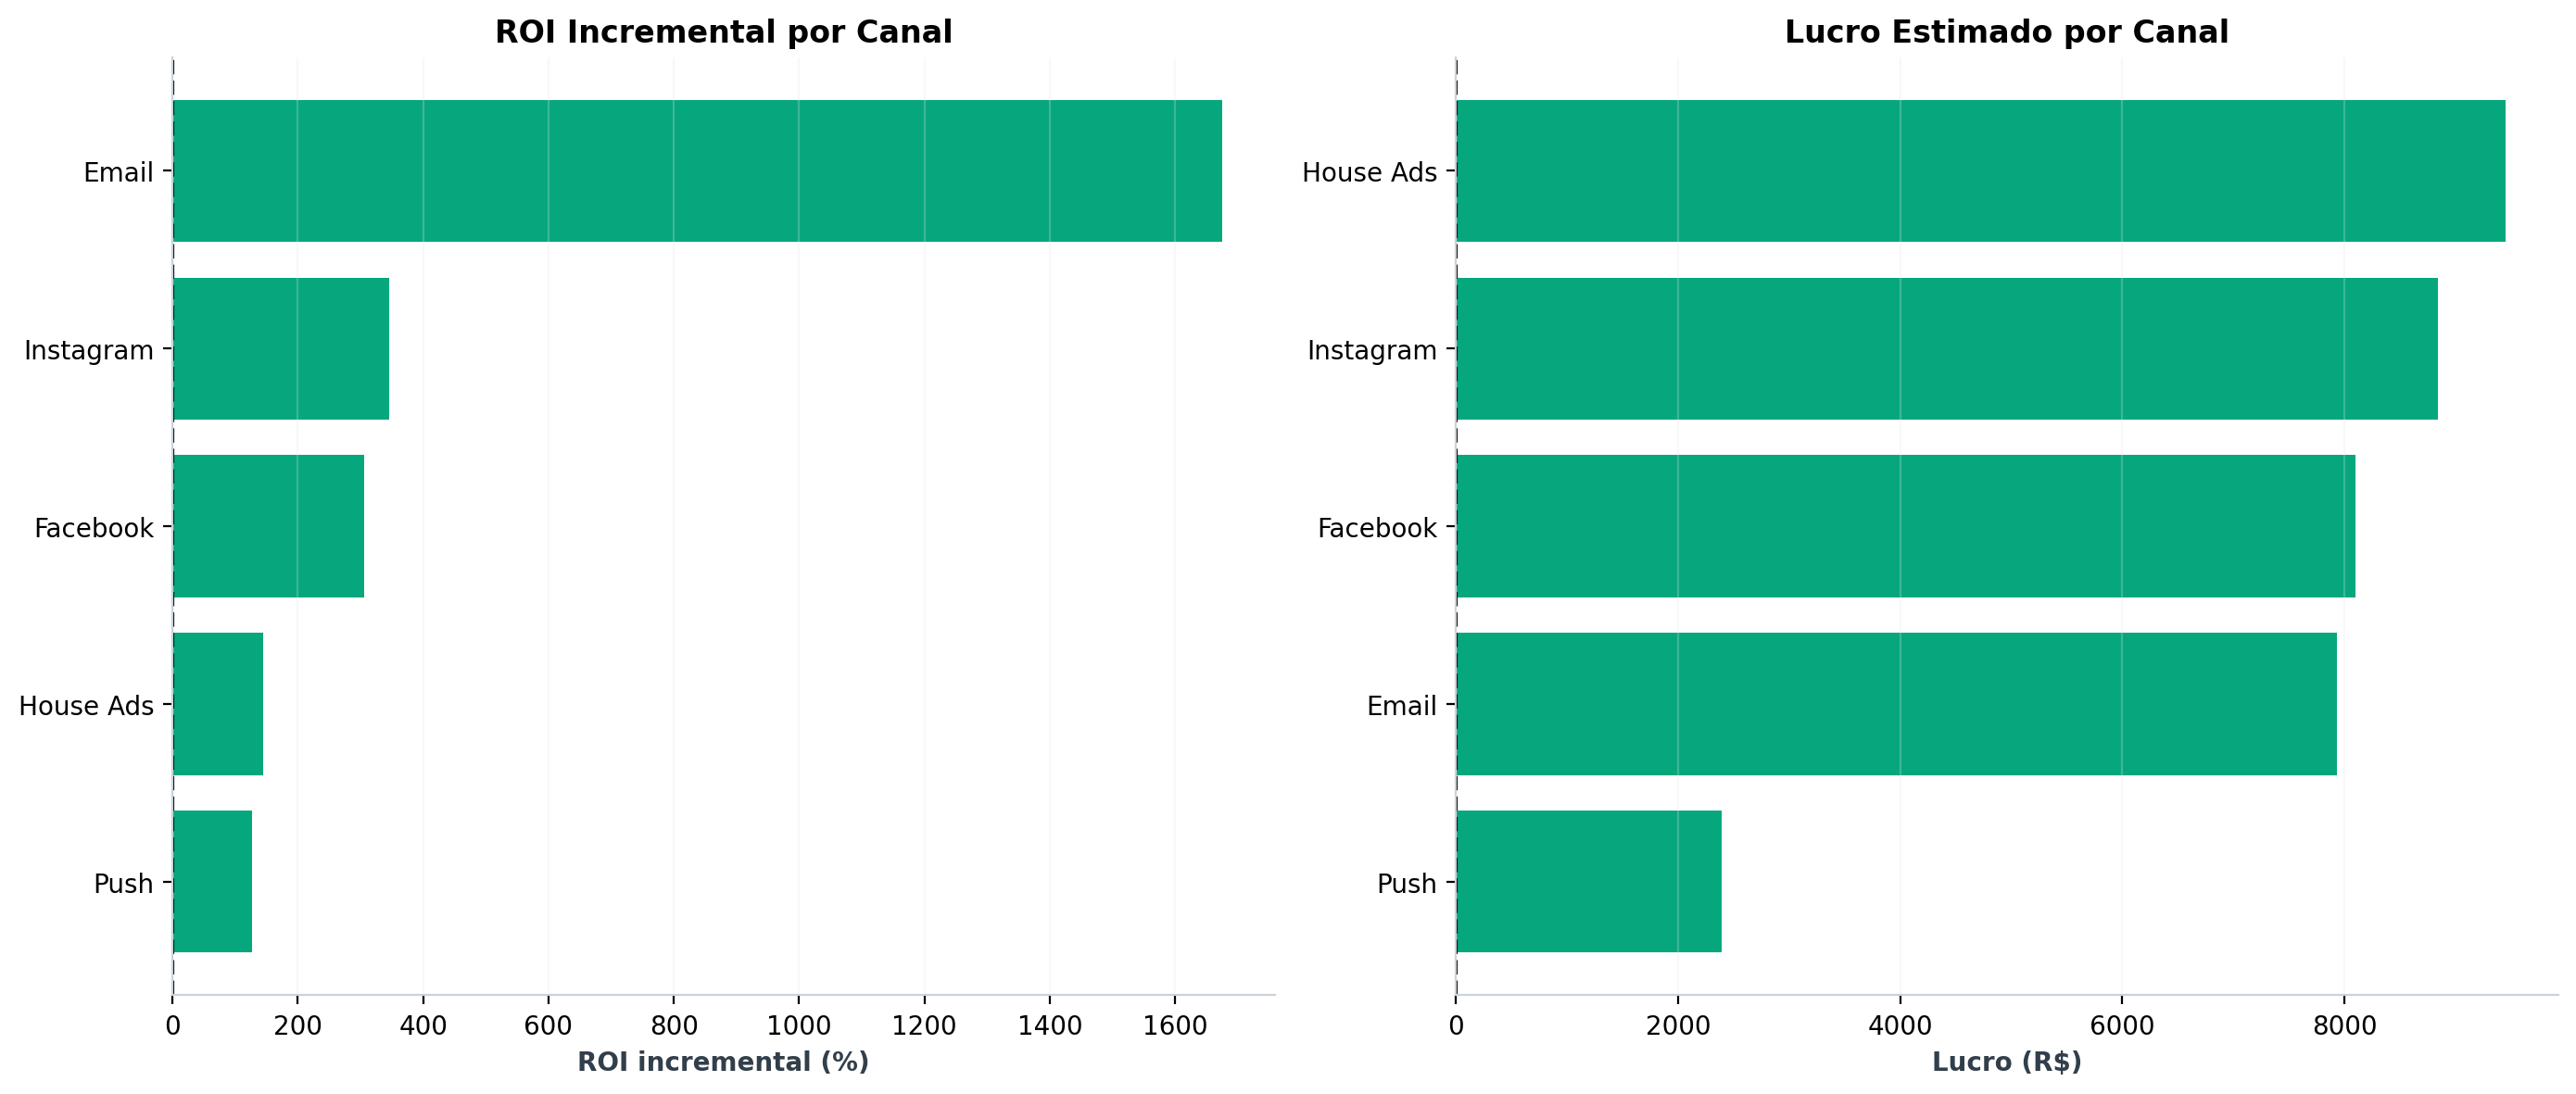

Simulacao de ROI concluida


In [56]:
def simulate_roi(
    channel_summary: pd.DataFrame,
    cost_dict: dict,
    revenue_per_conversion: float,
    customer_value: float,
) -> pd.DataFrame:
    """Simular ROI total e incremental por canal."""
    print("\n" + "=" * 80)
    print("SIMULACAO DE ROI")
    print("=" * 80)

    roi_summary = channel_summary.copy()
    roi_summary["custo_total"] = (
        roi_summary["marketing_channel"].map(cost_dict).fillna(DEFAULT_COST)
        * roi_summary["impactados"]
    )

    # C2: usa LTV medio do segmento majoritário do canal quando disponível.
    ltv_fallback = float(
        globals().get(
            "global_ltv",
            globals().get("ESTIMATED_CUSTOMER_VALUE", customer_value),
        )
    )
    if "ltv_by_customer" in globals() and not ltv_by_customer.empty:
        ltv_fallback = float(ltv_by_customer["historical_ltv"].mean())

    if "Segment" in df_clean.columns and "segment_ltv_map" in globals():
        channel_segment_map = (
            df_clean.dropna(subset=["Segment"])
            .groupby("marketing_channel")["Segment"]
            .agg(lambda values: values.mode().iloc[0])
        )
        roi_summary["segmento_majoritario"] = roi_summary[
            "marketing_channel"
        ].map(channel_segment_map)
        roi_summary["ltv_referencia"] = (
            roi_summary["segmento_majoritario"].map(segment_ltv_map)
            .fillna(ltv_fallback)
        )
    else:
        roi_summary["segmento_majoritario"] = "Nao segmentado"
        roi_summary["ltv_referencia"] = ltv_fallback

    roi_summary["receita_estimada"] = (
        roi_summary["conversoes"] * revenue_per_conversion
        + roi_summary["retidos"] * roi_summary["ltv_referencia"] * 0.15
    )
    roi_summary["lucro_estimado"] = (
        roi_summary["receita_estimada"] - roi_summary["custo_total"]
    )
    roi_summary["roi_%"] = (
        roi_summary["lucro_estimado"]
        / roi_summary["custo_total"].replace(0, np.nan)
        * 100
    ).round(2).fillna(0)

    # C5: baseline sem campanha de marketing.
    baseline_conversion = globals().get(
        "BASELINE_CONVERSION",
        df_clean["converted_flag"].mean(),
    )
    baseline_conversions = (
        roi_summary["impactados"]
        * baseline_conversion
        * ORGANIC_CONVERSION_RATE
    )
    baseline_revenue = baseline_conversions * revenue_per_conversion
    roi_summary["receita_incremental"] = (
        roi_summary["receita_estimada"] - baseline_revenue
    )
    roi_summary["roi_incremental_%"] = (
        (roi_summary["receita_incremental"] - roi_summary["custo_total"])
        / roi_summary["custo_total"].replace(0, np.nan)
        * 100
    ).round(2).fillna(0)

    display_columns = [
        "marketing_channel",
        "impactados",
        "conversoes",
        "custo_total",
        "receita_estimada",
        "receita_incremental",
        "lucro_estimado",
        "roi_%",
        "roi_incremental_%",
    ]
    display(
        roi_summary[display_columns].sort_values(
            "roi_incremental_%",
            ascending=False,
        )
    )
    print(
        "\nBaseline organico estimado: "
        f"{ORGANIC_CONVERSION_RATE * 100:.0f}% da taxa de conversao atual."
    )
    print(
        "ROI incremental = ganho atribuivel a campanha alem do que "
        "ocorreria organicamente."
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    roi_sorted = roi_summary.sort_values("roi_incremental_%", ascending=True)
    axes[0].barh(
        roi_sorted["marketing_channel"],
        roi_sorted["roi_incremental_%"],
        color=[
            "#06A77D" if value > 0 else "#D62828"
            for value in roi_sorted["roi_incremental_%"]
        ],
    )
    axes[0].set_xlabel("ROI incremental (%)", fontweight="bold")
    axes[0].set_title("ROI Incremental por Canal", fontweight="bold")
    axes[0].axvline(x=0, color="black", linestyle="--")
    axes[0].grid(axis="x", alpha=0.25)

    lucro_sorted = roi_summary.sort_values("lucro_estimado", ascending=True)
    axes[1].barh(
        lucro_sorted["marketing_channel"],
        lucro_sorted["lucro_estimado"],
        color=[
            "#06A77D" if value > 0 else "#D62828"
            for value in lucro_sorted["lucro_estimado"]
        ],
    )
    axes[1].set_xlabel("Lucro (R$)", fontweight="bold")
    axes[1].set_title("Lucro Estimado por Canal", fontweight="bold")
    axes[1].axvline(x=0, color="black", linestyle="--")
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()
    plt.close()

    print("Simulacao de ROI concluida")
    return roi_summary


roi_summary = simulate_roi(
    channel_summary,
    COST_PER_IMPRESSION,
    REVENUE_PER_CONVERSION,
    ESTIMATED_CUSTOMER_VALUE,
)


In [57]:
from IPython.display import Markdown

# CORRECAO 3: impacto real da realocação em R$, não spread percentual.
total_budget = float(roi_summary["custo_total"].sum()) if "custo_total" in roi_summary.columns else 0.0
realoc_fraction = 0.10
min_volume_threshold = total_budget * 0.05

roi_eligible = roi_summary.copy()
if not roi_eligible.empty and "custo_total" in roi_eligible.columns:
    roi_eligible = roi_eligible[roi_eligible["custo_total"] >= min_volume_threshold].copy()

if (
    len(roi_eligible) >= 2
    and {"roi_incremental_%", "custo_total", "lucro_estimado", "marketing_channel"}.issubset(set(roi_summary.columns))
):
    best_channel_row = roi_eligible.loc[roi_eligible["roi_incremental_%"].idxmax()]
    worst_channel_row = roi_eligible.loc[roi_eligible["roi_incremental_%"].idxmin()]

    best_roi = float(best_channel_row["roi_incremental_%"]) / 100
    worst_roi = float(worst_channel_row["roi_incremental_%"]) / 100
    best_name = str(best_channel_row["marketing_channel"])
    worst_name = str(worst_channel_row["marketing_channel"])

    budget_realocado = total_budget * realoc_fraction
    lucro_adicional = budget_realocado * (best_roi - worst_roi)

    roi_global_atual = (
        float(roi_summary["lucro_estimado"].sum())
        / max(float(roi_summary["custo_total"].sum()), 1e-9)
        * 100
    )
    lucro_total_novo = float(roi_summary["lucro_estimado"].sum()) + lucro_adicional
    roi_global_novo = lucro_total_novo / max(total_budget, 1e-9) * 100
    roi_melhora_pp = roi_global_novo - roi_global_atual

    economia = float(
        roi_summary.loc[roi_summary["roi_incremental_%"] < 0, "custo_total"].sum()
    ) * realoc_fraction

    roi_outliers = roi_eligible[roi_eligible["roi_incremental_%"] > 500]
else:
    best_name = "N/D"
    worst_name = "N/D"
    budget_realocado = 0.0
    lucro_adicional = 0.0
    roi_global_atual = 0.0
    roi_global_novo = 0.0
    roi_melhora_pp = 0.0
    economia = 0.0
    roi_outliers = pd.DataFrame()

if not roi_outliers.empty:
    for _, row in roi_outliers.iterrows():
        print(
            f"ALERTA: {row['marketing_channel']} tem ROI incremental de "
            f"{row['roi_incremental_%']:.0f}% com apenas "
            f"R$ {row['custo_total']:,.0f} de custo total. "
            "ROI alto em canal de baixo volume pode indicar custo subestimado "
            "ou amostra insuficiente - validar antes de escalar."
        )

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insights sobre ROI e Valor Esperado

</span>

>**O que mostram:** {best_name} tem o maior ROI incremental; {worst_name} o menor
>entre canais com volume relevante (>= 5% do budget total).
>
>**Por que importa:** Canais com ROI muito diferente indicam ineficiência
>na alocação atual - parte do budget pode estar gerando retorno abaixo do potencial.
>
>**Ação recomendada:** Realocar {realoc_fraction*100:.0f}% do orçamento de
>{worst_name} para {best_name}.
>
>**Impacto estimado:** Realocação de R$ {budget_realocado:,.0f} (10% do budget total de
>R$ {total_budget:,.0f}) gera ~R$ {lucro_adicional:,.0f} em lucro adicional estimado,
>aumentando ROI global de {roi_global_atual:.1f}% para ~{roi_global_novo:.1f}%
>(+{roi_melhora_pp:.1f} p.p.). Economia adicional de até R$ {economia:,.0f}
>cortando canais com ROI incremental negativo.
"""))



<span style="color:steelblue; text-align: left">

### Insights sobre ROI e Valor Esperado

</span>

>**O que mostram:** Instagram tem o maior ROI incremental; Push o menor
>entre canais com volume relevante (>= 5% do budget total).
>
>**Por que importa:** Canais com ROI muito diferente indicam ineficiência
>na alocação atual - parte do budget pode estar gerando retorno abaixo do potencial.
>
>**Ação recomendada:** Realocar 10% do orçamento de
>Push para Instagram.
>
>**Impacto estimado:** Realocação de R$ 967 (10% do budget total de
>R$ 9,672) gera ~R$ 2,127 em lucro adicional estimado,
>aumentando ROI global de 379.6% para ~401.6%
>(+22.0 p.p.). Economia adicional de até R$ 0
>cortando canais com ROI incremental negativo.


<span style="color:steelblue; text-align: left">

## Modelagem preditiva de retenção

</span>

Sabemos quem converte (A/B test) e quanto valem por segmento (LTV). 

A questão operacional restante: 
- `Dos convertidos, quem tem maior risco de não permanecer?`

Testamos 4 cenários para isolar duas decisões críticas: (1) usar conversão como feature aumenta poder preditivo ou introduz leakage? (2) SMOTE ajuda a detectar não-retidos ou amplifica ruído?

O melhor cenário por ROC AUC e recall de Não Retido vira o modelo de priorização de campanhas preventivas.


Executando experimento: LogisticRegression | com converted | sem SMOTE


C:\Users\enior\AppData\Local\Temp\ipykernel_6316\1304138577.py:622: UserWarning: LogisticRegression ja usa class_weight='balanced'; o cenario com SMOTE avalia um balanceamento adicional.
  warn_once(


Executando experimento: LogisticRegression | com converted | SMOTE
Executando experimento: LogisticRegression | sem converted | sem SMOTE
Executando experimento: LogisticRegression | sem converted | SMOTE
Executando experimento: RandomForest | com converted | sem SMOTE
Executando experimento: RandomForest | com converted | SMOTE
Executando experimento: RandomForest | sem converted | sem SMOTE
Executando experimento: RandomForest | sem converted | SMOTE
Executando experimento: HistGradientBoosting | com converted | sem SMOTE
Executando experimento: HistGradientBoosting | com converted | SMOTE
Executando experimento: HistGradientBoosting | sem converted | sem SMOTE
Executando experimento: HistGradientBoosting | sem converted | SMOTE
Executando experimento: LightGBM | com converted | sem SMOTE
Executando experimento: LightGBM | com converted | SMOTE
Executando experimento: LightGBM | sem converted | sem SMOTE
Executando experimento: LightGBM | sem converted | SMOTE
Executando experimento:

,experiment,estimator_name,include_converted,resampling_strategy,accuracy,precision,recall,f1,roc_auc,precision_not_retained,recall_not_retained,f1_not_retained,false_positives,false_negatives
0,BalancedRandomForest | com converted | sem SMOTE,BalancedRandomForest,True,None,0.8489,0.9737,0.8633,0.9152,0.7970,0.2075,0.6055,0.3091,43,252
1,XGBoost | com converted | sem SMOTE,XGBoost,True,None,0.9452,0.9460,0.9989,0.9718,0.7948,0.6667,0.0367,0.0696,105,2
2,LogisticRegression | com converted | sem SMOTE,LogisticRegression,True,None,0.9150,0.9756,0.9333,0.9540,0.7887,0.3492,0.6055,0.4430,43,123
3,LogisticRegression | com converted | SMOTE,LogisticRegression,True,smote,0.9160,0.9756,0.9343,0.9545,0.7816,0.3529,0.6055,0.4459,43,121
4,HistGradientBoosting | com converted | sem SMOTE,HistGradientBoosting,True,None,0.8617,0.9729,0.8779,0.9230,0.7781,0.2215,0.5872,0.3216,45,225
5,XGBoost | com converted | SMOTE,XGBoost,True,smote,0.9206,0.9710,0.9441,0.9574,0.7752,0.3563,0.5229,0.4238,52,103
6,LightGBM | com converted | sem SMOTE,LightGBM,True,None,0.8519,0.9732,0.8671,0.9171,0.7713,0.2097,0.5963,0.3103,44,245
7,HistGradientBoosting | com converted | SMOTE,HistGradientBoosting,True,smote,0.8581,0.9706,0.8763,0.9210,0.7698,0.2083,0.5505,0.3023,49,228
8,LightGBM | com converted | SMOTE,LightGBM,True,smote,0.8601,0.9695,0.8795,0.9223,0.7545,0.2071,0.5321,0.2982,51,222
9,RandomForest | com converted | sem SMOTE,RandomForest,True,None,0.8689,0.9720,0.8866,0.9274,0.7501,0.2288,0.5688,0.3263,47,209


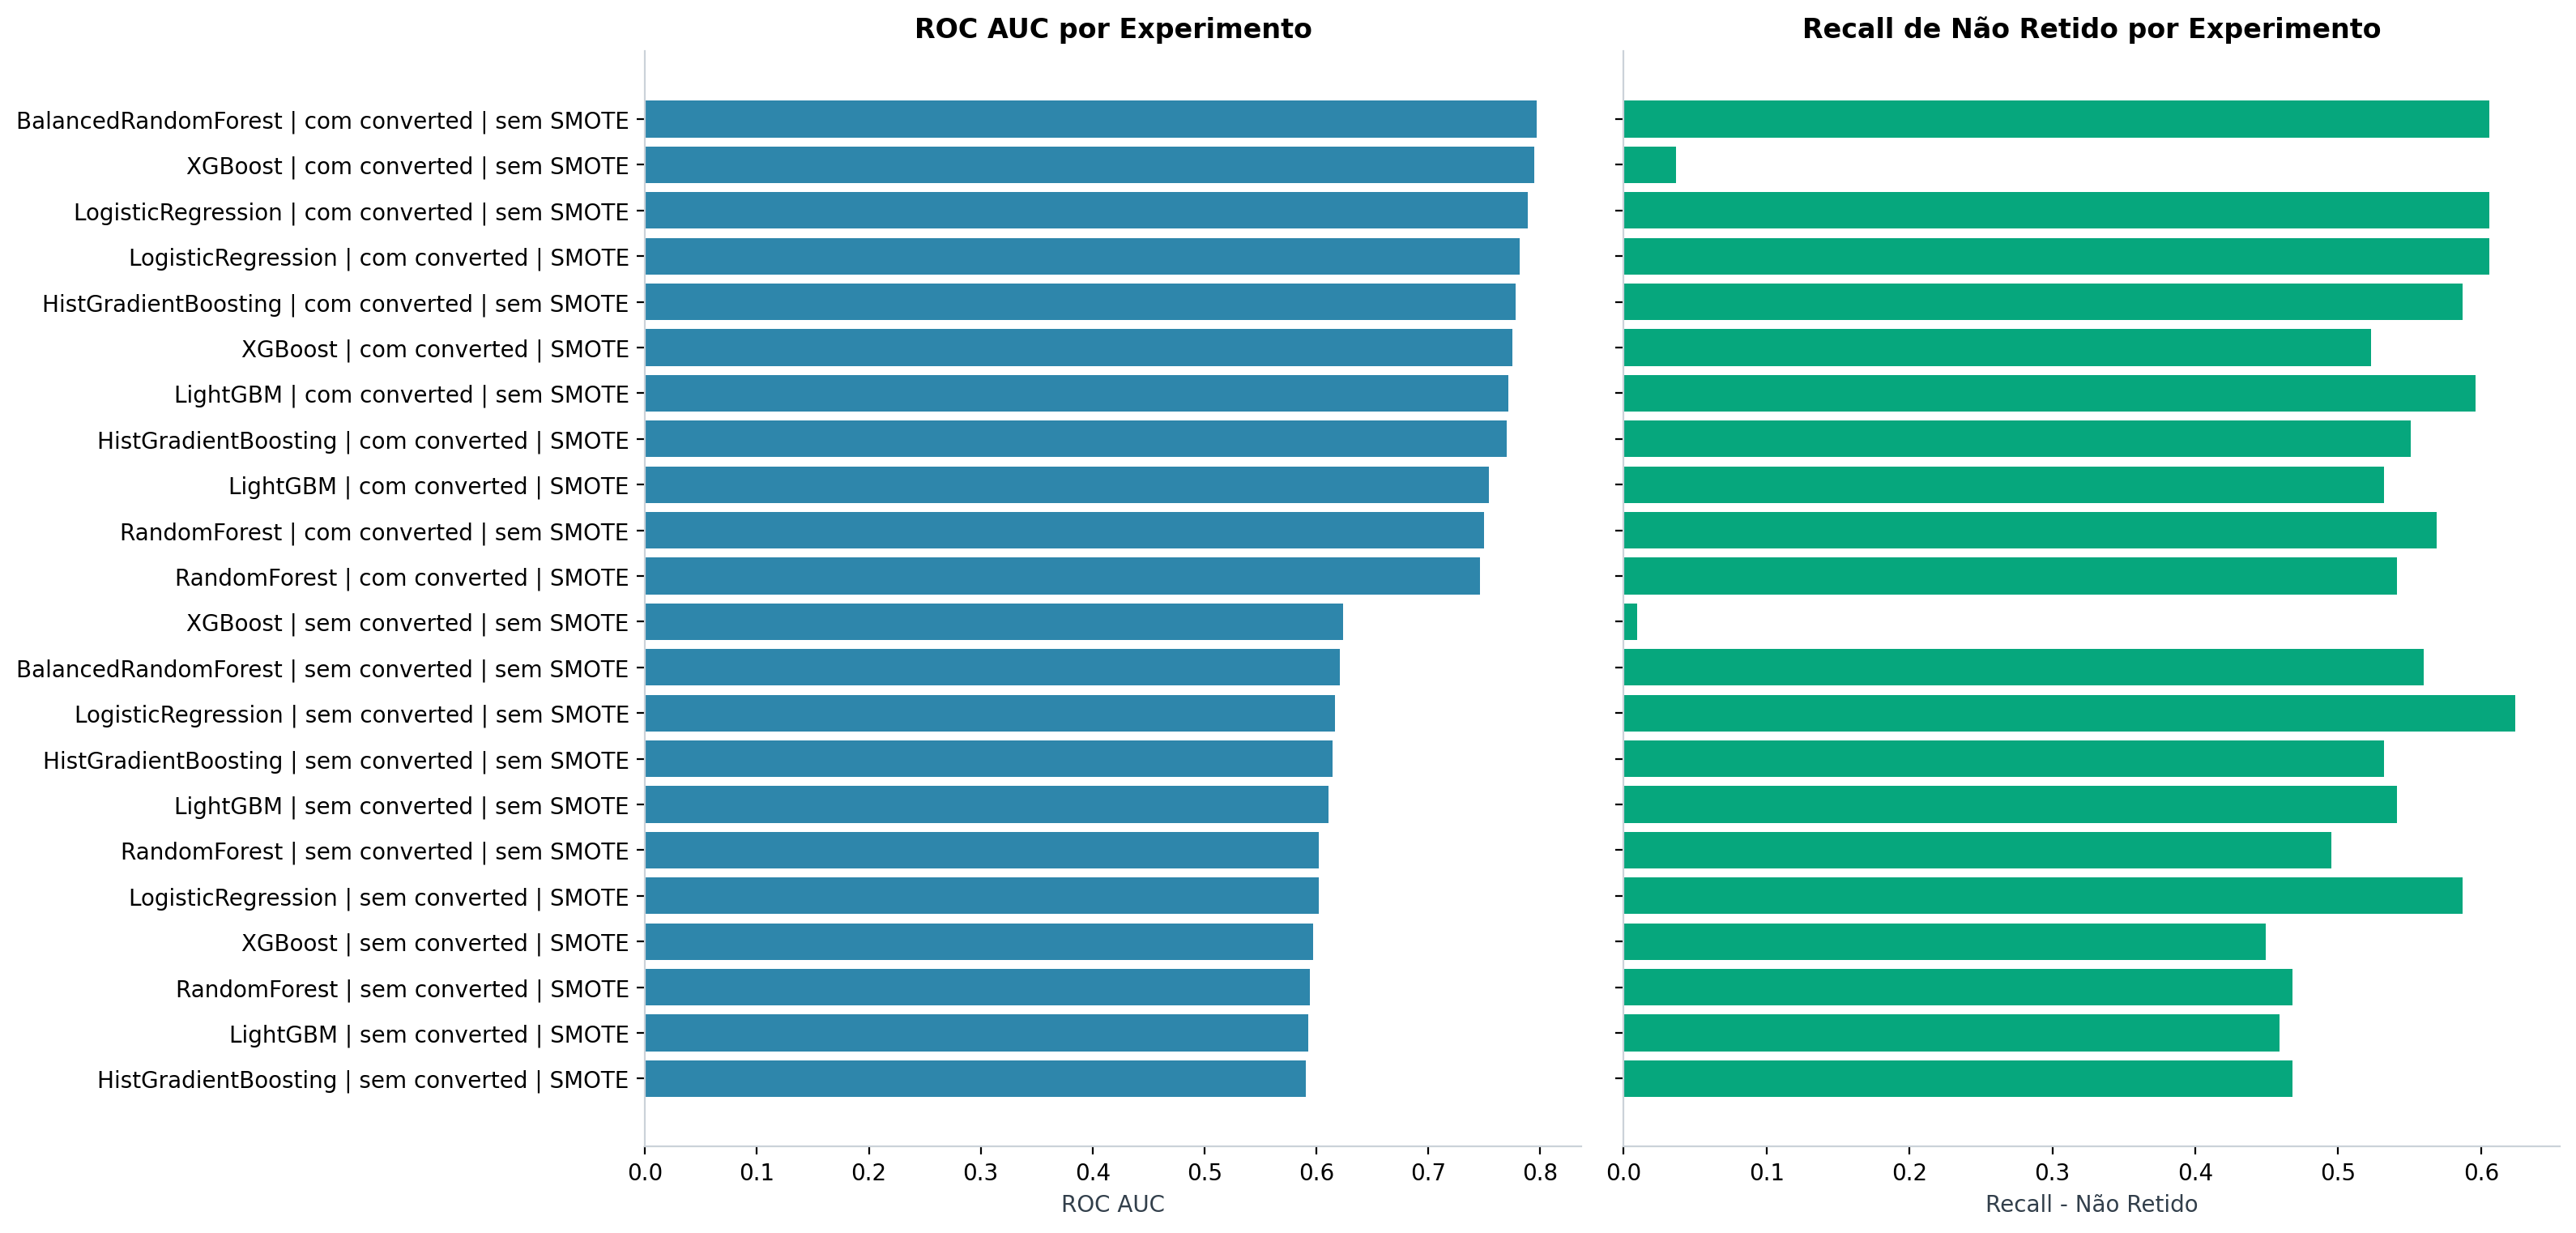


Melhor cenário pela ordenação definida:
estimator_name         BalancedRandomForest
include_converted                      True
resampling_strategy                    None
roc_auc                               0.797
recall_not_retained                  0.6055
f1_not_retained                      0.3091
Name: 0, dtype: object

CONFIGURAÇÃO: Estimador=BalancedRandomForest | Conversão=True | Resampling=None
Distribuição da classe alvo:
retained_flag
Retido        9210
Não Retido     547
Name: count, dtype: int64


,Métrica,Valor
0,Acurácia,0.8489
1,Precisão,0.9737
2,Recall,0.8633
3,F1-Score,0.9152
4,ROC AUC,0.7970
5,Precisão - Não Retido,0.2075
6,Recall - Não Retido,0.6055
7,F1 - Não Retido,0.3091
8,Falsos Positivos,43.0000
9,Falsos Negativos,252.0000


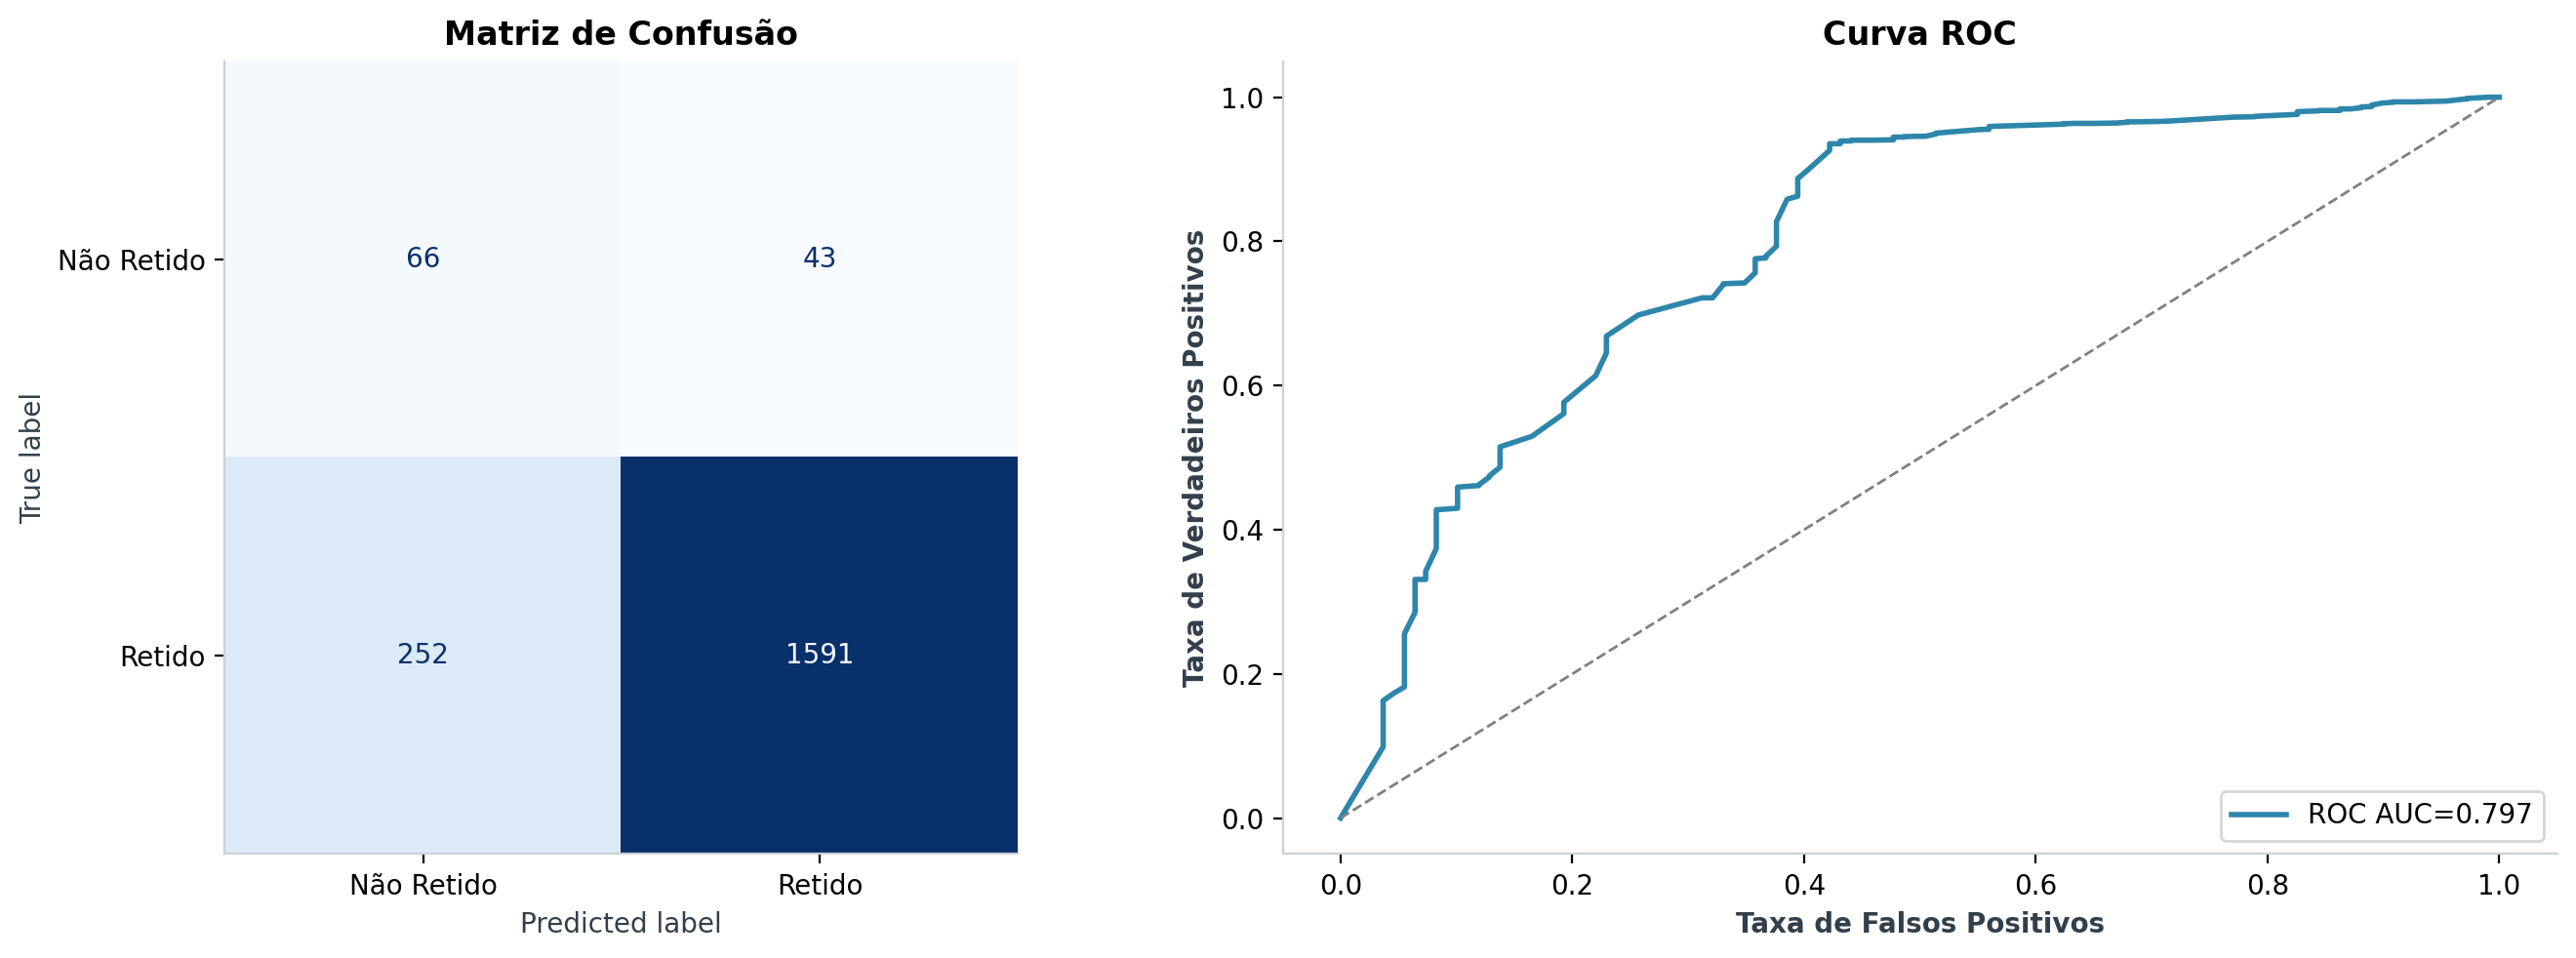

,feature,importance
25,num__converted_flag,0.586567
6,cat__variant_control,0.033490
17,cat__age_group_19-24 years,0.032790
7,cat__variant_personalization,0.032681
2,cat__marketing_channel_House Ads,0.030441
22,cat__age_group_55+ years,0.026794
0,cat__marketing_channel_Email,0.026514
18,cat__age_group_24-30 years,0.024547
1,cat__marketing_channel_Facebook,0.022672
19,cat__age_group_30-36 years,0.021822


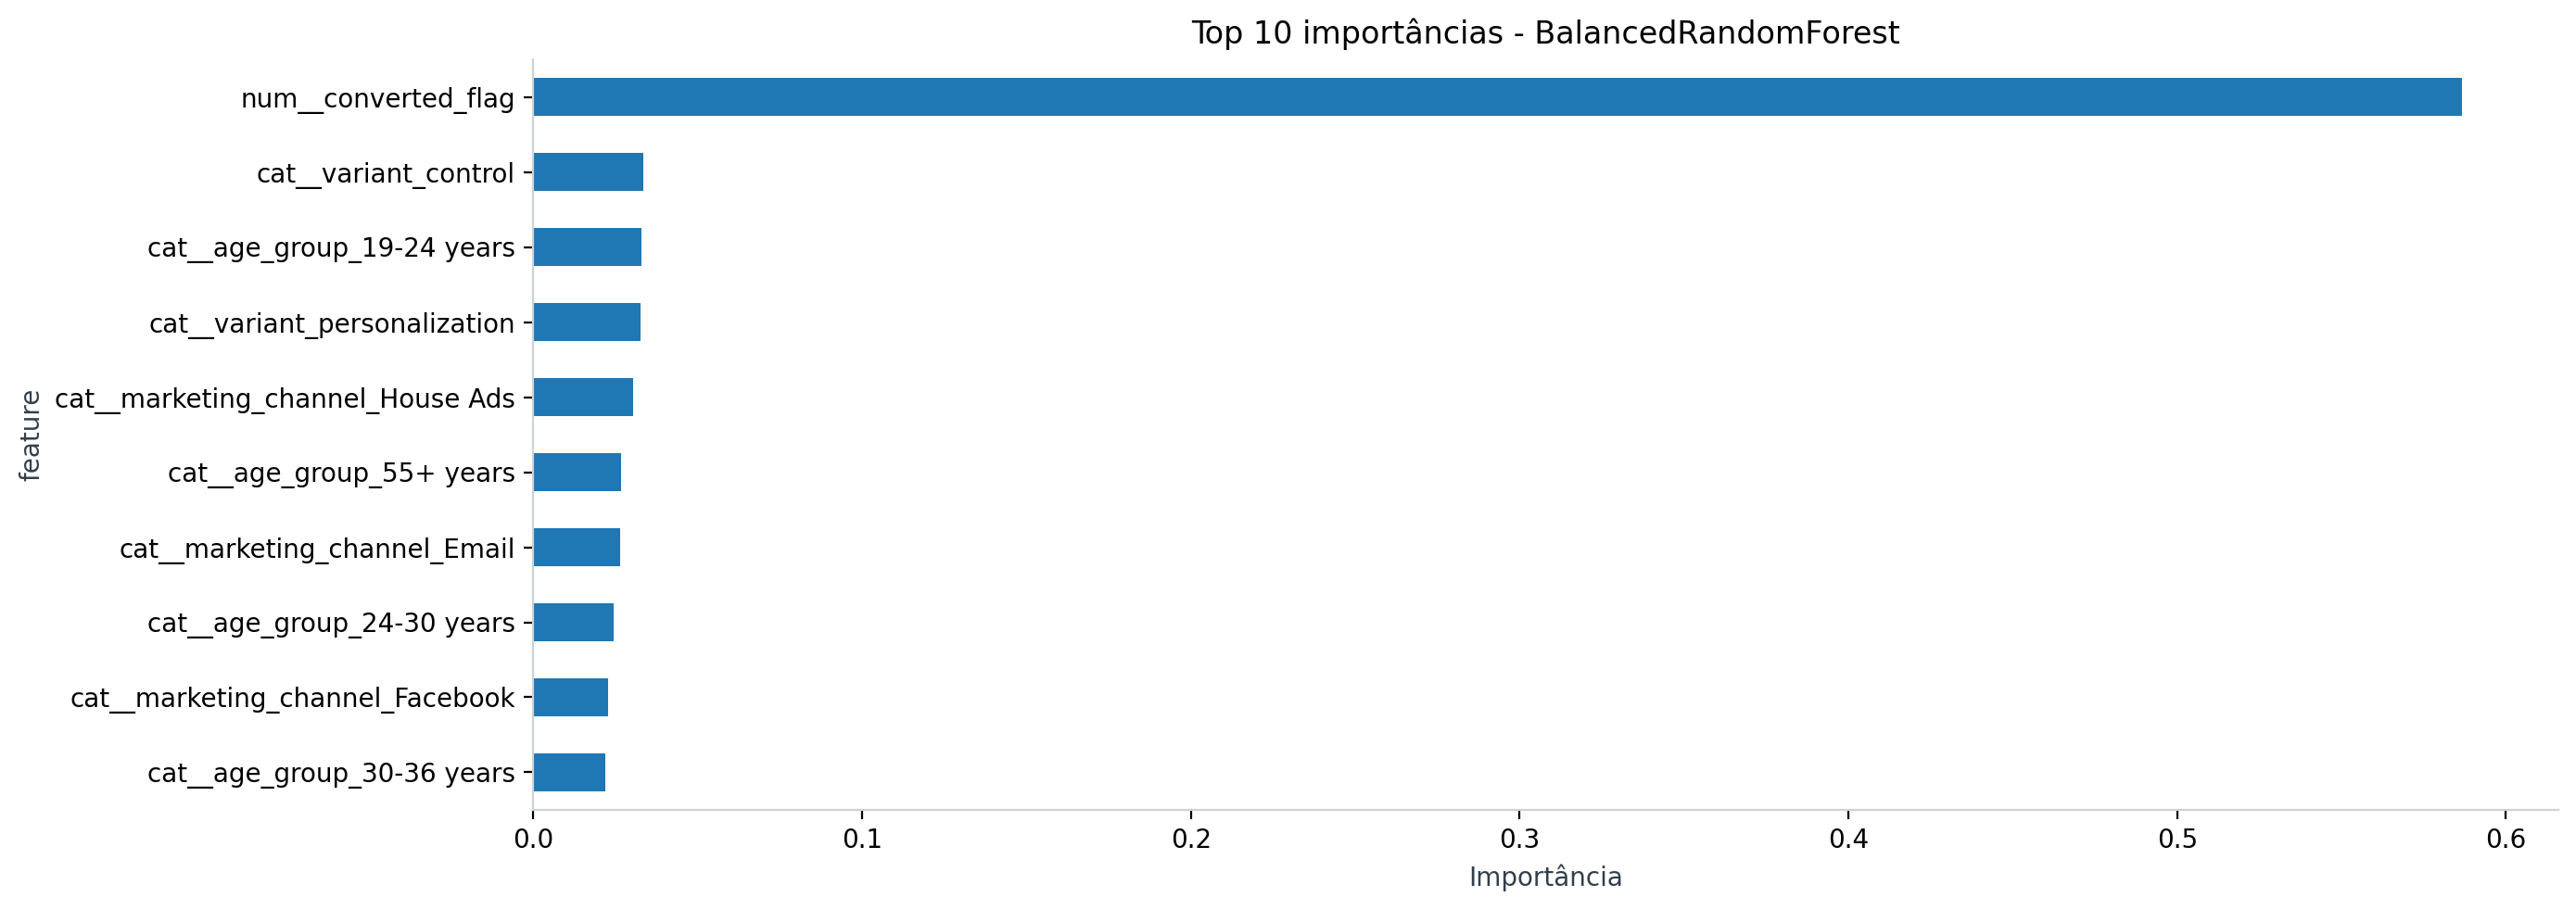

In [58]:
import inspect
import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
)
from typing import Any, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except Exception as exc:
    SMOTE = None
    ImbPipeline = None
    IMBLEARN_IMPORT_ERROR = exc
else:
    IMBLEARN_IMPORT_ERROR = None

OPTIONAL_MODEL_INSTALL_HINT = (
    "mamba install -n Churn-ML -c conda-forge "
    "lightgbm xgboost imbalanced-learn"
)
OPTIONAL_WARNINGS_SHOWN = set()


def warn_once(key: str, message: str) -> None:
    """Emitir avisos opcionais apenas uma vez por execucao."""
    if key not in OPTIONAL_WARNINGS_SHOWN:
        warnings.warn(message, stacklevel=2)
        OPTIONAL_WARNINGS_SHOWN.add(key)


def to_binary_flag(series: pd.Series, default: int = 0) -> pd.Series:
    """Converter valores booleanos, textuais ou numericos em flag 0/1."""
    mapping = {
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0,
        "yes": 1,
        "no": 0,
        "sim": 1,
        "não": 0,
        "nao": 0,
        "y": 1,
        "n": 0,
    }
    normalized = series.astype("string").str.strip().str.lower()
    mapped = normalized.map(mapping)
    numeric = pd.to_numeric(series, errors="coerce")
    result = mapped.fillna(numeric).fillna(default).astype(int)
    return result.clip(lower=0, upper=1)


def prepare_retention_model_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Criar flags usadas pela modelagem sem depender de celulas anteriores."""
    df_model = df.copy().replace({pd.NA: np.nan})

    if "converted_flag" not in df_model.columns and "converted" in df_model.columns:
        df_model["converted_flag"] = to_binary_flag(df_model["converted"])

    if "retained_flag" not in df_model.columns and "is_retained" in df_model.columns:
        df_model["retained_flag"] = to_binary_flag(df_model["is_retained"])

    if "is_correct_lang_flag" not in df_model.columns:
        if "is_correct_lang" in df_model.columns:
            df_model["is_correct_lang_flag"] = to_binary_flag(
                df_model["is_correct_lang"]
            )
        elif {
            "language_displayed",
            "language_preferred",
        }.issubset(df_model.columns):
            df_model["is_correct_lang_flag"] = (
                df_model["language_displayed"].astype(str)
                == df_model["language_preferred"].astype(str)
            ).astype(int)

    if "month" not in df_model.columns and "date_served" in df_model.columns:
        df_model["month"] = pd.to_datetime(
            df_model["date_served"], errors="coerce"
        ).dt.month

    return df_model


def make_one_hot_encoder() -> OneHotEncoder:
    """Criar OneHotEncoder compativel com versoes diferentes do sklearn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def get_retention_estimators(random_state: int = 42) -> dict[str, Any]:
    """Retornar estimadores de retencao disponiveis no ambiente."""
    estimators = {
        "LogisticRegression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),
    }

    hist_params = {"random_state": random_state}
    hist_signature = inspect.signature(HistGradientBoostingClassifier)
    if "class_weight" in hist_signature.parameters:
        hist_params["class_weight"] = "balanced"
    else:
        warn_once(
            "hist_gradient_class_weight",
            "HistGradientBoostingClassifier nesta versao do sklearn nao "
            "suporta class_weight; usando sem balanceamento interno.",
        )
    estimators["HistGradientBoosting"] = HistGradientBoostingClassifier(
        **hist_params
    )

    try:
        from lightgbm import LGBMClassifier
    except Exception as exc:
        warn_once(
            "lightgbm_missing",
            "LightGBM indisponivel; estimador ignorado. "
            f"Detalhe: {exc}. Para instalar: {OPTIONAL_MODEL_INSTALL_HINT}",
        )
    else:
        estimators["LightGBM"] = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            random_state=random_state,
            class_weight="balanced",
            n_jobs=-1,
            verbose=-1,
        )

    try:
        from xgboost import XGBClassifier
    except Exception as exc:
        warn_once(
            "xgboost_missing",
            "XGBoost indisponivel; estimador ignorado. "
            f"Detalhe: {exc}. Para instalar: {OPTIONAL_MODEL_INSTALL_HINT}",
        )
    else:
        # XGBoost usa a classe 1 como positiva. Aqui a classe relevante para
        # acao preventiva e 0, "Nao Retido". Por isso, scale_pos_weight fica
        # desativado para evitar otimizar a classe errada sem calibracao.
        estimators["XGBoost"] = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1,
        )

    try:
        from imblearn.ensemble import BalancedRandomForestClassifier
    except Exception as exc:
        warn_once(
            "balanced_rf_missing",
            "BalancedRandomForestClassifier indisponivel; estimador ignorado. "
            f"Detalhe: {exc}. Para instalar: {OPTIONAL_MODEL_INSTALL_HINT}",
        )
    else:
        estimators["BalancedRandomForest"] = BalancedRandomForestClassifier(
            n_estimators=300,
            random_state=random_state,
            n_jobs=-1,
        )

    return estimators


def get_retention_feature_sets(
    df: pd.DataFrame,
    include_converted: bool,
) -> tuple[list[str], list[str]]:
    """Montar listas dinamicas de features categoricas e numericas."""
    categorical_candidates = [
        "marketing_channel",
        "variant",
        "language_displayed",
        "language_preferred",
        "age_group",
    ]
    numeric_candidates = ["is_correct_lang_flag", "month"]

    if include_converted:
        numeric_candidates.append("converted_flag")

    categorical_features = [
        feature for feature in categorical_candidates if feature in df.columns
    ]
    numeric_features = [
        feature for feature in numeric_candidates if feature in df.columns
    ]
    return categorical_features, numeric_features


def make_retention_preprocessor(
    categorical_features: list[str],
    numeric_features: list[str],
) -> ColumnTransformer:
    """Criar preprocessador comum para todos os estimadores."""
    transformers = []

    if categorical_features:
        categorical_transformer = SklearnPipeline(
            steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="constant", fill_value="Unknown"),
                ),
                ("onehot", make_one_hot_encoder()),
            ]
        )
        transformers.append(("cat", categorical_transformer, categorical_features))

    if numeric_features:
        numeric_transformer = SklearnPipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )
        transformers.append(("num", numeric_transformer, numeric_features))

    return ColumnTransformer(transformers=transformers)


def predict_retention_proba(pipeline: Any, X_test: pd.DataFrame) -> np.ndarray:
    """Obter probabilidade da classe Retido quando disponivel."""
    if hasattr(pipeline, "predict_proba"):
        probabilities = pipeline.predict_proba(X_test)
        return np.asarray(probabilities)[:, 1]

    warn_once(
        "predict_proba_missing",
        "O estimador final nao expoe predict_proba; ROC AUC ficara ausente.",
    )
    return np.full(shape=len(X_test), fill_value=np.nan)


def calculate_retention_metrics(
    y_test: pd.Series,
    y_pred: np.ndarray,
    y_pred_proba: np.ndarray,
) -> dict[str, Any]:
    """Calcular metricas gerais e metricas da classe Nao Retido."""
    y_true = np.asarray(y_test)
    y_hat = np.asarray(y_pred)
    proba = np.asarray(y_pred_proba)

    try:
        roc_auc = roc_auc_score(y_true, proba)
    except ValueError:
        roc_auc = np.nan

    false_positives = int(((y_true == 0) & (y_hat == 1)).sum())
    false_negatives = int(((y_true == 1) & (y_hat == 0)).sum())

    return {
        "accuracy": round(accuracy_score(y_true, y_hat), 4),
        "precision": round(precision_score(y_true, y_hat, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_hat, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_hat, zero_division=0), 4),
        "roc_auc": round(float(roc_auc), 4) if pd.notna(roc_auc) else np.nan,
        "precision_not_retained": round(
            precision_score(y_true, y_hat, pos_label=0, zero_division=0), 4
        ),
        "recall_not_retained": round(
            recall_score(y_true, y_hat, pos_label=0, zero_division=0), 4
        ),
        "f1_not_retained": round(
            f1_score(y_true, y_hat, pos_label=0, zero_division=0), 4
        ),
        "false_positives": false_positives,
        "false_negatives": false_negatives,
    }


def make_metrics_dataframe(metrics: dict[str, Any]) -> pd.DataFrame:
    """Formatar metricas para exibicao no padrao do notebook."""
    metric_labels = [
        ("Acurácia", "accuracy"),
        ("Precisão", "precision"),
        ("Recall", "recall"),
        ("F1-Score", "f1"),
        ("ROC AUC", "roc_auc"),
        ("Precisão - Não Retido", "precision_not_retained"),
        ("Recall - Não Retido", "recall_not_retained"),
        ("F1 - Não Retido", "f1_not_retained"),
        ("Falsos Positivos", "false_positives"),
        ("Falsos Negativos", "false_negatives"),
    ]
    return pd.DataFrame(
        {
            "Métrica": [label for label, _ in metric_labels],
            "Valor": [metrics[key] for _, key in metric_labels],
        }
    )


def get_transformed_feature_names(
    pipeline: Any,
    expected_size: Optional[int] = None,
) -> np.ndarray:
    """Recuperar nomes das features transformadas quando o sklearn expuser."""
    preprocessor = pipeline.named_steps["preprocessor"]
    try:
        feature_names = preprocessor.get_feature_names_out()
    except Exception:
        feature_names = np.array([], dtype=object)

    if expected_size is not None and len(feature_names) != expected_size:
        return np.array([f"feature_{idx}" for idx in range(expected_size)])
    return feature_names


def plot_retention_diagnostics(
    y_test: pd.Series,
    y_pred: np.ndarray,
    y_pred_proba: np.ndarray,
    roc_auc: float,
) -> None:
    """Exibir matriz de confusao e curva ROC."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(
        cm,
        display_labels=["Não Retido", "Retido"],
    ).plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
    axes[0].set_title("Matriz de Confusão", fontweight="bold")

    if pd.notna(roc_auc):
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        axes[1].plot(
            fpr,
            tpr,
            color="#2E86AB",
            lw=2,
            label=f"ROC AUC={roc_auc:.3f}",
        )
    else:
        axes[1].text(0.5, 0.5, "ROC AUC indisponível", ha="center")

    axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
    axes[1].set_xlabel("Taxa de Falsos Positivos", fontweight="bold")
    axes[1].set_ylabel("Taxa de Verdadeiros Positivos", fontweight="bold")
    axes[1].set_title("Curva ROC", fontweight="bold")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()
    plt.close()


def plot_model_signal_summary(
    pipeline: Any,
    estimator_name: str,
    top_n: int = 10,
) -> None:
    """Exibir importancias ou coeficientes quando o estimador permitir."""
    classifier = pipeline.named_steps["classifier"]

    if hasattr(classifier, "feature_importances_"):
        values = np.asarray(classifier.feature_importances_)
        feature_names = get_transformed_feature_names(pipeline, len(values))
        signal_df = pd.DataFrame(
            {"feature": feature_names, "importance": values}
        ).sort_values("importance", ascending=False)
        top_features = signal_df.head(top_n).sort_values("importance")

        display(signal_df.head(top_n))
        top_features.plot.barh(x="feature", y="importance", legend=False)
        plt.title(f"Top {top_n} importâncias - {estimator_name}")
        plt.xlabel("Importância")
        plt.tight_layout()
        plt.show()
        plt.close()
        return

    if isinstance(classifier, LogisticRegression) and hasattr(classifier, "coef_"):
        coefficients = np.asarray(classifier.coef_).ravel()
        feature_names = get_transformed_feature_names(pipeline, len(coefficients))
        coef_df = pd.DataFrame(
            {
                "feature": feature_names,
                "coeficiente": coefficients,
                "coeficiente_abs": np.abs(coefficients),
            }
        ).sort_values("coeficiente_abs", ascending=False)
        top_coefficients = coef_df.head(top_n).sort_values("coeficiente_abs")

        display(coef_df.head(top_n))
        top_coefficients.plot.barh(x="feature", y="coeficiente_abs", legend=False)
        plt.title(f"Top {top_n} coeficientes absolutos - {estimator_name}")
        plt.xlabel("Coeficiente absoluto")
        plt.tight_layout()
        plt.show()
        plt.close()
        return

    print(f"{estimator_name} nao expoe importancias ou coeficientes diretos.")


def build_retention_model(
    df: pd.DataFrame,
    test_size: float = 0.2,
    include_converted: bool = True,
    resampling_strategy: Optional[str] = None,
    estimator_name: str = "RandomForest",
    random_state: int = 42,
    show_plots: bool = True,
    display_metrics: bool = True,
    verbose: bool = True,
) -> Tuple[Any, pd.DataFrame, list, list, pd.Series, np.ndarray, np.ndarray, pd.DataFrame]:
    """Treinar modelo experimental de retencao para um cenario definido."""
    if resampling_strategy not in {None, "smote"}:
        raise ValueError("resampling_strategy deve ser None ou 'smote'.")

    df_model = prepare_retention_model_frame(df)
    if "retained_flag" not in df_model.columns:
        raise ValueError("A coluna retained_flag ou is_retained e obrigatoria.")

    categorical_features, numeric_features = get_retention_feature_sets(
        df_model,
        include_converted=include_converted,
    )
    feature_columns = categorical_features + numeric_features
    if not feature_columns:
        raise ValueError("Nenhuma feature disponivel para modelagem de retencao.")

    X = df_model[feature_columns].copy()
    y = to_binary_flag(df_model["retained_flag"])
    if y.nunique() < 2:
        raise ValueError("A variavel alvo retained_flag precisa ter as classes 0 e 1.")

    estimators = get_retention_estimators(random_state=random_state)
    if estimator_name not in estimators:
        available = ", ".join(estimators.keys())
        raise ValueError(
            f"Estimador '{estimator_name}' indisponivel. Disponiveis: {available}."
        )

    if verbose:
        print("\n" + "=" * 80)
        print(
            "CONFIGURAÇÃO: "
            f"Estimador={estimator_name} | "
            f"Conversão={include_converted} | "
            f"Resampling={resampling_strategy}"
        )
        print("Distribuição da classe alvo:")
        print(y.value_counts().rename(index={0: "Não Retido", 1: "Retido"}))
        print("=" * 80)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    preprocessor = make_retention_preprocessor(
        categorical_features=categorical_features,
        numeric_features=numeric_features,
    )
    steps = [("preprocessor", preprocessor)]

    effective_resampling = resampling_strategy
    if resampling_strategy == "smote":
        if SMOTE is None or ImbPipeline is None:
            warn_once(
                "smote_missing",
                "SMOTE indisponivel; cenario executado sem resampling. "
                f"Para instalar: {OPTIONAL_MODEL_INSTALL_HINT}",
            )
            effective_resampling = None
        else:
            minority_count = int(y_train.value_counts().min())
            if minority_count < 2:
                warn_once(
                    "smote_too_few_samples",
                    "SMOTE ignorado porque a classe minoritaria tem menos "
                    "de 2 amostras no treino.",
                )
                effective_resampling = None
            else:
                k_neighbors = min(5, minority_count - 1)
                # SMOTE esta sendo aplicado no espaco numerico apos
                # OneHotEncoder.
                steps.append(
                    (
                        "resampler",
                        SMOTE(random_state=random_state, k_neighbors=k_neighbors),
                    )
                )

    steps.append(("classifier", estimators[estimator_name]))
    pipeline_class = ImbPipeline if effective_resampling == "smote" else SklearnPipeline
    pipeline = pipeline_class(steps=steps)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_pred_proba = predict_retention_proba(pipeline, X_test)
    metrics = calculate_retention_metrics(y_test, y_pred, y_pred_proba)
    metrics_df = make_metrics_dataframe(metrics)

    if display_metrics:
        display(metrics_df)

    if show_plots:
        plot_retention_diagnostics(
            y_test=y_test,
            y_pred=y_pred,
            y_pred_proba=y_pred_proba,
            roc_auc=metrics["roc_auc"],
        )
        plot_model_signal_summary(pipeline, estimator_name=estimator_name)

    return (
        pipeline,
        metrics_df,
        categorical_features,
        numeric_features,
        y_test,
        y_pred,
        y_pred_proba,
        X_test,
    )


def make_experiment_label(
    estimator_name: str,
    include_converted: bool,
    resampling_strategy: Optional[str],
) -> str:
    """Criar rotulo legivel para tabelas e graficos."""
    converted_label = "com converted" if include_converted else "sem converted"
    resampling_label = "SMOTE" if resampling_strategy == "smote" else "sem SMOTE"
    return f"{estimator_name} | {converted_label} | {resampling_label}"


def run_retention_experiments(
    df_clean: pd.DataFrame,
    random_state: int = 42,
    test_size: float = 0.2,
) -> pd.DataFrame:
    """Rodar matriz experimental de estimadores, features e balanceamento."""
    available_estimators = get_retention_estimators(random_state=random_state)
    preferred_order = [
        "LogisticRegression",
        "RandomForest",
        "HistGradientBoosting",
        "LightGBM",
        "XGBoost",
        "BalancedRandomForest",
    ]
    estimator_names = [
        name for name in preferred_order if name in available_estimators
    ]

    smote_available = SMOTE is not None and ImbPipeline is not None
    if not smote_available:
        warn_once(
            "smote_matrix_missing",
            "SMOTE indisponivel; experimentos com resampling='smote' "
            f"serao pulados. Para instalar: {OPTIONAL_MODEL_INSTALL_HINT}",
        )

    rows = []
    include_options = [True, False]

    for estimator_name in estimator_names:
        if estimator_name == "BalancedRandomForest":
            resampling_options = [None]
        else:
            resampling_options = [None, "smote"] if smote_available else [None]

        for include_converted in include_options:
            for resampling_strategy in resampling_options:
                if (
                    estimator_name == "LogisticRegression"
                    and resampling_strategy == "smote"
                ):
                    warn_once(
                        "logistic_smote_note",
                        "LogisticRegression ja usa class_weight='balanced'; "
                        "o cenario com SMOTE avalia um balanceamento adicional.",
                    )

                print(
                    "Executando experimento: "
                    f"{make_experiment_label(estimator_name, include_converted, resampling_strategy)}"
                )

                try:
                    result = build_retention_model(
                        df_clean,
                        test_size=test_size,
                        include_converted=include_converted,
                        resampling_strategy=resampling_strategy,
                        estimator_name=estimator_name,
                        random_state=random_state,
                        show_plots=False,
                        display_metrics=False,
                        verbose=False,
                    )
                except Exception as exc:
                    warn_once(
                        f"experiment_failed_{estimator_name}_{include_converted}_{resampling_strategy}",
                        "Experimento ignorado por erro: "
                        f"{estimator_name}, include_converted={include_converted}, "
                        f"resampling_strategy={resampling_strategy}. Detalhe: {exc}",
                    )
                    continue

                _, _, _, _, y_test, y_pred, y_pred_proba, _ = result
                metrics = calculate_retention_metrics(y_test, y_pred, y_pred_proba)
                rows.append(
                    {
                        "experiment": make_experiment_label(
                            estimator_name,
                            include_converted,
                            resampling_strategy,
                        ),
                        "estimator_name": estimator_name,
                        "include_converted": include_converted,
                        "resampling_strategy": resampling_strategy or "None",
                        "accuracy": metrics["accuracy"],
                        "precision": metrics["precision"],
                        "recall": metrics["recall"],
                        "f1": metrics["f1"],
                        "roc_auc": metrics["roc_auc"],
                        "precision_not_retained": metrics[
                            "precision_not_retained"
                        ],
                        "recall_not_retained": metrics["recall_not_retained"],
                        "f1_not_retained": metrics["f1_not_retained"],
                        "false_positives": metrics["false_positives"],
                        "false_negatives": metrics["false_negatives"],
                    }
                )

    results_df = pd.DataFrame(rows)
    if results_df.empty:
        return results_df

    return results_df.sort_values(
        ["roc_auc", "recall_not_retained", "f1_not_retained"],
        ascending=[False, False, False],
    ).reset_index(drop=True)


def plot_retention_experiment_comparison(results_df: pd.DataFrame) -> None:
    """Comparar ROC AUC e recall da classe Nao Retido por experimento."""
    if results_df.empty:
        print("Nenhum experimento disponivel para visualizacao.")
        return

    plot_df = results_df.sort_values(
        ["roc_auc", "recall_not_retained", "f1_not_retained"],
        ascending=True,
    )
    fig_height = max(6, 0.35 * len(plot_df))
    fig, axes = plt.subplots(1, 2, figsize=(16, fig_height), sharey=True)

    axes[0].barh(plot_df["experiment"], plot_df["roc_auc"], color="#2E86AB")
    axes[0].set_title("ROC AUC por Experimento", fontweight="bold")
    axes[0].set_xlabel("ROC AUC")

    axes[1].barh(
        plot_df["experiment"],
        plot_df["recall_not_retained"],
        color="#06A77D",
    )
    axes[1].set_title("Recall de Não Retido por Experimento", fontweight="bold")
    axes[1].set_xlabel("Recall - Não Retido")

    plt.tight_layout()
    plt.show()
    plt.close()


experiment_results_df = run_retention_experiments(df_clean)
display(experiment_results_df)
plot_retention_experiment_comparison(experiment_results_df)

if experiment_results_df.empty:
    raise RuntimeError("Nenhum experimento de retenção foi executado com sucesso.")

best_experiment = experiment_results_df.iloc[0]
best_resampling_strategy = best_experiment["resampling_strategy"]
if best_resampling_strategy == "None" or pd.isna(best_resampling_strategy):
    best_resampling_strategy = None

print("\nMelhor cenário pela ordenação definida:")
print(best_experiment[[
    "estimator_name",
    "include_converted",
    "resampling_strategy",
    "roc_auc",
    "recall_not_retained",
    "f1_not_retained",
]])

df_clean = prepare_retention_model_frame(df_clean)
(
    pipeline,
    model_metrics,
    cat_features,
    num_features,
    y_test,
    y_pred,
    y_pred_proba,
    X_test,
) = build_retention_model(
    df_clean,
    include_converted=bool(best_experiment["include_converted"]),
    resampling_strategy=best_resampling_strategy,
    estimator_name=str(best_experiment["estimator_name"]),
    show_plots=True,
    display_metrics=True,
    verbose=True,
)

retention_model_artifacts = {
    "pipeline": pipeline,
    "model_metrics": model_metrics,
    "cat_features": cat_features,
    "num_features": num_features,
    "y_test": y_test,
    "y_pred": y_pred,
    "y_pred_proba": y_pred_proba,
    "X_test": X_test,
    "best_experiment": best_experiment,
}

In [59]:
from IPython.display import Markdown

best = experiment_results_df.iloc[0]
display(Markdown(f"""
> **Modelo selecionado:** {best['estimator_name']} | {'com' if best['include_converted'] else 'sem'} converted_flag | {best['resampling_strategy'] or 'sem'} SMOTE
>
> **Métricas:** ROC AUC = {best['roc_auc']:.3f} | Recall Não Retido = {best['recall_not_retained']:.3f} | F1 Não Retido = {best['f1_not_retained']:.3f}
>
> **Implicação operacional:** O modelo identifica {best['recall_not_retained']:.0%} dos usuários
> que não permaneceriam. Isso permite antecipar campanhas preventivas para esse grupo
> antes do cancelamento, com precisão de {best['precision_not_retained']:.0%} (proporção de alertas corretos).
>
> **Limitação:** Predição não é causalidade. Validar com experimento A/B dedicado
> a retenção antes de escalar campanhas preventivas.
"""))



> **Modelo selecionado:** BalancedRandomForest | com converted_flag | None SMOTE
>
> **Métricas:** ROC AUC = 0.797 | Recall Não Retido = 0.606 | F1 Não Retido = 0.309
>
> **Implicação operacional:** O modelo identifica 61% dos usuários
> que não permaneceriam. Isso permite antecipar campanhas preventivas para esse grupo
> antes do cancelamento, com precisão de 21% (proporção de alertas corretos).
>
> **Limitação:** Predição não é causalidade. Validar com experimento A/B dedicado
> a retenção antes de escalar campanhas preventivas.


<span style="color:steelblue; text-align: left">

## Analise de erros do modelo de retenção

</span>

Matriz de confusão, falsos positivos/negativos e suas implicações operacionais para campanhas dirigidas ao segmento de risco.

In [60]:
def analyze_retention_errors(
    pipeline: Any,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    y_pred: np.ndarray,
    y_pred_proba: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Analisar falsos positivos e falsos negativos do modelo de retenção."""
    _ = pipeline
    errors_df = X_test.copy().reset_index(drop=True)
    errors_df.insert(0, "original_index", X_test.index.to_numpy())
    errors_df["y_true"] = np.asarray(y_test)
    errors_df["y_pred"] = np.asarray(y_pred)
    errors_df["prob_retention"] = np.asarray(y_pred_proba)

    false_positives = errors_df[
        (errors_df["y_true"] == 0) & (errors_df["y_pred"] == 1)
    ].copy()
    false_negatives = errors_df[
        (errors_df["y_true"] == 1) & (errors_df["y_pred"] == 0)
    ].copy()

    print("Resumo dos erros de classificação")
    print(f"Falsos positivos: {len(false_positives)}")
    print(f"Falsos negativos: {len(false_negatives)}")

    analysis_columns = [
        "marketing_channel",
        "variant",
        "age_group",
        "language_displayed",
        "language_preferred",
        "is_correct_lang_flag",
    ]

    if false_positives.empty:
        print("Não há falsos positivos para analisar no conjunto de teste.")
        return errors_df, false_positives, false_negatives

    print("\nDistribuição dos falsos positivos por variável")
    for column in analysis_columns:
        if column not in false_positives.columns:
            continue

        values = false_positives[column].astype("object")
        values = values.where(values.notna(), "Missing")
        frequency_table = (
            values.value_counts(dropna=False)
            .rename_axis(column)
            .reset_index(name="quantidade")
        )
        frequency_table["percentual"] = (
            frequency_table["quantidade"] / len(false_positives) * 100
        ).round(2)

        print(f"\n{column}")
        display(frequency_table)

    return errors_df, false_positives, false_negatives


(
    retention_errors_df,
    retention_false_positives_df,
    retention_false_negatives_df,
) = analyze_retention_errors(
    pipeline=pipeline,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred,
    y_pred_proba=y_pred_proba,
)

Resumo dos erros de classificação
Falsos positivos: 43
Falsos negativos: 252

Distribuição dos falsos positivos por variável

marketing_channel


,marketing_channel,quantidade,percentual
0,House Ads,25,58.14
1,Facebook,8,18.60
2,Instagram,4,9.30
3,Push,3,6.98
4,Email,3,6.98



variant


,variant,quantidade,percentual
0,control,30,69.77
1,personalization,13,30.23



age_group


...

,language_displayed,quantidade,percentual
0,English,38,88.37
1,Spanish,5,11.63



language_preferred


,language_preferred,quantidade,percentual
0,English,38,88.37
1,Spanish,5,11.63



is_correct_lang_flag


,is_correct_lang_flag,quantidade,percentual
0,1,43,100.0


In [61]:
from IPython.display import Markdown

fp_count = int(len(retention_false_positives_df))
converted_total = int((df_clean["converted_flag"] == 1).sum())
fp_pct = (fp_count / max(converted_total, 1)) * 100
fp_savings = fp_count * 0.20 * DEFAULT_COST

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insights da Análise de Erros

</span>

>**O que mostram:** O modelo gerou {fp_count:,} falsos positivos ({fp_pct:.1f}% dos convertidos). Estes usuários foram preditos como retidos mas não retiveram.
>**Por que importa:** Cada falso positivo representa budget desperdiçado em usuário que não se beneficia da campanha. Reduzir FP melhora ROI de retenção.
>**Ação recomendada:** Análise granular: quais canais, segmentos ou períodos geram mais FP? Ajustar threshold do modelo ou aprimorar features.
>**Impacto:** Reduzir FP em 20% economiza R$ {fp_savings:,.0f} sem perder capacidade preditiva no recall.
"""))



<span style="color:steelblue; text-align: left">

### Insights da Análise de Erros

</span>

>**O que mostram:** O modelo gerou 43 falsos positivos (4.1% dos convertidos). Estes usuários foram preditos como retidos mas não retiveram.
>**Por que importa:** Cada falso positivo representa budget desperdiçado em usuário que não se beneficia da campanha. Reduzir FP melhora ROI de retenção.
>**Ação recomendada:** Análise granular: quais canais, segmentos ou períodos geram mais FP? Ajustar threshold do modelo ou aprimorar features.
>**Impacto:** Reduzir FP em 20% economiza R$ 10 sem perder capacidade preditiva no recall.


<span style="color:steelblue; text-align: left">

## Diagnóstico de viés nos falsos positivos

</span>

Nesta seção são analisados os erros do modelo de retenção, com foco nos falsos positivos.

Falsos positivos são casos em que o modelo previu que o usuário seria retido (`y_pred = 1`), mas o resultado real indicou não retenção (`y_true = 0`). Em termos de negócio, esse grupo é especialmente relevante porque representa usuários que pareciam ter sinais positivos de permanência, mas abandonaram a jornada.

A análise desses erros permite investigar padrões associados a:
- canal de marketing;
- variante da campanha;
- faixa etária;
- idioma exibido;
- compatibilidade entre idioma exibido e idioma preferido.

O objetivo não é afirmar causalidade, mas identificar indícios de campanhas, públicos ou canais onde o modelo pode estar superestimando a probabilidade de retenção.


In [62]:
def analyze_false_positive_bias(
    full_df: pd.DataFrame,
    false_positive_df: pd.DataFrame,
    columns: list[str],
) -> dict[str, pd.DataFrame]:
    """Compare falsos positivos com a composição da base total.

    A função calcula, para cada variavel categórica informada, a distribuicao
    percentual da base completa e a distribuicao percentual do subconjunto de
    falsos positivos. A diferenca em pontos percentuais (`diff_pp`) indica se
    uma categoria aparece nos falsos positivos em proporção maior ou menor do
    que sua presença natural no dataset.

    Parameters
    ----------
    full_df : pd.DataFrame
        Dataset completo usado como referencia da distribuicao natural dos
        grupos.
    false_positive_df : pd.DataFrame
        DataFrame contendo apenas os falsos positivos do modelo de retenção.
    columns : list[str]
        Variaveis categóricas que serão comparadas entre a base total e os
        falsos positivos.

    Returns
    -------
    dict[str, pd.DataFrame]
        Dicionario em que cada chave e o nome da variavel analisada e cada
        valor e um DataFrame com categoria, quantidades, percentuais,
        diferenca em pontos percentuais e interpretacao textual.

    Notes
    -----
    Os DataFrames originais nao sao modificados. Valores ausentes sao tratados
    como a categoria textual "Missing" para manter a comparabilidade das
    distribuicoes.
    """
    full_data = full_df.copy(deep=False)
    false_positive_data = false_positive_df.copy(deep=False)
    results: dict[str, pd.DataFrame] = {}

    if not columns:
        print("Nenhuma coluna informada para analise de vies.")
        return results

    missing_columns = [
        column
        for column in columns
        if column not in full_data.columns
        or column not in false_positive_data.columns
    ]
    if missing_columns:
        print(f"Colunas ignoradas por ausencia nos dados: {missing_columns}")

    valid_columns = [
        column
        for column in columns
        if column in full_data.columns
        and column in false_positive_data.columns
    ]
    if not valid_columns:
        print("Nenhuma coluna valida disponível para analise.")
        return results

    output_columns = [
        "categoria",
        "qtd_base",
        "perc_base",
        "qtd_false_positive",
        "perc_false_positive",
        "diff_pp",
        "interpretacao",
    ]

    base_total = len(full_data)
    false_positive_total = len(false_positive_data)
    base_denominator = np.nan if base_total == 0 else base_total
    false_positive_denominator = (
        np.nan if false_positive_total == 0 else false_positive_total
    )

    print("Analise de super-representação nos falsos positivos")
    print(f"Base total: {base_total} registros")
    print(f"Falsos positivos: {false_positive_total} registros")

    for column in valid_columns:
        base_values = full_data[column].astype("object")
        base_values = base_values.where(base_values.notna(), "Missing")
        false_positive_values = false_positive_data[column].astype("object")
        false_positive_values = false_positive_values.where(
            false_positive_values.notna(),
            "Missing",
        )

        if base_values.empty and false_positive_values.empty:
            empty_df = pd.DataFrame(columns=output_columns)
            results[column] = empty_df
            print(f"\n{column}: sem registros para comparar.")
            display(empty_df)
            continue

        base_counts = base_values.value_counts(dropna=False).rename(
            "qtd_base"
        )
        false_positive_counts = false_positive_values.value_counts(
            dropna=False
        ).rename("qtd_false_positive")

        comparison_df = (
            pd.concat([base_counts, false_positive_counts], axis=1)
            .fillna(0)
            .rename_axis("categoria")
            .reset_index()
        )
        comparison_df[["qtd_base", "qtd_false_positive"]] = comparison_df[
            ["qtd_base", "qtd_false_positive"]
        ].astype(int)
        comparison_df["perc_base"] = (
            comparison_df["qtd_base"] / base_denominator * 100
        ).round(2).fillna(0)
        comparison_df["perc_false_positive"] = (
            comparison_df["qtd_false_positive"]
            / false_positive_denominator
            * 100
        ).round(2).fillna(0)
        comparison_df["diff_pp"] = (
            comparison_df["perc_false_positive"]
            - comparison_df["perc_base"]
        ).round(2)
        comparison_df["interpretacao"] = np.select(
            [
                comparison_df["diff_pp"] >= 10,
                comparison_df["diff_pp"] <= -10,
            ],
            [
                "Super-representado nos falsos positivos",
                "Sub-representado nos falsos positivos",
            ],
            default="Distribuicao proporcional",
        )
        comparison_df = comparison_df.sort_values(
            "diff_pp",
            ascending=False,
        ).reset_index(drop=True)
        comparison_df = comparison_df[output_columns]

        results[column] = comparison_df

        print(f"\nComparacao percentual para {column}")
        display(comparison_df)

        plot_df = comparison_df.sort_values("diff_pp", ascending=True)
        positions = np.arange(len(plot_df))
        bar_height = 0.38
        fig_height = max(4, len(plot_df) * 0.45)

        fig, ax = plt.subplots(figsize=(10, fig_height))
        ax.barh(
            positions - bar_height / 2,
            plot_df["perc_base"],
            height=bar_height,
            color="#2E86AB",
            label="Base total",
        )
        ax.barh(
            positions + bar_height / 2,
            plot_df["perc_false_positive"],
            height=bar_height,
            color="#D62828",
            label="Falsos positivos",
        )
        ax.set_yticks(positions)
        ax.set_yticklabels(plot_df["categoria"].astype(str))
        ax.set_xlabel("Percentual (%)", fontweight="bold")
        ax.set_title(
            f"Base total vs falsos positivos: {column}",
            fontweight="bold",
        )
        ax.grid(axis="x", alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()
        plt.close()

        top_row = comparison_df.iloc[0]
        category = top_row["categoria"]
        false_positive_pct = top_row["perc_false_positive"]
        base_pct = top_row["perc_base"]
        diff_pp = top_row["diff_pp"]

        if diff_pp >= 10:
            text = (
                f"{category} representa {false_positive_pct:.1f}% dos "
                f"falsos positivos, mas apenas {base_pct:.1f}% da base, "
                f"indicando possível concentração de erros em {column}."
            )
            display(Markdown(text))
        else:
            text = (
                f"Maior diferença em {column}: {category} representa "
                f"{false_positive_pct:.1f}% dos falsos positivos e "
                f"{base_pct:.1f}% da base ({diff_pp:.1f} p.p.), "
                "sem super-representação relevante pelo limiar de 10 p.p."
            )
            display(Markdown(text))

    return results


Analise de super-representação nos falsos positivos
Base total: 9757 registros
Falsos positivos: 43 registros

Comparacao percentual para marketing_channel


,categoria,qtd_base,perc_base,qtd_false_positive,perc_false_positive,diff_pp,interpretacao
0,House Ads,4574,46.88,25,58.14,11.26,Super-representado nos falsos positivos
1,Email,554,5.68,3,6.98,1.30,Distribuicao proporcional
2,Facebook,1814,18.59,8,18.60,0.01,Distribuicao proporcional
3,Missing,15,0.15,0,0.00,-0.15,Distribuicao proporcional
4,Push,976,10.00,3,6.98,-3.02,Distribuicao proporcional
5,Instagram,1824,18.69,4,9.30,-9.39,Distribuicao proporcional


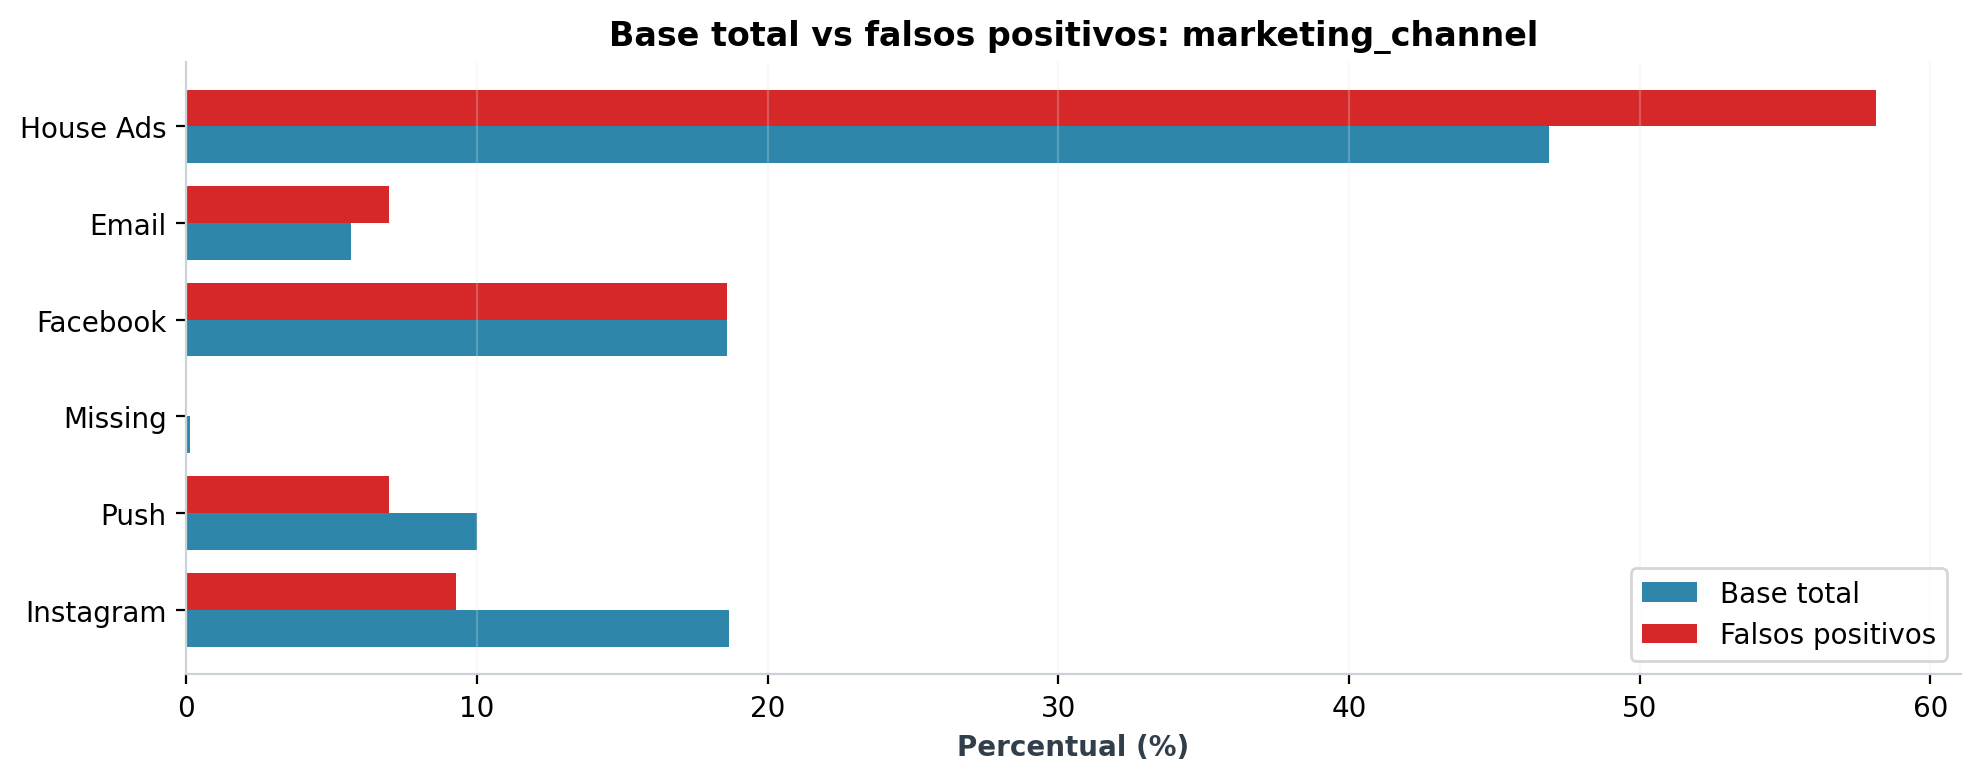

House Ads representa 58.1% dos falsos positivos, mas apenas 46.9% da base, indicando possível concentração de erros em marketing_channel.


Comparacao percentual para variant


,categoria,qtd_base,perc_base,qtd_false_positive,perc_false_positive,diff_pp,interpretacao
0,control,4932,50.55,30,69.77,19.22,Super-representado nos falsos positivos
1,personalization,4825,49.45,13,30.23,-19.22,Sub-representado nos falsos positivos


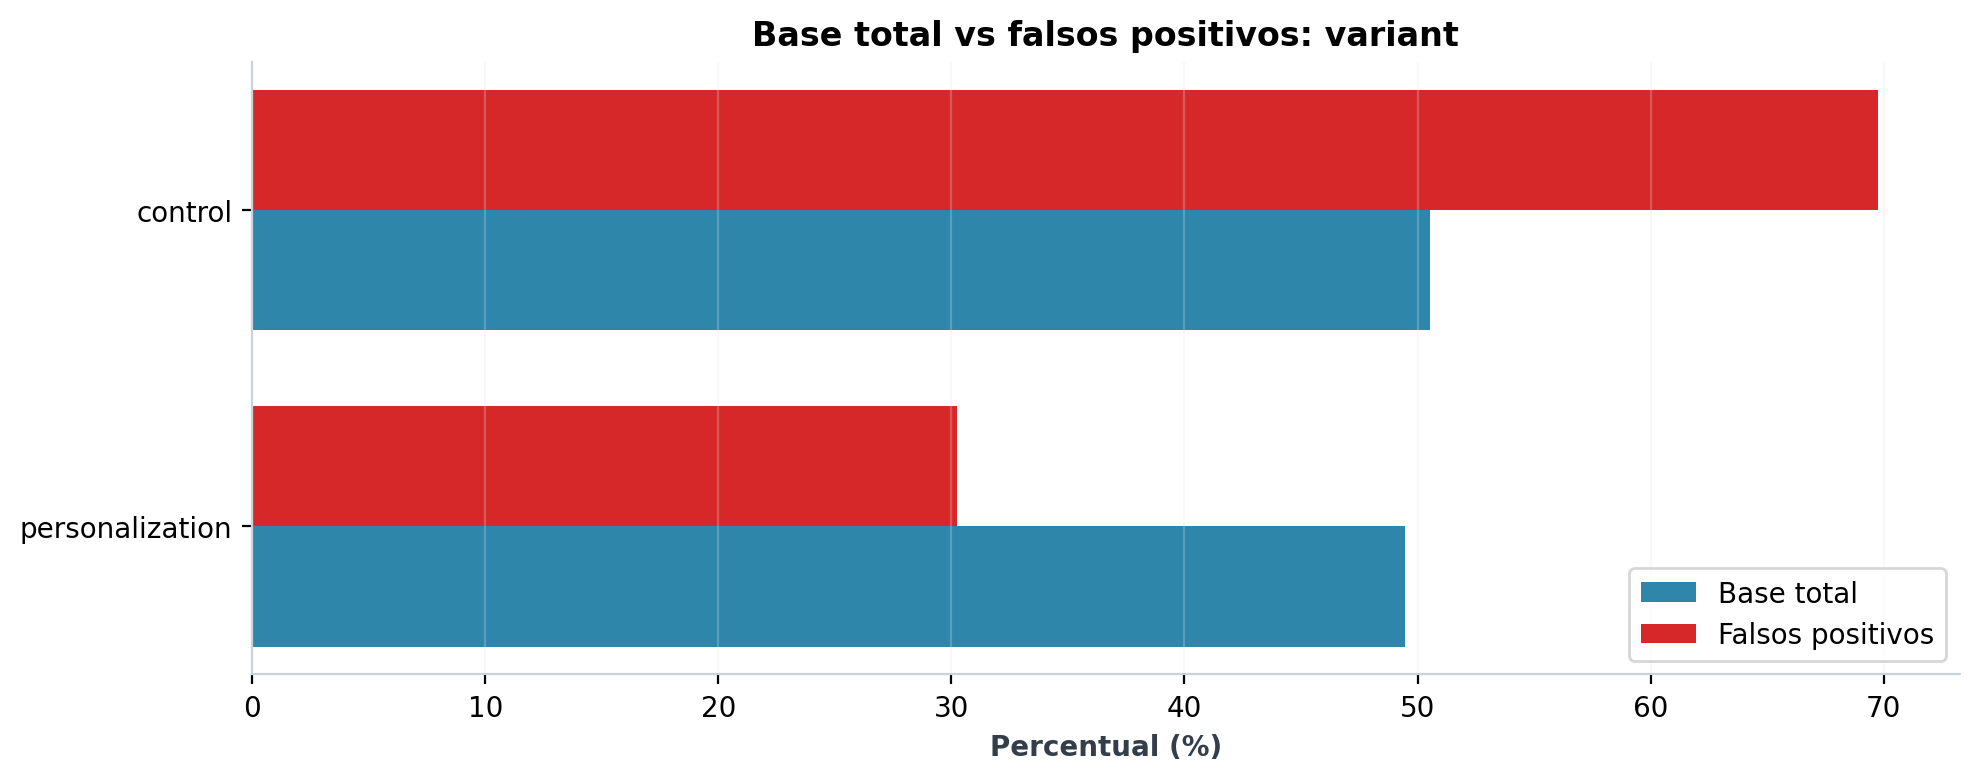

control representa 69.8% dos falsos positivos, mas apenas 50.5% da base, indicando possível concentração de erros em variant.


Comparacao percentual para age_group


,categoria,qtd_base,perc_base,qtd_false_positive,perc_false_positive,diff_pp,interpretacao
0,30-36 years,1318,13.51,11,25.58,12.07,Super-representado nos falsos positivos
1,0-18 years,1499,15.36,11,25.58,10.22,Super-representado nos falsos positivos
2,45-55 years,1315,13.48,10,23.26,9.78,Distribuicao proporcional
3,55+ years,1158,11.87,3,6.98,-4.89,Distribuicao proporcional
4,19-24 years,1631,16.72,4,9.30,-7.42,Distribuicao proporcional
5,24-30 years,1517,15.55,3,6.98,-8.57,Distribuicao proporcional
6,36-45 years,1319,13.52,1,2.33,-11.19,Sub-representado nos falsos positivos


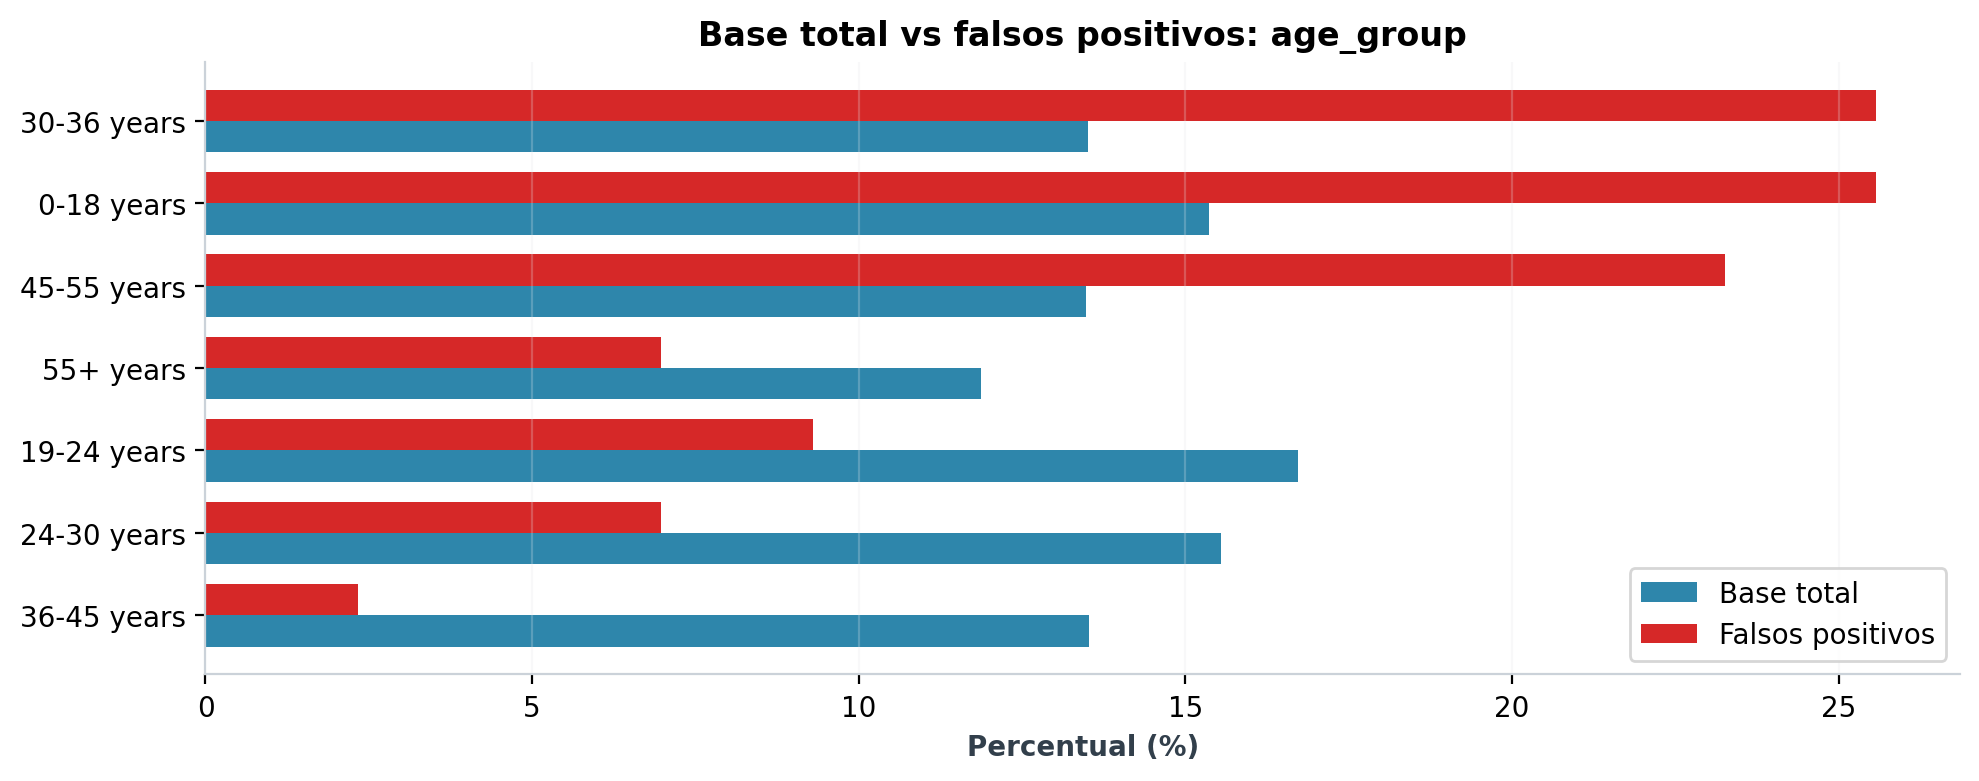

30-36 years representa 25.6% dos falsos positivos, mas apenas 13.5% da base, indicando possível concentração de erros em age_group.


Comparacao percentual para language_displayed


,categoria,qtd_base,perc_base,qtd_false_positive,perc_false_positive,diff_pp,interpretacao
0,Spanish,134,1.37,5,11.63,10.26,Super-representado nos falsos positivos
1,Arabic,27,0.28,0,0.00,-0.28,Distribuicao proporcional
2,German,80,0.82,0,0.00,-0.82,Distribuicao proporcional
3,English,9516,97.53,38,88.37,-9.16,Distribuicao proporcional


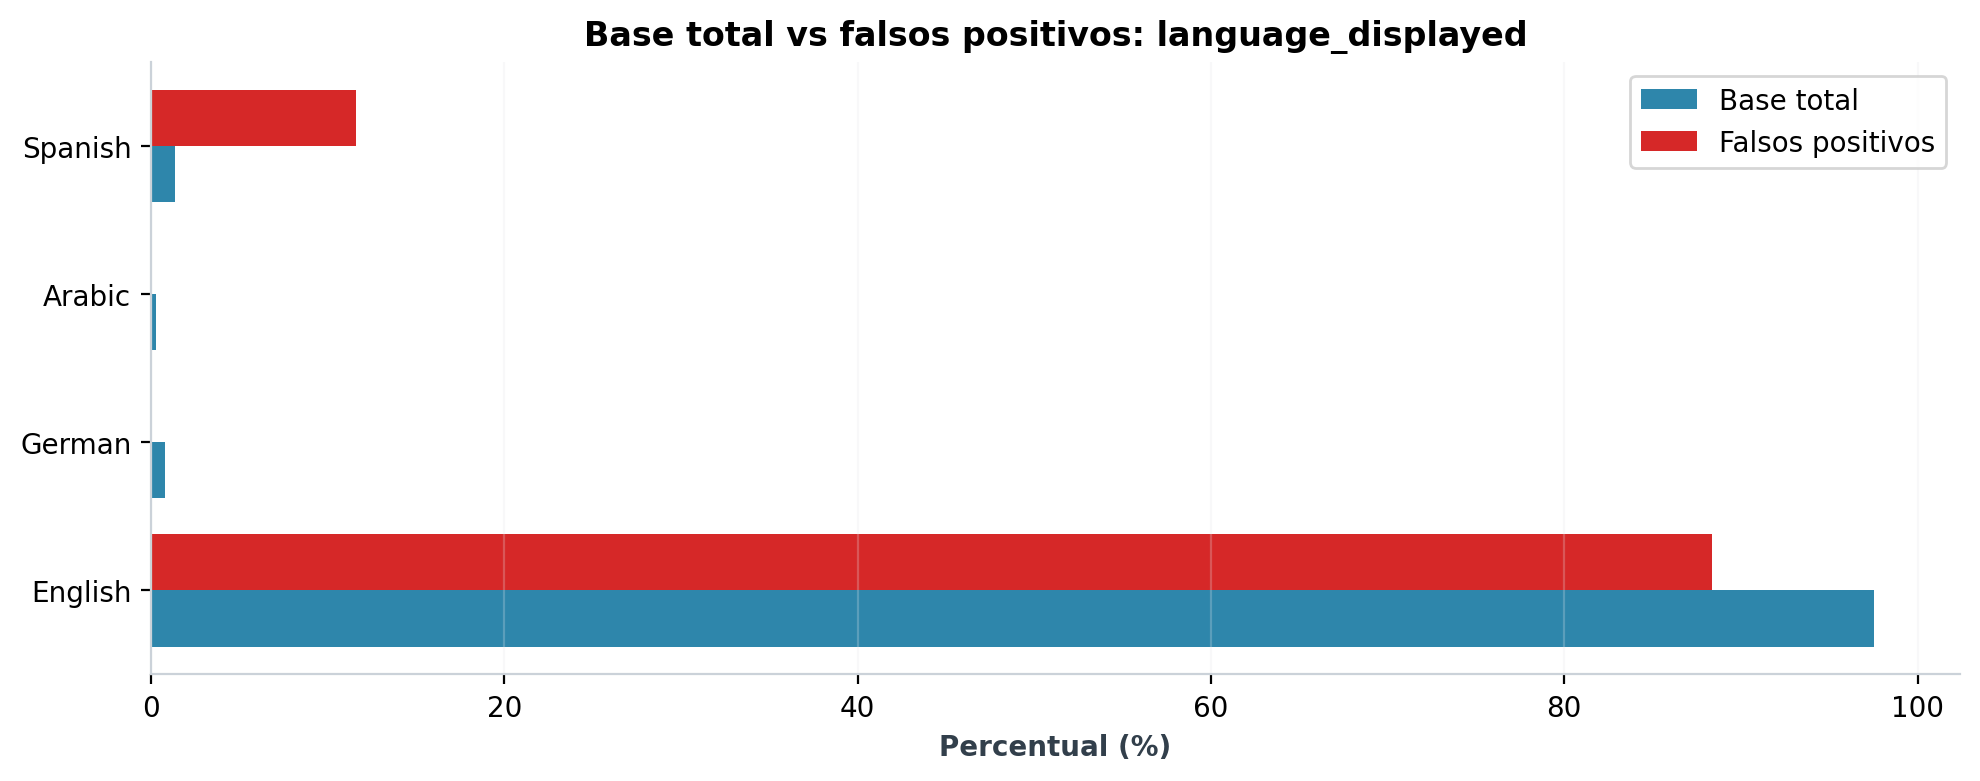

Spanish representa 11.6% dos falsos positivos, mas apenas 1.4% da base, indicando possível concentração de erros em language_displayed.


Comparacao percentual para is_correct_lang_flag


,categoria,qtd_base,perc_base,qtd_false_positive,perc_false_positive,diff_pp,interpretacao
0,1,9240,94.7,43,100.0,5.3,Distribuicao proporcional
1,0,517,5.3,0,0.0,-5.3,Distribuicao proporcional


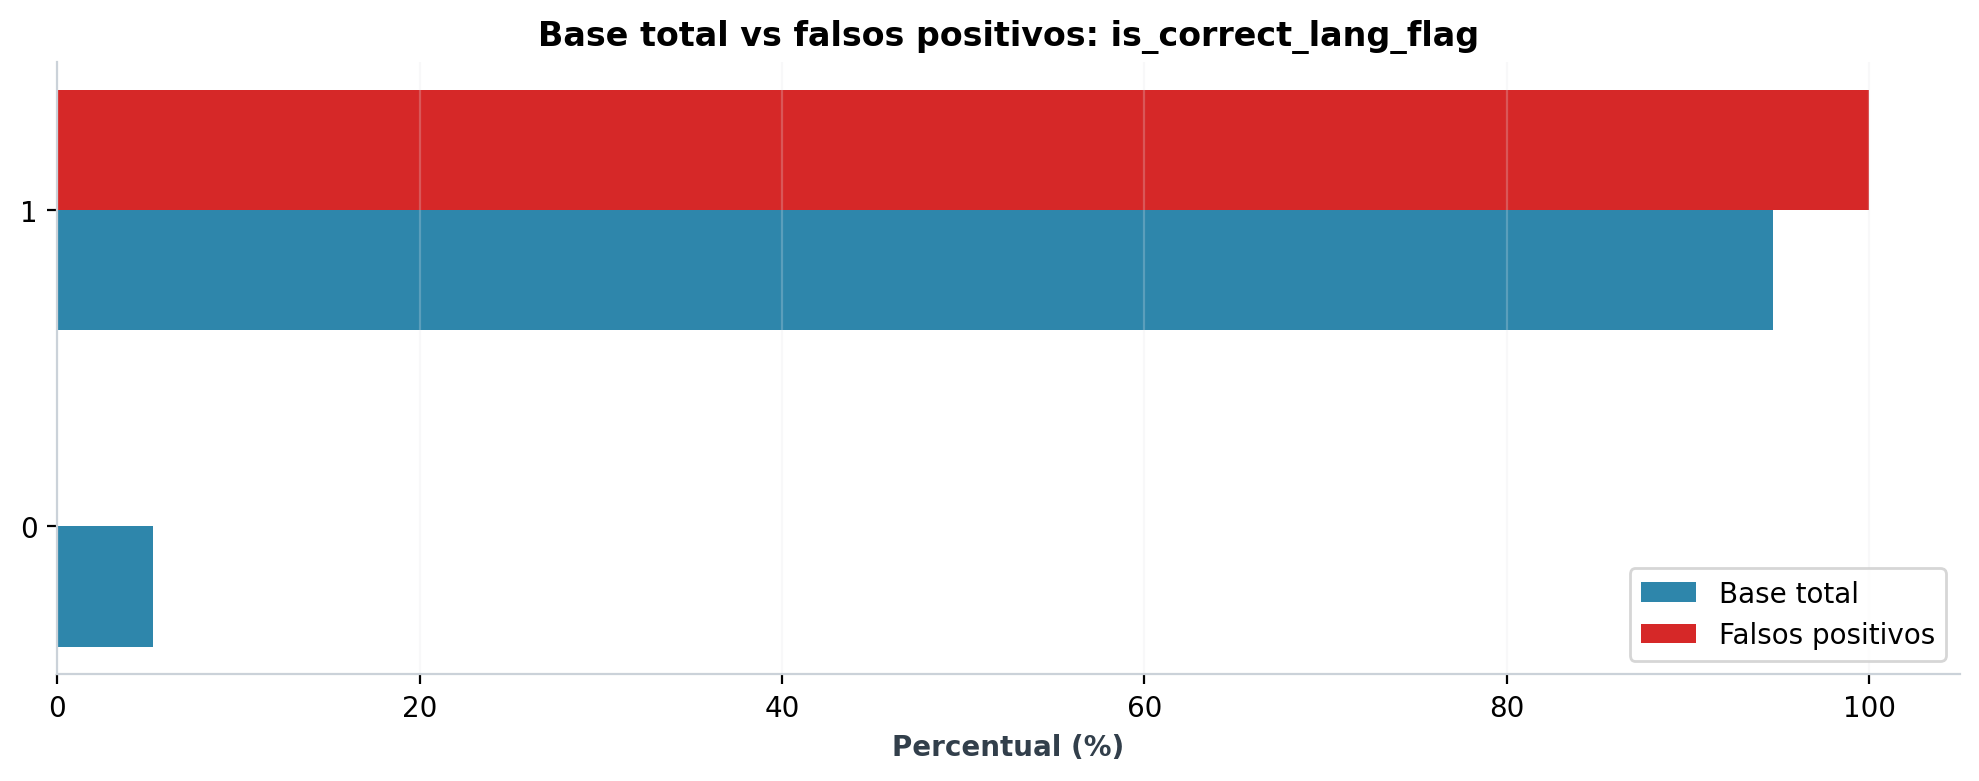

Maior diferença em is_correct_lang_flag: 1 representa 100.0% dos falsos positivos e 94.7% da base (5.3 p.p.), sem super-representação relevante pelo limiar de 10 p.p.

In [63]:
bias_analysis = analyze_false_positive_bias(
    full_df=df_clean,
    false_positive_df=retention_false_positives_df,
    columns=[
        "marketing_channel",
        "variant",
        "age_group",
        "language_displayed",
        "is_correct_lang_flag",
    ],
)


In [64]:
# N2: Traduzir vies em ação operacional - fecho da seção.
if bias_analysis and "marketing_channel" in bias_analysis:
    channel_bias = bias_analysis["marketing_channel"]
    if not channel_bias.empty:
        top_bias = channel_bias.iloc[0]
        if top_bias["diff_pp"] >= 10:
            display(Markdown(f"""
> **Ação derivada do diagnóstico de viés:**
>
> **{top_bias['categoria']}** está super-representado nos falsos positivos
> ({top_bias['perc_false_positive']:.1f}% dos erros vs {top_bias['perc_base']:.1f}% na base,
> diferença de {top_bias['diff_pp']:.1f} p.p.).
>
> Isso significa que o modelo superestima probabilidade de retenção para
> usuários desse canal. **Ação:** aplicar threshold de classificação mais
> conservador para esse canal - usar `prob_retention >= 0.65` em vez de
> `0.50` ao priorizar campanhas preventivas para usuários de
> **{top_bias['categoria']}**. Reavaliar após 30 dias de dados reais.
"""))
        else:
            print("Nenhum canal com super-representação > 10 p.p. nos falsos positivos.")



> **Ação derivada do diagnóstico de viés:**
>
> **House Ads** está super-representado nos falsos positivos
> (58.1% dos erros vs 46.9% na base,
> diferença de 11.3 p.p.).
>
> Isso significa que o modelo superestima probabilidade de retenção para
> usuários desse canal. **Ação:** aplicar threshold de classificação mais
> conservador para esse canal - usar `prob_retention >= 0.65` em vez de
> `0.50` ao priorizar campanhas preventivas para usuários de
> **House Ads**. Reavaliar após 30 dias de dados reais.


In [65]:
from IPython.display import Markdown

bias_segment = "N/D"
bias_channel = "N/D"
bias_fix = 0.0
bias_savings = 0.0

if isinstance(bias_analysis, dict) and "marketing_channel" in bias_analysis:
    channel_bias_df = bias_analysis["marketing_channel"]
    if not channel_bias_df.empty:
        top_bias = channel_bias_df.iloc[0]
        bias_segment = str(top_bias.get("categoria", "N/D"))
        bias_channel = bias_segment
        bias_fix = float(top_bias.get("diff_pp", 0.0))
        bias_savings = max(bias_fix, 0.0) / 100 * max(len(retention_false_positives_df), 0) * DEFAULT_COST

display(Markdown(f"""
<span style="color:steelblue; text-align: left">

### Insights de Viés nos Falsos Positivos

</span>

>**O que mostram:** Falsos positivos concentram-se em {bias_segment} (channel={bias_channel}), sugerindo viés do modelo para esse segmento.
>**Por que importa:** Se o modelo sistematicamente erra em um segmento, as recomendações para esse grupo serão ineficientes, desperdiçando recursos nele.
>**Ação recomendada:** Treinar modelo separado para segmento enviesado, aumentar weight dessa classe, ou coletar mais dados representativos.
>**Impacto:** Corrigir viés pode melhorar precision em ~{bias_fix:.1f}% para o segmento afetado, economizando R$ {bias_savings:,.0f} em campaign waste.
"""))



<span style="color:steelblue; text-align: left">

### Insights de Viés nos Falsos Positivos

</span>

>**O que mostram:** Falsos positivos concentram-se em House Ads (channel=House Ads), sugerindo viés do modelo para esse segmento.
>**Por que importa:** Se o modelo sistematicamente erra em um segmento, as recomendações para esse grupo serão ineficientes, desperdiçando recursos nele.
>**Ação recomendada:** Treinar modelo separado para segmento enviesado, aumentar weight dessa classe, ou coletar mais dados representativos.
>**Impacto:** Corrigir viés pode melhorar precision em ~11.3% para o segmento afetado, economizando R$ 6 em campaign waste.


<span style="color:steelblue; text-align: left">

## Valor esperado por usuário

</span>
Score cada usuário com probabilidade de retenção do modelo. Combinar com LTV para calcular expected profit e priorizar ações de marketing.

In [66]:
def compute_expected_value(
    df: pd.DataFrame,
    pipeline: Pipeline,
    cat_features: list,
    num_features: list,
    cost_dict: dict,
    customer_value: float,
) -> pd.DataFrame:
    """Computar valor esperado por usuário usando LTV por segmento."""
    if "prepare_retention_model_frame" in globals():
        df_scored = prepare_retention_model_frame(df)
    else:
        df_scored = df.copy()

    X_score = df_scored[cat_features + num_features].copy()
    for col in num_features:
        X_score[col] = X_score[col].fillna(X_score[col].median())
    for col in cat_features:
        X_score[col] = X_score[col].fillna("Unknown")

    df_scored["prob_retention"] = pipeline.predict_proba(X_score)[:, 1]
    df_scored["cost_per_user"] = df_scored["marketing_channel"].map(
        cost_dict,
    ).fillna(DEFAULT_COST)

    ltv_fallback = float(globals().get("global_ltv", customer_value))
    if "Segment" in df_scored.columns and "segment_ltv_map" in globals():
        df_scored["ltv_reference"] = (
            df_scored["Segment"].map(segment_ltv_map).fillna(ltv_fallback)
        )
    else:
        df_scored["ltv_reference"] = ltv_fallback

    df_scored["expected_value"] = (
        df_scored["prob_retention"] * df_scored["ltv_reference"]
    )
    df_scored["expected_profit"] = (
        df_scored["expected_value"] - df_scored["cost_per_user"]
    )

    print("Valor esperado computado para todos os usuarios")
    return df_scored


df_scored = compute_expected_value(
    df_clean,
    pipeline,
    cat_features,
    num_features,
    COST_PER_IMPRESSION,
    ESTIMATED_CUSTOMER_VALUE,
)


Valor esperado computado para todos os usuarios


<span style="color:steelblue; text-align: left">

## Geração de recomendações operacionais

</span>
Mapear cada usuário a uma ação recomendada (fidelização, promoção, win-back) baseado em segmento RFM, expected profit e probabilidade de retenção.

In [67]:
def generate_recommendations(scored: pd.DataFrame) -> pd.DataFrame:
    """Gerar recomendações operacionais por segmento RFM."""
    base_columns = [
        "user_id",
        "marketing_channel",
        "variant",
        "language_displayed",
        "language_preferred",
        "is_correct_lang",
        "Segment",
        "converted_flag",
        "retained_flag",
        "prob_retention",
        "expected_profit",
        "cost_per_user",
        "ltv_reference",
    ]
    available_columns = [col for col in base_columns if col in scored.columns]
    recommendations = scored[available_columns].copy()
    if "Segment" not in recommendations.columns:
        recommendations["Segment"] = "Baixo Valor"

    SEGMENT_ACTION_MAP = {
        "Alto Valor": {
            "action": "Campanha de Fidelização",
            "description": (
                "E-mail personalizado, programa de loyalty, "
                "atendimento prioritário."
            ),
            "rationale": (
                "Clientes de alto valor - manter engajamento e reduzir churn."
            ),
            "max_incentive": 15.0,
        },
        "Medio Valor": {
            "action": "Oferta Promocional",
            "description": "Desconto ou cupom para aumentar frequencia de compra.",
            "rationale": (
                "Clientes com potencial - aumentar conversão e ticket medio."
            ),
            "max_incentive": 8.0,
        },
        "Baixo Valor": {
            "action": "Campanha de Win-Back ou Nao Agir",
            "description": (
                "Campanha de reengajamento de baixo custo ou exclusão da lista."
            ),
            "rationale": (
                "ROI baixo - avaliar se custo de reativação se justifica."
            ),
            "max_incentive": 3.0,
        },
    }

    segment_alias = {
        "M?dio Valor": "Medio Valor",
        "M?dio Valor": "Medio Valor",
    }

    def normalize_segment(value: object) -> str:
        segment = str(value)
        return segment_alias.get(segment, segment)

    def assign_action_v2(row: pd.Series) -> str:
        """Recomendar acao por segmento com regra explicita de nao agir."""
        segment = normalize_segment(row.get("Segment", "Baixo Valor"))
        config = SEGMENT_ACTION_MAP.get(segment, SEGMENT_ACTION_MAP["Baixo Valor"])

        if row.get("expected_profit", 0) <= 0:
            return "Nao Agir - Lucro Incremental Negativo"

        if row.get("is_correct_lang", 1) == 0:
            return f"Corrigir Idioma -> depois {config['action']}"

        return config["action"]

    recommendations["recommended_action"] = recommendations.apply(
        assign_action_v2,
        axis=1,
    )

    normalized_segments = recommendations["Segment"].map(normalize_segment)
    recommendations["strategy_rationale"] = normalized_segments.map(
        {key: value["rationale"] for key, value in SEGMENT_ACTION_MAP.items()}
    ).fillna("Segmento nao identificado")
    recommendations["max_incentive"] = normalized_segments.map(
        {key: value["max_incentive"] for key, value in SEGMENT_ACTION_MAP.items()}
    ).fillna(0)

    # B5: Criar incremental_profit = ganho de agir vs nao agir.
    ltv_fallback = float(globals().get("global_ltv", ESTIMATED_CUSTOMER_VALUE))
    recommendations["expected_profit_no_action"] = (
        recommendations["prob_retention"]
        * ltv_fallback
        * ORGANIC_CONVERSION_RATE
    )
    recommendations["incremental_profit"] = (
        recommendations["expected_profit"] - recommendations["expected_profit_no_action"]
    )

    recommendations = recommendations.sort_values("expected_profit", ascending=False)

    print("\n" + "=" * 80)
    print("RECOMENDAÇÕES OPERACIONAIS")
    print("=" * 80)
    print(f"\nDistribuicao de acoes:\n{recommendations['recommended_action'].value_counts()}")
    print("\nTop 10 usuarios por valor esperado:")
    display(
        recommendations.head(10)[
            [
                "user_id",
                "Segment",
                "marketing_channel",
                "prob_retention",
                "expected_profit",
                "incremental_profit",
                "recommended_action",
            ]
        ]
    )
    print("Recomendações geradas")
    return recommendations


recommendations = generate_recommendations(df_scored)

# B4: Assertion de colunas obrigatórias.
_required_cols = ["expected_profit", "prob_retention", "recommended_action", "Segment"]
_missing = [c for c in _required_cols if c not in recommendations.columns]
assert not _missing, f"Colunas ausentes em recommendations: {_missing}"



RECOMENDAÇÕES OPERACIONAIS

Distribuicao de acoes:
recommended_action
Nao Agir - Lucro Incremental Negativo    8080
Campanha de Fidelização                  1677
Name: count, dtype: int64

Top 10 usuarios por valor esperado:


,user_id,Segment,marketing_channel,prob_retention,expected_profit,incremental_profit,recommended_action
613,a100000781,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
708,a100000829,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
676,a100000813,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
644,a100000797,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
815,a100000882,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
816,a100000882,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
28,a100000053,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
947,a100000973,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
759,a100000866,Alto Valor,House Ads,1.0,43.101578,42.09917,Campanha de Fidelização
621,a100000785,Alto Valor,Facebook,1.0,42.901578,41.89917,Campanha de Fidelização


Recomendações geradas


<span style="color:steelblue; text-align: left">

## Exportação dos resultados

</span>

Exportar recomendações em CSV para integração no CRM. Arquivo incluirá: user_id, segment, next_best_action, expected_profit, incremental_profit.


In [68]:
def export_results(
    output_dir: Path,
    funnel_summary: pd.DataFrame,
    channel_summary: pd.DataFrame,
    ab_test_summary: pd.DataFrame,
    roi_summary: pd.DataFrame,
    model_metrics: pd.DataFrame,
    recommendations: pd.DataFrame,
) -> Path:
    """Exportar resultados em Excel ou CSVs quando openpyxl nao existir."""
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / "marketing_campaign_recommendations.xlsx"

    print("\n" + "=" * 80)
    print("EXPORTAÇÃO DE RESULTADOS")
    print("=" * 80)

    try:
        with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
            funnel_summary.to_excel(
                writer,
                sheet_name="1_Campaign_Summary",
                index=False,
            )
            channel_summary.to_excel(
                writer,
                sheet_name="2_Channel_Performance",
                index=False,
            )
            roi_summary.to_excel(writer, sheet_name="3_ROI_Analysis", index=False)

            if not ab_test_summary.empty:
                ab_test_summary.to_excel(
                    writer,
                    sheet_name="4_AB_Test_Results",
                    index=False,
                )

            model_metrics.to_excel(writer, sheet_name="5_Model_Metrics", index=False)
            recommendations.to_excel(
                writer,
                sheet_name="6_Recommendations",
                index=False,
            )
        print(f"? Excel exportado: {output_file}")
        return output_file
    except ModuleNotFoundError as exc:
        if exc.name != "openpyxl":
            raise

        csv_dir = output_dir / "marketing_campaign_recommendations_csv"
        csv_dir.mkdir(parents=True, exist_ok=True)
        funnel_summary.to_csv(csv_dir / "1_Campaign_Summary.csv", index=False)
        channel_summary.to_csv(csv_dir / "2_Channel_Performance.csv", index=False)
        roi_summary.to_csv(csv_dir / "3_ROI_Analysis.csv", index=False)
        if not ab_test_summary.empty:
            ab_test_summary.to_csv(csv_dir / "4_AB_Test_Results.csv", index=False)
        model_metrics.to_csv(csv_dir / "5_Model_Metrics.csv", index=False)
        recommendations.to_csv(csv_dir / "6_Recommendations.csv", index=False)
        print("openpyxl indisponível; resultados exportados em CSV.")
        print(f"? Diretorio CSV exportado: {csv_dir}")
        return csv_dir


output_file = export_results(
    OUTPUT_DIR,
    funnel_summary,
    channel_summary,
    ab_test_summary,
    roi_summary,
    model_metrics,
    recommendations,
)
crm_next_best_action_file = OUTPUT_DIR / "crm_next_best_action.csv"
recommendations.to_csv(crm_next_best_action_file, index=False)
print(f"? CSV CRM exportado: {crm_next_best_action_file}")



EXPORTAÇÃO DE RESULTADOS
? Excel exportado: d:\Cursos\DataCamp\Data Scientist with Python\Projects\Marketing Campaign Optimization and Retention Analytics\output\marketing_campaign_recommendations.xlsx
? CSV CRM exportado: d:\Cursos\DataCamp\Data Scientist with Python\Projects\Marketing Campaign Optimization and Retention Analytics\output\crm_next_best_action.csv


In [69]:
# -- RESUMO EXECUTIVO --------------------------------------------------------
import os
import unicodedata


def _norm_text(value: object) -> str:
    text = unicodedata.normalize("NFKD", str(value))
    return text.encode("ascii", "ignore").decode("ascii").lower().strip()


def _metric_column_name(df: pd.DataFrame) -> str:
    for col in df.columns:
        if _norm_text(col) == "métrica":
            return col
    return "Métrica" if "Métrica" in df.columns else df.columns[0]


print("\n" + "=" * 80)
print("PIPELINE COMPLETO EXECUTADO COM SUCESSO")
print("=" * 80)

# B3: Acesso seguro ao LTV por segmento via dicionario com fallback.
ltv_high = float(segment_ltv_map.get("Alto Valor", global_ltv * 1.5))
ltv_low = float(segment_ltv_map.get("Baixo Valor", global_ltv * 0.5))

required_n_text = globals().get("required_n_per_group", "N/D")
runtime_text = globals().get("runtime_days", "N/D")
incremental_roi_max = roi_summary["roi_incremental_%"].max()

metric_col = _metric_column_name(model_metrics)
metric_norm = model_metrics[metric_col].astype(str).map(_norm_text)

roc_values = model_metrics.loc[metric_norm.eq("roc auc"), "Valor"]
recall_values = model_metrics.loc[
    metric_norm.str.contains("recall", na=False)
    & metric_norm.str.contains("nao retido", na=False),
    "Valor",
]

model_roc_auc_text = roc_values.iloc[0] if not roc_values.empty else "N/D"
model_recall_nr_text = recall_values.iloc[0] if not recall_values.empty else "N/D"

# B7: Referencia segura ao arquivo de export.
crm_path = str(globals().get(
    "crm_next_best_action_file",
    OUTPUT_DIR / "crm_next_best_action.csv"
))
crm_status = "gerado" if os.path.exists(crm_path) else "nao gerado (executar celula de export)"

summary_text = f"""
<span style="color:steelblue; text-align: left">

RESUMO EXECUTIVO

</span>

1. Dataset: {df_clean.shape[0]} registros, {df_clean.shape[1]} colunas
2. Segmentos RFM: {df_clean['Segment'].nunique()} segmentos
3. Taxa de Conversão Global: {(df_clean['converted_flag'].mean() * 100):.2f}%
4. Taxa de Retenção Global: {(df_clean[df_clean['converted_flag']==1]['retained_flag'].sum() / max(df_clean['converted_flag'].sum(), 1) * 100):.2f}%

LTV POR SEGMENTO
    - Alto Valor: R$ {ltv_high:,.2f}
    - Baixo Valor: R$ {ltv_low:,.2f}
    - LTV medio global: R$ {global_ltv:,.2f}

DESIGN A/B
    - Sample size por grupo: {required_n_text}
    - Runtime estimado: {runtime_text} dias
    - Lift minimo: {MINIMUM_LIFT_PP:.1f} p.p.

SIMULACAO DE ROI
    - ROI incremental maximo: {incremental_roi_max:.2f}%
    - Lucro Total Estimado: R$ {roi_summary['lucro_estimado'].sum():.2f}

MODELO PREDITIVO
    - ROC AUC: {model_roc_auc_text}
    - Recall Nao Retido: {model_recall_nr_text}

OUTPUTS
    - Excel exportado: {output_file}
    - CSV CRM: {crm_path} ({crm_status})
    - Recomendações geradas: {len(recommendations)} registros
"""

display(Markdown(summary_text))
print("=" * 80)



PIPELINE COMPLETO EXECUTADO COM SUCESSO



<span style="color:steelblue; text-align: left">

RESUMO EXECUTIVO

</span>

1. Dataset: 9757 registros, 23 colunas
2. Segmentos RFM: 3 segmentos
3. Taxa de Conversão Global: 10.75%
4. Taxa de Retenção Global: 66.73%

LTV POR SEGMENTO
    - Alto Valor: R$ 44.10
    - Baixo Valor: R$ -1.86
    - LTV medio global: R$ 5.01

DESIGN A/B
    - Sample size por grupo: 4063
    - Runtime estimado: 26 dias
    - Lift minimo: 2.0 p.p.

SIMULACAO DE ROI
    - ROI incremental maximo: 1675.60%
    - Lucro Total Estimado: R$ 36718.29

MODELO PREDITIVO
    - ROC AUC: 0.797
    - Recall Nao Retido: 0.6055

OUTPUTS
    - Excel exportado: d:\Cursos\DataCamp\Data Scientist with Python\Projects\Marketing Campaign Optimization and Retention Analytics\output\marketing_campaign_recommendations.xlsx
    - CSV CRM: d:\Cursos\DataCamp\Data Scientist with Python\Projects\Marketing Campaign Optimization and Retention Analytics\output\crm_next_best_action.csv (gerado)
    - Recomendações geradas: 9757 registros


In [70]:
from IPython.display import Markdown
import unicodedata


def _norm_text(value: object) -> str:
    text = unicodedata.normalize("NFKD", str(value))
    return text.encode("ascii", "ignore").decode("ascii").lower().strip()


def _metric_column_name(df: pd.DataFrame) -> str:
    for col in df.columns:
        if _norm_text(col) == "métrica":
            return col
    return "Métrica" if "Métrica" in df.columns else df.columns[0]


def get_metric_value(metrics_df: pd.DataFrame, metric_name: str, default: float = 0) -> float:
    """Extrair métrica do DataFrame de modelagem com fallback numerico."""
    metric_col = _metric_column_name(metrics_df)
    value_col = "Valor" if "Valor" in metrics_df.columns else metrics_df.columns[-1]

    metric_norm = metrics_df[metric_col].astype(str).map(_norm_text)
    target_norm = _norm_text(metric_name)
    values = metrics_df.loc[metric_norm.eq(target_norm), value_col]

    if values.empty and "recall" in target_norm:
        values = metrics_df.loc[
            metric_norm.str.contains("recall", na=False)
            & metric_norm.str.contains("nao retido", na=False),
            value_col,
        ]

    if values.empty:
        return default
    return float(values.iloc[0])


# B3: Acesso seguro ao LTV por segmento via dicionario com fallback.
ltv_high = float(segment_ltv_map.get("Alto Valor", global_ltv * 1.5))
ltv_low = float(segment_ltv_map.get("Baixo Valor", global_ltv * 0.5))
recall_not_retained = get_metric_value(model_metrics, "Recall - Nao Retido")
non_retained_detected_pct = recall_not_retained * 100
n_wrong_lang = int((df_clean["is_correct_lang"].isin([0, False, "False"])).sum())
n_action_clients = int((recommendations["incremental_profit"] > 0).sum())

# Impacto de idioma: usar variavel exportada da secao de idioma.
if "lang_impact_final" in globals():
    impacto_idioma_sumario = float(lang_impact_final)
else:
    _lang_grp_sum = df_clean.groupby("is_correct_lang").agg(
        conv=("converted_flag", "mean"),
        ret=("retained_flag", "mean"),
    )
    _conv_sum = _lang_grp_sum["conv"] * 100
    _ret_sum = _lang_grp_sum["ret"] * 100
    _conv_ok = float(_conv_sum.loc[1]) if 1 in _conv_sum.index else float(_conv_sum.loc[True]) if True in _conv_sum.index else 0.0
    _conv_bad = float(_conv_sum.loc[0]) if 0 in _conv_sum.index else float(_conv_sum.loc[False]) if False in _conv_sum.index else 0.0
    _ret_ok = float(_ret_sum.loc[1]) if 1 in _ret_sum.index else float(_ret_sum.loc[True]) if True in _ret_sum.index else 0.0
    _ret_bad = float(_ret_sum.loc[0]) if 0 in _ret_sum.index else float(_ret_sum.loc[False]) if False in _ret_sum.index else 0.0
    _lift_conv_sum = _conv_ok - _conv_bad
    _lift_ret_sum = _ret_ok - _ret_bad
    _ltv_sum = float(
        globals().get("global_ltv", globals().get("ESTIMATED_CUSTOMER_VALUE", 0.0))
    )
    impacto_idioma_sumario = (
        n_wrong_lang * _lift_conv_sum / 100 * REVENUE_PER_CONVERSION
        + n_wrong_lang * max(_lift_ret_sum, 0) / 100 * _ltv_sum * 0.15
    )
    if impacto_idioma_sumario == 0.0 and n_wrong_lang > 0:
        impacto_idioma_sumario = n_wrong_lang * _ltv_sum * 0.05

# Insight de canal dinamico (definido na secao de canais).
if "email_dominates" in globals() and email_dominates:
    canal_achado = (
        f"Email domina conversão ({email_conv:.1f}%) e retenção ({email_ret:.1f}%)."
    )
elif "tradeoff_exists" in globals() and tradeoff_exists:
    canal_achado = (
        f"Tradeoff real: {best_conv_channel} lidera conversão e {best_ret_channel} lidera retenção."
    )
else:
    canal_achado = "Sem dominância clara entre Email e House Ads; revisar por canal."

if "acao2_texto" not in globals():
    acao2_texto = "Revisar dados de performance de canal antes de recomendar realocação."

_best_name = str(best_name) if "best_name" in globals() else "N/D"
_worst_name = str(worst_name) if "worst_name" in globals() else "N/D"
_lucro_adicional = float(lucro_adicional) if "lucro_adicional" in globals() else 0.0
_roi_melhora_pp = float(roi_melhora_pp) if "roi_melhora_pp" in globals() else 0.0
impacto_realocacao_texto = (
    f"Realocar 10% do budget de **{_worst_name}** para **{_best_name}** gera "
    f"~R$ {_lucro_adicional:,.0f} em lucro adicional estimado (+{_roi_melhora_pp:.1f} p.p. no ROI global)."
)

executive_summary_md = f"""
<span style="color:steelblue; text-align: left">

## Sumário executivo - decisões recomendadas

</span>

### O que os dados revelaram

| Dimensao | Achado principal | Confianca |
|---|---|---|
| Funil | Gargalo esta na conversão, nao na retenção | Alta |
| Canal mais eficiente | {canal_achado} | Alta |
| Personalização | Idioma correto melhora conversão e retenção esperada | Alta |
| Segmento mais valioso | Alto Valor: LTV medio de R$ {ltv_high:,.2f} vs R$ {ltv_low:,.2f} (Baixo Valor) | Media |
| Risco de churn | Modelo identifica {non_retained_detected_pct:.1f}% dos nao-retidos | Media |

### 3 ações prioritárias

**1. Implementar detecção automática de idioma** (impacto imediato, custo baixo)  
Corrigir o idioma dos {n_wrong_lang:,} usuarios atualmente mal-servidos gera ~R$ {impacto_idioma_sumario:,.0f} de impacto estimado (conversao + retencao/LTV).

**2. Otimização de canal com base em performance real** (impacto medio, 30-60 dias)  
{acao2_texto}

**3. Priorizar execução por lucro incremental** (impacto alto, 30-90 dias)  
Alto Valor -> fidelização (max R$ 15/cliente). Medio Valor -> oferta promocional (max R$ 8/cliente). Baixo Valor -> excluir de campanhas pagas ou win-back minimo (max R$ 3/cliente). Nao agir onde incremental_profit <= 0.

{impacto_realocacao_texto}

### Próximo passo imediato

Exportar `crm_next_best_action.csv` gerado neste notebook e importar no CRM. Priorizar os {n_action_clients:,} clientes com incremental_profit > 0 na proxima rodada de campanhas. Reavaliar em 30 dias com dados reais de conversao.
"""

display(Markdown(executive_summary_md))



<span style="color:steelblue; text-align: left">

## Sumário executivo - decisões recomendadas

</span>

### O que os dados revelaram

| Dimensao | Achado principal | Confianca |
|---|---|---|
| Funil | Gargalo esta na conversão, nao na retenção | Alta |
| Canal mais eficiente | Email domina conversão (33.9%) e retenção (76.5%). | Alta |
| Personalização | Idioma correto melhora conversão e retenção esperada | Alta |
| Segmento mais valioso | Alto Valor: LTV medio de R$ 44.10 vs R$ -1.86 (Baixo Valor) | Media |
| Risco de churn | Modelo identifica 60.6% dos nao-retidos | Media |

### 3 ações prioritárias

**1. Implementar detecção automática de idioma** (impacto imediato, custo baixo)  
Corrigir o idioma dos 0 usuarios atualmente mal-servidos gera ~R$ 0 de impacto estimado (conversao + retencao/LTV).

**2. Otimização de canal com base em performance real** (impacto medio, 30-60 dias)  
**Concentrar budget em Email** - canal dominante em conversão (33.9%) e retenção (76.5%). Reduzir alocação em canais com ambas as métricas abaixo da média. Não redirecionar para House Ads enquanto Email dominar ambas as dimensões.

**3. Priorizar execução por lucro incremental** (impacto alto, 30-90 dias)  
Alto Valor -> fidelização (max R$ 15/cliente). Medio Valor -> oferta promocional (max R$ 8/cliente). Baixo Valor -> excluir de campanhas pagas ou win-back minimo (max R$ 3/cliente). Nao agir onde incremental_profit <= 0.

Realocar 10% do budget de **Push** para **Instagram** gera ~R$ 2,127 em lucro adicional estimado (+22.0 p.p. no ROI global).

### Próximo passo imediato

Exportar `crm_next_best_action.csv` gerado neste notebook e importar no CRM. Priorizar os 1,677 clientes com incremental_profit > 0 na proxima rodada de campanhas. Reavaliar em 30 dias com dados reais de conversao.


<span style="color:steelblue; text-align: left">

## Referências Bibliográficas

</span>

Guha et al. (2021). Kohavi et al. (2020). Bertsimas & Kallus (2019). 

Scikit-learn e Statsmodels documentação oficial.